In [ ]:
# @title
import kagglehub
path = kagglehub.dataset_download("programmerrdai/ampds-the-almanac-of-minutely-power-dataset")

Using Colab cache for faster access to the 'ampds-the-almanac-of-minutely-power-dataset' dataset.


In [ ]:
# @title
# --- CELL 1: CONFIGURATION ---
%%writefile config.py
DEVICE_CONFIG = {
    'FGE': {'name': 'Fridge', 'zone': 'Kitchen', 'type': 'Inductive'},
    'DWE': {'name': 'Dishwasher', 'zone': 'Kitchen', 'type': 'Resistive/Motor'},
    'WOE': {'name': 'Wall Oven', 'zone': 'Kitchen', 'type': 'Resistive'},
    'HTE': {'name': 'Instant Hot Water', 'zone': 'Kitchen', 'type': 'Resistive'},
    'OUE': {'name': 'Kitchen Plugs', 'zone': 'Kitchen', 'type': 'Mixed'},
    'CWE': {'name': 'Clothes Washer', 'zone': 'Utility', 'type': 'Motor'},
    'CDE': {'name': 'Clothes Dryer', 'zone': 'Utility', 'type': 'Resistive'},
    'HPE': {'name': 'Heat Pump', 'zone': 'Utility', 'type': 'Inductive'},
    'FRE': {'name': 'Furnace Fan', 'zone': 'Utility', 'type': 'Motor'},
    'UTE': {'name': 'Utility Plugs', 'zone': 'Utility', 'type': 'Mixed'},
    'TVE': {'name': 'TV & Entertainment', 'zone': 'Living Room', 'type': 'Electronic'},
    'DNE': {'name': 'Dining Room Plugs', 'zone': 'Dining Room', 'type': 'Resistive'},
    'OFE': {'name': 'Home Office', 'zone': 'Office', 'type': 'Electronic'},
    'EBE': {'name': 'Electronics Workbench', 'zone': 'Office', 'type': 'Electronic'},
    'EQE': {'name': 'Network/Security', 'zone': 'Office', 'type': 'Electronic'},
    'BME': {'name': 'Master Bedroom', 'zone': 'Bedroom_Master', 'type': 'Mixed'},
    'B1E': {'name': 'North Bedroom', 'zone': 'Bedroom_North', 'type': 'Mixed'},
    'B2E': {'name': 'South Bedroom', 'zone': 'Bedroom_South', 'type': 'Mixed'},
    'GRE': {'name': 'Garage', 'zone': 'Garage', 'type': 'Motor'},
    'RSE': {'name': 'Rental Suite', 'zone': 'Rental', 'type': 'Mixed'},
    'WHE': {'name': 'Whole House', 'zone': 'Grid', 'type': 'Source'}
}

Writing config.py


In [ ]:
# @title
# --- CELL 2: PROCESSOR WITH INDIAN STANDARDS ---
%%writefile processor.py
import pandas as pd
import numpy as np

class AMPdsProcessor:
    def __init__(self):
        # --- INDIAN STANDARDS CALIBRATION ---
        self.TARGET_VOLTAGE = 230.0  # Volts (India)
        self.MAX_P = 7000.0          # Watts (Typical 7kW Sanctioned Load)
        self.MAX_I = 30.0            # Amps (Main Line limit)
        self.MAX_V_DEV = 25.0        # Volts (Fluctuation tolerance +/- 25V)

    def process_single_device(self, filepath, device_code):
        needed_cols = ['unix_ts', 'V', 'I', 'P', 'Q', 'S', 'DPF']
        try:
            df = pd.read_csv(filepath, usecols=lambda c: c in needed_cols)
        except:
            return None

        if df.empty or 'P' not in df.columns: return None

        rename_map = {'V': 'v', 'I': 'i', 'P': 'p', 'Q': 'q', 'S': 's', 'DPF': 'pf'}
        df.rename(columns=rename_map, inplace=True)

        # --- TRANSFORM TO INDIAN STANDARDS ---
        # The raw data is likely 120V (Canada). We must scale it to 230V.
        current_mean_v = df['v'].mean()

        # If the data is roughly 110-130V, we scale it up.
        if 100 < current_mean_v < 140:
            scale_factor = self.TARGET_VOLTAGE / current_mean_v
            df['v'] = df['v'] * scale_factor
            # Note: We leave Power/Current as is, assuming the appliance wattage
            # is similar (e.g., a 1000W iron in Canada vs 1000W iron in India).

        # Feature Engineering
        df['dp'] = df['p'].diff().fillna(0)

        is_on = df['p'] > 10
        df['session_id'] = (is_on != is_on.shift()).cumsum()
        df['dur'] = df.groupby('session_id').cumcount() + 1
        df.loc[~is_on, 'dur'] = 0
        df['dur'] = np.log1p(df['dur'])

        # Time Context
        t = pd.to_datetime(df['unix_ts'], unit='s')
        seconds_day = 24 * 60 * 60
        sec_past = t.dt.hour * 3600 + t.dt.minute * 60 + t.dt.second

        df['sin_t'] = np.sin(2 * np.pi * sec_past / seconds_day)
        df['cos_t'] = np.cos(2 * np.pi * sec_past / seconds_day)

        df['sin_start'] = df.groupby('session_id')['sin_t'].transform('first')
        df.loc[~is_on, 'sin_start'] = 0

        # --- NORMALIZATION (Using Indian Baselines) ---
        # Normalize voltage deviation from 230V
        df['v'] = (df['v'] - self.TARGET_VOLTAGE) / self.MAX_V_DEV

        df['i'] = df['i'] / self.MAX_I
        df['p'] = df['p'] / self.MAX_P
        df['q'] = df['q'] / self.MAX_P
        df['s'] = df['s'] / self.MAX_P
        df['dp'] = df['dp'] / self.MAX_P

        df['timestamp'] = df['unix_ts']
        df.set_index('timestamp', inplace=True)

        cols_to_keep = ['v', 'i', 'p', 'q', 's', 'pf', 'dp', 'dur', 'sin_start', 'sin_t', 'cos_t']
        df = df[cols_to_keep]
        # Append Device Code to columns (e.g., 'v_FGE')
        df.columns = [f"{col}_{device_code}" for col in df.columns]

        return df

Writing processor.py


In [ ]:
# @title
# --- CELL 3: RUN THE MASTER SCRIPT ---
import kagglehub
import os
import glob
import pandas as pd

# Import the updated classes we just wrote
from config import DEVICE_CONFIG
from processor import AMPdsProcessor

def main():
    print("--- Step 1: Downloading AMPds Data ---")
    path = kagglehub.dataset_download("programmerrdai/ampds-the-almanac-of-minutely-power-dataset")

    search_pattern = os.path.join(path, "**", "Electricity_*.csv")
    csv_files = glob.glob(search_pattern, recursive=True)

    # Initialize Processor (Now defaults to Indian 230V)
    processor = AMPdsProcessor()
    data_frames = []

    print(f"\n--- Step 2: Processing {len(DEVICE_CONFIG)} Devices (Converting to 230V) ---")

    found_devices = []

    for file_path in csv_files:
        filename = os.path.basename(file_path)
        code = filename.replace("Electricity_", "").replace(".csv", "")

        if code in DEVICE_CONFIG:
            print(f"Processing {code} ({DEVICE_CONFIG[code]['name']})...", end=" ")
            df_device = processor.process_single_device(file_path, code)

            if df_device is not None:
                data_frames.append(df_device)
                found_devices.append(code)
                print("✅ Done.")

    print("\n--- Step 3: Merging into Single Master File ---")
    if not data_frames:
        print("No data found!")
        return

    master_df = pd.concat(data_frames, axis=1, join='outer')
    master_df.sort_index(inplace=True)
    master_df.fillna(method='ffill', inplace=True)
    master_df.fillna(0, inplace=True)

    output_filename = "master_house_data.csv"
    master_df.to_csv(output_filename)
    print(f"\n✅ Success! Saved {output_filename}")
    print(f"Shape: {master_df.shape}")
    print("Note: Voltage columns (v_*) are now scaled to ~230V Indian Standard.")

if __name__ == "__main__":
    main()

--- Step 1: Downloading AMPds Data ---
Using Colab cache for faster access to the 'ampds-the-almanac-of-minutely-power-dataset' dataset.

--- Step 2: Processing 21 Devices (Converting to 230V) ---
Processing WOE (Wall Oven)... ✅ Done.
Processing EBE (Electronics Workbench)... ✅ Done.
Processing WHE (Whole House)... ✅ Done.
Processing B2E (South Bedroom)... ✅ Done.
Processing EQE (Network/Security)... ✅ Done.
Processing HTE (Instant Hot Water)... ✅ Done.
Processing CDE (Clothes Dryer)... ✅ Done.
Processing DWE (Dishwasher)... ✅ Done.
Processing RSE (Rental Suite)... ✅ Done.
Processing GRE (Garage)... ✅ Done.
Processing OUE (Kitchen Plugs)... ✅ Done.
Processing OFE (Home Office)... ✅ Done.
Processing DNE (Dining Room Plugs)... ✅ Done.
Processing UTE (Utility Plugs)... ✅ Done.
Processing BME (Master Bedroom)... ✅ Done.
Processing FRE (Furnace Fan)... ✅ Done.
Processing TVE (TV & Entertainment)... ✅ Done.
Processing FGE (Fridge)... ✅ Done.
Processing HPE (Heat Pump)... ✅ Done.
Processing B

/tmp/ipython-input-4274061034.py:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_df.fillna(method='ffill', inplace=True)



✅ Success! Saved master_house_data.csv
Shape: (1051200, 231)
Note: Voltage columns (v_*) are now scaled to ~230V Indian Standard.


In [ ]:
# @title
# Quick Check
import pandas as pd
df = pd.read_csv("master_house_data.csv")
# Reverse normalization to see raw volts: (Norm * 25) + 230
raw_volts = (df['v_FGE'].mean() * 25.0) + 230.0
print(f"Average Voltage in Dataset: {raw_volts:.2f} V")

Average Voltage in Dataset: 230.00 V


### Dataset Download from KaggleHub

**Process:** This cell uses the `kagglehub` library to download the specified dataset from Kaggle. The `dataset_download` function handles the retrieval and local storage of the dataset.

**Expected Output Example:**
```
Warning: Looks like you're using an outdated `kagglehub` version (installed: 0.3.13), please consider upgrading to the latest version (0.4.1).
Downloading from https://www.kaggle.com/api/v1/datasets/download/programmerrdai/ampds-the-almanac-of-minutely-power-dataset?dataset_version_number=1...
Extracting files...
100%|██████████| 525M/525M [00:03<00:00, 150MB/s]
```

In [ ]:
import kagglehub
path = kagglehub.dataset_download("programmerrdai/ampds-the-almanac-of-minutely-power-dataset")

100%|██████████| 525M/525M [00:05<00:00, 109MB/s]

Extracting files...


### Device Configuration Definition

**Process:** This cell defines a dictionary `DEVICE_CONFIG` containing metadata for various household devices, such as their names, zones, and types. This configuration is then written to a Python file named `config.py`, making it importable by other scripts.

**Expected Output Example:**
```
Writing config.py
```

In [ ]:
# --- CELL 1: CONFIGURATION ---
%%writefile config.py
DEVICE_CONFIG = {
    'FGE': {'name': 'Fridge', 'zone': 'Kitchen', 'type': 'Inductive'},
    'DWE': {'name': 'Dishwasher', 'zone': 'Kitchen', 'type': 'Resistive/Motor'},
    'WOE': {'name': 'Wall Oven', 'zone': 'Kitchen', 'type': 'Resistive'},
    'HTE': {'name': 'Instant Hot Water', 'zone': 'Kitchen', 'type': 'Resistive'},
    'OUE': {'name': 'Kitchen Plugs', 'zone': 'Kitchen', 'type': 'Mixed'},
    'CWE': {'name': 'Clothes Washer', 'zone': 'Utility', 'type': 'Motor'},
    'CDE': {'name': 'Clothes Dryer', 'zone': 'Utility', 'type': 'Resistive'},
    'HPE': {'name': 'Heat Pump', 'zone': 'Utility', 'type': 'Inductive'},
    'FRE': {'name': 'Furnace Fan', 'zone': 'Utility', 'type': 'Motor'},
    'UTE': {'name': 'Utility Plugs', 'zone': 'Utility', 'type': 'Mixed'},
    'TVE': {'name': 'TV & Entertainment', 'zone': 'Living Room', 'type': 'Electronic'},
    'DNE': {'name': 'Dining Room Plugs', 'zone': 'Dining Room', 'type': 'Resistive'},
    'OFE': {'name': 'Home Office', 'zone': 'Office', 'type': 'Electronic'},
    'EBE': {'name': 'Electronics Workbench', 'zone': 'Office', 'type': 'Electronic'},
    'EQE': {'name': 'Network/Security', 'zone': 'Office', 'type': 'Electronic'},
    'BME': {'name': 'Master Bedroom', 'zone': 'Bedroom_Master', 'type': 'Mixed'},
    'B1E': {'name': 'North Bedroom', 'zone': 'Bedroom_North', 'type': 'Mixed'},
    'B2E': {'name': 'South Bedroom', 'zone': 'Bedroom_South', 'type': 'Mixed'},
    'GRE': {'name': 'Garage', 'zone': 'Garage', 'type': 'Motor'},
    'RSE': {'name': 'Rental Suite', 'zone': 'Rental', 'type': 'Mixed'},
    'WHE': {'name': 'Whole House', 'zone': 'Grid', 'type': 'Source'}
}

Writing config.py


### Data Processor for Indian Standards

**Process:** This cell defines the `AMPdsProcessor` class. This class is responsible for loading raw device data, scaling voltage and other metrics to Indian 230V standards, engineering new features (like `dp` for power change and `dur` for session duration), and normalizing the data. The processed data is then saved with device-specific column names. This class is written to `processor.py` for later use.

**Expected Output Example:**
```
Writing processor.py
```

In [ ]:
# --- CELL 2: PROCESSOR WITH INDIAN STANDARDS ---
%%writefile processor.py
import pandas as pd
import numpy as np

class AMPdsProcessor:
    def __init__(self):
        # --- INDIAN STANDARDS CALIBRATION ---
        self.TARGET_VOLTAGE = 230.0  # Volts (India)
        self.MAX_P = 7000.0          # Watts (Typical 7kW Sanctioned Load)
        self.MAX_I = 30.0            # Amps (Main Line limit)
        self.MAX_V_DEV = 25.0        # Volts (Fluctuation tolerance +/- 25V)

    def process_single_device(self, filepath, device_code):
        needed_cols = ['unix_ts', 'V', 'I', 'P', 'Q', 'S', 'DPF']
        try:
            df = pd.read_csv(filepath, usecols=lambda c: c in needed_cols)
        except:
            return None

        if df.empty or 'P' not in df.columns: return None

        rename_map = {'V': 'v', 'I': 'i', 'P': 'p', 'Q': 'q', 'S': 's', 'DPF': 'pf'}
        df.rename(columns=rename_map, inplace=True)

        # --- TRANSFORM TO INDIAN STANDARDS ---
        # The raw data is likely 120V (Canada). We must scale it to 230V.
        current_mean_v = df['v'].mean()

        # If the data is roughly 110-130V, we scale it up.
        if 100 < current_mean_v < 140:
            scale_factor = self.TARGET_VOLTAGE / current_mean_v
            df['v'] = df['v'] * scale_factor
            # Note: We leave Power/Current as is, assuming the appliance wattage
            # is similar (e.g., a 1000W iron in Canada vs 1000W iron in India).

        # Feature Engineering
        df['dp'] = df['p'].diff().fillna(0)

        is_on = df['p'] > 10
        df['session_id'] = (is_on != is_on.shift()).cumsum()
        df['dur'] = df.groupby('session_id').cumcount() + 1
        df.loc[~is_on, 'dur'] = 0
        df['dur'] = np.log1p(df['dur'])

        # Time Context
        t = pd.to_datetime(df['unix_ts'], unit='s')
        seconds_day = 24 * 60 * 60
        sec_past = t.dt.hour * 3600 + t.dt.minute * 60 + t.dt.second

        df['sin_t'] = np.sin(2 * np.pi * sec_past / seconds_day)
        df['cos_t'] = np.cos(2 * np.pi * sec_past / seconds_day)

        df['sin_start'] = df.groupby('session_id')['sin_t'].transform('first')
        df.loc[~is_on, 'sin_start'] = 0

        # --- NORMALIZATION (Using Indian Baselines) ---
        # Normalize voltage deviation from 230V
        df['v'] = (df['v'] - self.TARGET_VOLTAGE) / self.MAX_V_DEV

        df['i'] = df['i'] / self.MAX_I
        df['p'] = df['p'] / self.MAX_P
        df['q'] = df['q'] / self.MAX_P
        df['s'] = df['s'] / self.MAX_P
        df['dp'] = df['dp'] / self.MAX_P

        df['timestamp'] = df['unix_ts']
        df.set_index('timestamp', inplace=True)

        cols_to_keep = ['v', 'i', 'p', 'q', 's', 'pf', 'dp', 'dur', 'sin_start', 'sin_t', 'cos_t']
        df = df[cols_to_keep]
        # Append Device Code to columns (e.g., 'v_FGE')
        df.columns = [f"{col}_{device_code}" for col in df.columns]

        return df

Writing processor.py


### Master Script Execution: Data Processing and Merging

**Process:** This cell serves as the main execution script. It first downloads the AMPds dataset, then iterates through a predefined list of devices (from `config.py`), processing each device's raw electricity data using the `AMPdsProcessor` (from `processor.py`). Each device's processed DataFrame is then concatenated into a single master DataFrame, which is sorted by timestamp, forward-filled for missing values, and saved as `master_house_data.csv`. This consolidates all device data into a single, standardized file.

**Expected Output Example:**
```
--- Step 1: Downloading AMPds Data ---
---
--- Step 2: Processing 21 Devices (Converting to 230V) ---
Processing CDE (Clothes Dryer)... ✅ Done.
Processing B1E (North Bedroom)... ✅ Done.
...
Processing OUE (Kitchen Plugs)... ✅ Done.

--- Step 3: Merging into Single Master File ---

✅ Success! Saved master_house_data.csv
Shape: (1051200, 231)
Note: Voltage columns (v_*) are now scaled to ~230V Indian Standard.
```

In [ ]:
# --- CELL 3: RUN THE MASTER SCRIPT ---
import kagglehub
import os
import glob
import pandas as pd

# Import the updated classes we just wrote
from config import DEVICE_CONFIG
from processor import AMPdsProcessor

def main():
    print("--- Step 1: Downloading AMPds Data ---")
    path = kagglehub.dataset_download("programmerrdai/ampds-the-almanac-of-minutely-power-dataset")

    search_pattern = os.path.join(path, "**", "Electricity_*.csv")
    csv_files = glob.glob(search_pattern, recursive=True)

    # Initialize Processor (Now defaults to Indian 230V)
    processor = AMPdsProcessor()
    data_frames = []

    print(f"\n--- Step 2: Processing {len(DEVICE_CONFIG)} Devices (Converting to 230V) ---")

    found_devices = []

    for file_path in csv_files:
        filename = os.path.basename(file_path)
        code = filename.replace("Electricity_", "").replace(".csv", "")

        if code in DEVICE_CONFIG:
            print(f"Processing {code} ({DEVICE_CONFIG[code]['name']})...", end=" ")
            df_device = processor.process_single_device(file_path, code)

            if df_device is not None:
                data_frames.append(df_device)
                found_devices.append(code)
                print("✅ Done.")

    print("\n--- Step 3: Merging into Single Master File ---")
    if not data_frames:
        print("No data found!")
        return

    master_df = pd.concat(data_frames, axis=1, join='outer')
    master_df.sort_index(inplace=True)
    master_df.fillna(method='ffill', inplace=True)
    master_df.fillna(0, inplace=True)

    output_filename = "master_house_data.csv"
    master_df.to_csv(output_filename)
    print(f"\n✅ Success! Saved {output_filename}")
    print(f"Shape: {master_df.shape}")
    print("Note: Voltage columns (v_*) are now scaled to ~230V Indian Standard.")

if __name__ == "__main__":
    main()

--- Step 1: Downloading AMPds Data ---

--- Step 2: Processing 21 Devices (Converting to 230V) ---
Processing DNE (Dining Room Plugs)... ✅ Done.
Processing DWE (Dishwasher)... ✅ Done.
Processing HTE (Instant Hot Water)... ✅ Done.
Processing TVE (TV & Entertainment)... ✅ Done.
Processing HPE (Heat Pump)... ✅ Done.
Processing FGE (Fridge)... ✅ Done.
Processing WHE (Whole House)... ✅ Done.
Processing OUE (Kitchen Plugs)... ✅ Done.
Processing EBE (Electronics Workbench)... ✅ Done.
Processing BME (Master Bedroom)... ✅ Done.
Processing CDE (Clothes Dryer)... ✅ Done.
Processing EQE (Network/Security)... ✅ Done.
Processing UTE (Utility Plugs)... ✅ Done.
Processing GRE (Garage)... ✅ Done.
Processing B1E (North Bedroom)... ✅ Done.
Processing WOE (Wall Oven)... ✅ Done.
Processing RSE (Rental Suite)... ✅ Done.
Processing FRE (Furnace Fan)... ✅ Done.
Processing OFE (Home Office)... ✅ Done.
Processing CWE (Clothes Washer)... ✅ Done.
Processing B2E (South Bedroom)... ✅ Done.

--- Step 3: Merging into

/tmp/ipython-input-4274061034.py:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_df.fillna(method='ffill', inplace=True)



✅ Success! Saved master_house_data.csv
Shape: (1051200, 231)
Note: Voltage columns (v_*) are now scaled to ~230V Indian Standard.


### Voltage Normalization Quick Check

**Process:** This cell loads the `master_house_data.csv` and performs a quick verification of the voltage normalization. It takes the mean of the normalized voltage column for a specific device (e.g., Fridge) and denormalizes it back to its original scale to confirm it is close to the target 230V, indicating successful standardization.

**Expected Output Example:**
```
Average Voltage in Dataset: 230.00 V
```

In [ ]:
# Quick Check
import pandas as pd
df = pd.read_csv("master_house_data.csv")
# Reverse normalization to see raw volts: (Norm * 25) + 230
raw_volts = (df['v_FGE'].mean() * 25.0) + 230.0
print(f"Average Voltage in Dataset: {raw_volts:.2f} V")

Average Voltage in Dataset: 230.00 V


### Displaying DataFrame Head

**Process:** This cell simply displays the first five rows of the loaded `master_house_data.csv` DataFrame. This provides a quick overview of the data structure, column names, and initial values after processing.

**Expected Output Example:**
```
   timestamp  v_CDE  i_CDE  p_CDE  q_CDE  s_CDE  pf_CDE  dp_CDE  dur_CDE  \
0  1333263600  0.320    0.0    0.0    0.0    0.0     1.0     0.0      0.0   
1  1333263660  0.320    0.0    0.0    0.0    0.0     1.0     0.0      0.0   
2  1333263720  0.308    0.0    0.0    0.0    0.0     1.0     0.0      0.0   
3  1333263780  0.320    0.0    0.0    0.0    0.0     1.0     0.0      0.0   
4  1333263840  0.312    0.0    0.0    0.0    0.0     1.0     0.0      0.0   

   sin_start_CDE  ...  i_OUE  p_OUE  q_OUE  s_OUE  pf_OUE  dp_OUE  dur_OUE  \
0            0.0  ...    0.0    0.0    0.0    0.0     1.0     0.0      0.0   
1            0.0  ...    0.0    0.0    0.0    0.0     1.0     0.0      0.0   
2            0.0  ...    0.0    0.0    0.0    0.0     1.0     0.0      0.0   
3            0.0  ...    0.0    0.0    0.0    0.0     1.0     0.0      0.0   
4            0.0  ...    0.0    0.0    0.0    0.0     1.0     0.0      0.0   

   sin_start_OUE  sin_t_OUE  cos_t_OUE  
0            0.0   0.965926  -0.258819  
1            0.0   0.964787  -0.263031  
2            0.0   0.963630  -0.267238  
3            0.0   0.962455  -0.271440  
4            0.0   0.961262  -0.275637  

[5 rows x 232 columns]
```

In [ ]:
df.head()

,timestamp,v_DNE,i_DNE,p_DNE,q_DNE,s_DNE,pf_DNE,dp_DNE,dur_DNE,sin_start_DNE,...,i_B2E,p_B2E,q_B2E,s_B2E,pf_B2E,dp_B2E,dur_B2E,sin_start_B2E,sin_t_B2E,cos_t_B2E
0,1333263600,-0.151741,0.013333,0.004286,0.001,0.007714,0.97,0.000000,0.693147,0.965926,...,0.016667,0.008286,0.000286,0.008429,1.00,0.000000,0.693147,0.965926,0.965926,-0.258819
1,1333263660,-0.144060,0.013333,0.004286,0.001,0.007714,0.97,0.000000,1.098612,0.965926,...,0.016667,0.008286,0.000286,0.008429,1.00,0.000000,1.098612,0.965926,0.964787,-0.263031
2,1333263720,-0.144060,0.013333,0.004286,0.001,0.007714,0.97,0.000000,1.386294,0.965926,...,0.003333,0.001143,0.000286,0.002143,0.96,-0.007143,0.000000,0.000000,0.963630,-0.267238
3,1333263780,-0.136379,0.013333,0.004286,0.001,0.007714,0.97,0.000000,1.609438,0.965926,...,0.003333,0.001000,0.000286,0.002143,0.96,-0.000143,0.000000,0.000000,0.962455,-0.271440
4,1333263840,-0.167103,0.013333,0.004429,0.001,0.007857,0.97,0.000143,1.791759,0.965926,...,0.003333,0.001143,0.000143,0.002000,0.98,0.000143,0.000000,0.000000,0.961262,-0.275637


### Initial Energy Visualization Suite

**Process:** This cell loads the master dataset and defines a suite of visualization functions organized into four analytical layers: Atomic (device health), Spatial (zone-based consumption), Temporal (time patterns), and Contextual AI (GNN output). It then executes these functions to generate initial plots illustrating various aspects of energy consumption. Mock data is generated for the Contextual AI layer if actual GNN data is not yet available.

**Expected Output Example:**
```
Loading Master Dataset...
✅ Data Loaded. Shape: (1051200, 231)

--- Generating Layer 1: Atomic Analysis ---
[Plot: Electrical Fingerprint, Grid Stability, Cycle Duration for Fridge]

--- Generating Layer 2: Spatial Analysis ---
[Plot: Energy Consumption by Device Pie Chart, Device Correlation Heatmap]

--- Generating Layer 3: Temporal Analysis ---
[Plot: 48-Hour Load Profile]

--- Generating Layer 4: Context AI (Using GNN Data) ---
⚠️ No GNN data found (did you run the GNN cell?). Generating Mock AI Data for Demo.
[Plot: Context-Aware Anomaly Detection with Mock Data]
```

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# --- CONFIGURATION (Visual Styling) ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("talk")
colors = sns.color_palette("husl", 8)

# Load the Master Data
print("Loading Master Dataset...")
try:
    df = pd.read_csv("master_house_data.csv", index_col='timestamp')
    # Convert index to datetime for Temporal Analysis
    df.index = pd.to_datetime(df.index, unit='s')
    print(f"✅ Data Loaded. Shape: {df.shape}")
except FileNotFoundError:
    print("❌ Error: 'master_house_data.csv' not found. Please run the data creation script first.")
    # Create Mock Data if file missing (just so code doesn't crash during review)
    dates = pd.date_range('2024-01-01', periods=1440, freq='T')
    df = pd.DataFrame(index=dates)
    df['p_FGE'] = np.random.rand(1440) * 150
    df['q_FGE'] = np.random.rand(1440) * 50
    df['v_FGE'] = 230 + np.random.randn(1440) * 5
    df['dur_FGE'] = np.random.randint(0, 30, 1440)

# ==========================================
# LAYER 1: ATOMIC ANALYSIS (Device Health)
# ==========================================
def plot_atomic_layer(df, device_code='FGE', device_name='Fridge'):
    fig = plt.figure(figsize=(18, 5))
    gs = GridSpec(1, 3, figure=fig)

    # 1. Electrical Fingerprint (P vs Q)
    ax1 = fig.add_subplot(gs[0, 0])
    sns.scatterplot(x=df[f'p_{device_code}'], y=df[f'q_{device_code}'],
                    ax=ax1, alpha=0.3, color=colors[0], s=15)
    ax1.set_title(f"A. Electrical Fingerprint ({device_name})")
    ax1.set_xlabel("Active Power (W)")
    ax1.set_ylabel("Reactive Power (VAR)")

    # 2. Voltage Stability (Histogram)
    ax2 = fig.add_subplot(gs[0, 1])
    # Reverse normalization to show real Volts: (Norm * 25) + 230
    real_volts = (df[f'v_{device_code}'] * 25.0) + 230.0
    sns.histplot(real_volts, ax=ax2, kde=True, color=colors[1], bins=30)
    ax2.set_title(f"B. Grid Stability ({device_name})")
    ax2.set_xlabel("Voltage (V)")
    ax2.axvline(230, color='red', linestyle='--', alpha=0.5, label='Ideal 230V')

    # 3. Session Duration (Short Cycling)
    ax3 = fig.add_subplot(gs[0, 2])
    # Extract just the ON sessions (Duration > 0)
    durations = df[df[f'dur_{device_code}'] > 0][f'dur_{device_code}']
    # Reverse log transform: exp(x) - 1
    real_durations = np.expm1(durations)
    sns.histplot(real_durations, ax=ax3, color=colors[2], bins=20)
    ax3.set_title(f"C. Cycle Duration ({device_name})")
    ax3.set_xlabel("Minutes ON")
    ax3.set_xlim(0, 60)

    plt.tight_layout()
    plt.show()

# ==========================================
# LAYER 2: SPATIAL ANALYSIS (Zones)
# ==========================================
def plot_spatial_layer(df):
    fig = plt.figure(figsize=(18, 6))
    gs = GridSpec(1, 2, figure=fig)

    # 1. Energy Map (Pie Chart)
    ax1 = fig.add_subplot(gs[0, 0])

    # Calculate Total Energy (Approximation: Sum of Power / 60 mins -> kWh)
    # We look for columns ending in '_p' (e.g., p_FGE)
    p_cols = [c for c in df.columns if c.startswith('p_')]
    energy_sums = df[p_cols].sum()

    # Map back to simple names for the chart
    labels = [c.replace('p_', '') for c in p_cols]

    # Group small consumers into "Other" for cleaner chart
    threshold = energy_sums.sum() * 0.05
    main_consumers = energy_sums[energy_sums >= threshold]
    other_consumers = energy_sums[energy_sums < threshold].sum()

    plot_data = list(main_consumers.values) + [other_consumers]
    plot_labels = [l.replace('p_', '') for l in main_consumers.index] + ['Others']

    ax1.pie(plot_data, labels=plot_labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
    ax1.set_title("A. Energy Consumption by Device")

    # 2. Cross-Device Correlation (Heatmap)
    ax2 = fig.add_subplot(gs[0, 1])
    # Select a few key devices for correlation
    key_devices = ['p_FGE', 'p_DWE', 'p_TVE', 'p_HPE', 'p_CWE']
    # Filter only columns that exist
    valid_cols = [c for c in key_devices if c in df.columns]

    if valid_cols:
        corr = df[valid_cols].corr()
        sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax2, vmin=-1, vmax=1)
        ax2.set_title("B. Device Correlation Matrix")
        # Clean labels
        ax2.set_xticklabels([c.replace('p_', '') for c in valid_cols])
        ax2.set_yticklabels([c.replace('p_', '') for c in valid_cols])

    plt.tight_layout()
    plt.show()

# ==========================================
# LAYER 3: TEMPORAL ANALYSIS (Time)
# ==========================================
def plot_temporal_layer(df):
    fig, ax = plt.subplots(figsize=(18, 5))

    # Resample to Hourly Average
    df_hourly = df.resample('H').mean()

    # Select Key Loads
    targets = ['p_FGE', 'p_HPE', 'p_TVE']
    valid_targets = [t for t in targets if t in df.columns]

    # Plot
    for col in valid_targets:
        label = col.replace('p_', '')
        ax.plot(df_hourly.index[:48], df_hourly[col][:48], label=label, linewidth=2) # First 48 hours

    ax.set_title("Rhythm of the Home (48-Hour Load Profile)")
    ax.set_ylabel("Average Power (Normalized)")
    ax.set_xlabel("Time of Day")
    ax.legend()
    ax.fill_between(df_hourly.index[:48], 0, 0.1, color='gray', alpha=0.1, label='Vampire Load Zone')

    plt.tight_layout()
    plt.show()

# ==========================================
# LAYER 4: CONTEXTUAL AI (GNN Output)
# ==========================================
def plot_context_layer(scores, alerts):
    """
    Visualizes the GNN output.
    scores: List of reconstruction errors (MSE)
    alerts: List of timestamps where Alert was triggered
    """
    fig, ax = plt.subplots(figsize=(18, 5))

    time_steps = range(len(scores))

    # 1. Plot the Error Signal
    ax.plot(time_steps, scores, color='#2c3e50', linewidth=1.5, label='GNN Context Error')

    # 2. Plot the Threshold
    THRESHOLD = 0.15 # Matches your GNN config
    ax.axhline(y=THRESHOLD, color='#e74c3c', linestyle='--', linewidth=2, label='Anomaly Threshold')

    # 3. Plot Confirmed Alerts (The Red Xs)
    if alerts:
        # Filter alerts that are within our plot range
        visible_alerts = [a for a in alerts if a < len(scores)]
        ax.scatter(visible_alerts, [scores[i] for i in visible_alerts],
                   color='red', marker='X', s=100, zorder=5, label='Confirmed Alert (Persistence)')

    # 4. Highlight "Safe" vs "Danger" Zones
    ax.fill_between(time_steps, 0, THRESHOLD, color='#2ecc71', alpha=0.1, label='Normal Context')
    ax.fill_between(time_steps, THRESHOLD, max(scores)*1.1, color='#e74c3c', alpha=0.1, label='Context Breach')

    ax.set_title("Layer 4: Context-Aware Anomaly Detection (AI Output)")
    ax.set_xlabel("Simulation Steps (Minutes)")
    ax.set_ylabel("Reconstruction Error (MSE)")
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()


# ==========================================
# EXECUTE VISUALIZATION SUITE
# ==========================================
print("\n--- Generating Layer 1: Atomic Analysis ---")
plot_atomic_layer(df, 'FGE', 'Kitchen Fridge')

print("\n--- Generating Layer 2: Spatial Analysis ---")
plot_spatial_layer(df)

print("\n--- Generating Layer 3: Temporal Analysis ---")
plot_temporal_layer(df)

print("\n--- Generating Layer 4: Context AI (Using GNN Data) ---")
# Check if we have scores from the previous GNN run. If not, generate mock ones.
try:
    # 'scores' and 'alerts' should exist from the previous GNN cell
    plot_context_layer(scores, alerts)
except NameError:
    print("⚠️ No GNN data found (did you run the GNN cell?). Generating Mock AI Data for Demo.")
    # Create fake "Sabotage" signal
    mock_scores = [0.05] * 100 + [0.8] * 50 + [0.05] * 50
    # Add some noise
    mock_scores = [s + np.random.rand()*0.02 for s in mock_scores]
    # Create fake alerts starting 20 steps into the anomaly
    mock_alerts = list(range(120, 150))
    plot_context_layer(mock_scores, mock_alerts)

Loading Master Dataset...


KeyboardInterrupt: 

### Detailed Layered Energy Analysis with Inferences

**Process:** This cell defines and executes a comprehensive energy analysis suite, structured into Atomic, Room-Wise, and Temporal layers. It loads the `master_house_data.csv`, denormalizes the data using constants from `config.py` and `processor.py`, and generates various plots. For each layer, it also provides detailed textual inferences, explaining the significance of the visualizations and offering actionable insights.

**Expected Output Example:**
```
✅ Data Loaded Successfully.

========================================
🔬 LAYER 1: ATOMIC ANALYSIS (Device Health)
========================================

📘 CONCEPT: What is 'Reactive Power'?
   Think of a cappuccino.
   - Active Power (Watts) is the coffee—it gives you energy.
   - Reactive Power (VAR) is the froth—it takes up space in the cup (wires) but provides no caffeine.
   - High 'froth' means your device has a large motor (inductive load).
[Plot: Power Consumption, Usage Style, Voltage Quality]

📝 ANALYTICAL INFERENCES:
   1. HEADLINE: Your **Whole House** is the heaviest user.
      DEEP DIVE: It consumes an average of 0.2W. If this is a heating device, consider lowering the setpoint by 1°C.
   2. HEADLINE: Grid Quality Report.
      DEEP DIVE: The voltage histogram shows how stable your power supply is. A wide spread indicates poor grid quality, which can damage sensitive electronics like PCs.

========================================
🏠 LAYER 2: ROOM-WISE CONSUMPTION
========================================
[Plot: Energy Footprint by Room (Donut Chart)]

📝 ANALYTICAL INFERENCES:
   1. HEADLINE: The **Grid** consumes 54.9% of your total energy.
      DEEP DIVE: Focus your smart automation efforts here. Installing motion sensors in the Grid will yield higher ROI than in the Dining Room.

========================================
⏰ LAYER 3: TEMPORAL ANALYSIS
========================================
[Plot: Daily Load Profile, Activity Heatmap]

📝 ANALYTICAL INFERENCES:
   1. HEADLINE: Peak load occurs between **5 PM and 9 PM**.
      DEEP DIVE: This aligns with typical 'return home' routines. Shifting high-energy tasks (like Laundry) to after 10 PM could reduce strain on the grid.
```

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# --- IMPORT YOUR EXISTING CONFIG ---
# This pulls the 'DEVICE_CONFIG' dictionary directly from your file
try:
    from config import DEVICE_CONFIG
except ImportError:
    print("⚠️ 'config.py' not found. Please ensure it exists in the working directory.")
    # Fallback to prevent crash if running standalone without previous setup
    DEVICE_CONFIG = {}

# --- STYLING ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
PALETTE = sns.color_palette("husl", len(DEVICE_CONFIG) if DEVICE_CONFIG else 10)
ZONE_COLORS = sns.color_palette("Set2", 8)

def load_data():
    try:
        df = pd.read_csv("master_house_data.csv", index_col='timestamp')
        df.index = pd.to_datetime(df.index, unit='s')
        print("✅ Data Loaded Successfully.")
        return df
    except FileNotFoundError:
        print("❌ Error: 'master_house_data.csv' not found. Please run the data creation script.")
        return pd.DataFrame()

df = load_data()

# ==========================================
# 1. ATOMIC ANALYSIS (Device Health)
# ==========================================
def analyze_atomic_level(df):
    print("\n" + "="*40)
    print("🔬 LAYER 1: ATOMIC ANALYSIS (Device Health)")
    print("="*40)

    print("\n📘 CONCEPT: What is 'Reactive Power'?")
    print("   Think of a cappuccino.")
    print("   - Active Power (Watts) is the coffee—it gives you energy.")
    print("   - Reactive Power (VAR) is the froth—it takes up space in the cup (wires) but provides no caffeine.")
    print("   - High 'froth' means your device has a large motor (inductive load).")

    fig = plt.figure(figsize=(20, 10))
    gs = GridSpec(2, 2, figure=fig)

    # --- A. Power Consumption Comparison ---
    ax1 = fig.add_subplot(gs[0, :])

    avg_power = {}
    # Iterate dynamically through your imported CONFIG
    for code, info in DEVICE_CONFIG.items():
        col = f'p_{code}'
        if col in df.columns:
            avg_power[info['name']] = df[col].mean()

    # Sort and Plot
    if avg_power:
        sorted_devs = sorted(avg_power.items(), key=lambda x: x[1], reverse=True)
        names, values = zip(*sorted_devs)

        sns.barplot(x=list(names), y=list(values), palette=PALETTE, ax=ax1)
        ax1.set_title("Average Power Draw by Device (The Energy Hogs)", fontsize=16, fontweight='bold')
        ax1.set_ylabel("Average Power (Watts)")
        ax1.set_xlabel("Device Name")
        ax1.tick_params(axis='x', rotation=45) # Rotate labels if many devices

        # Inference Annotation
        ax1.text(0, values[0]*1.05, f"👑 #1 Cost Driver", ha='center', color='red', fontweight='bold')

    # --- B. Frequency vs Duration ---
    ax2 = fig.add_subplot(gs[1, 0])

    summary_data = []
    for code, info in DEVICE_CONFIG.items():
        if f'dur_{code}' in df.columns:
            # We assume 'p' > 10W is "ON"
            is_on = df[f'p_{code}'] > 10
            frequency = is_on.sum() # Total minutes ON

            # Check if device was ever ON to avoid NaN
            if frequency > 0:
                # Calculate real duration (processor stored log(duration))
                dur_col = df[df[f'dur_{code}']>0][f'dur_{code}']
                avg_dur = np.expm1(dur_col).mean()
                summary_data.append({'Device': info['name'], 'Freq': frequency, 'Avg_Dur': avg_dur})

    if summary_data:
        summ_df = pd.DataFrame(summary_data)
        sns.scatterplot(data=summ_df, x='Freq', y='Avg_Dur', hue='Device', s=200, ax=ax2, palette=PALETTE)
        ax2.set_title("Usage Style: Sprinters vs. Marathon Runners", fontsize=14)
        ax2.set_xlabel("Total Active Minutes (Frequency)")
        ax2.set_ylabel("Avg Session Length (Minutes)")
        ax2.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

    # --- C. Voltage Quality Check ---
    ax3 = fig.add_subplot(gs[1, 1])
    # Pick the first available device to check grid voltage
    if DEVICE_CONFIG:
        first_code = list(DEVICE_CONFIG.keys())[0]
        if f'v_{first_code}' in df.columns:
            # Reverse normalization: (Norm * 25) + 230
            real_volts = (df[f'v_{first_code}'] * 25.0) + 230.0
            sns.histplot(real_volts, ax=ax3, kde=True, color='purple', bins=30)
            ax3.set_title(f"Grid Health: Voltage Stability ({DEVICE_CONFIG[first_code]['name']})", fontsize=14)
            ax3.set_xlabel("Voltage (V)")
            ax3.axvline(230, color='red', linestyle='--', label='Ideal 230V')
            ax3.legend()

    plt.tight_layout()
    plt.show()

    # --- TEXTUAL INFERENCES ---
    if avg_power:
        print("\n📝 ANALYTICAL INFERENCES:")
        print(f"   1. HEADLINE: Your **{names[0]}** is the heaviest user.")
        print(f"      DEEP DIVE: It consumes an average of {values[0]:.1f}W. If this is a heating device, consider lowering the setpoint by 1°C.")
        print(f"   2. HEADLINE: Grid Quality Report.")
        print(f"      DEEP DIVE: The voltage histogram shows how stable your power supply is. A wide spread indicates poor grid quality, which can damage sensitive electronics like PCs.")

# ==========================================
# 2. ROOM-WISE ANALYSIS (Spatial)
# ==========================================
def analyze_room_level(df):
    print("\n" + "="*40)
    print("🏠 LAYER 2: ROOM-WISE CONSUMPTION")
    print("="*40)

    zone_energy = {}

    # Dynamic Aggregation using DEVICE_CONFIG
    for code, info in DEVICE_CONFIG.items():
        col = f'p_{code}'
        if col in df.columns:
            z = info['zone']
            total_w = df[col].sum()
            zone_energy[z] = zone_energy.get(z, 0) + total_w

    if not zone_energy: return

    zone_df = pd.DataFrame(list(zone_energy.items()), columns=['Zone', 'Total_Watts'])
    zone_df['Percent'] = (zone_df['Total_Watts'] / zone_df['Total_Watts'].sum()) * 100
    zone_df.sort_values('Total_Watts', ascending=False, inplace=True)

    fig, ax = plt.subplots(figsize=(12, 6))

    wedges, texts, autotexts = ax.pie(zone_df['Total_Watts'], labels=zone_df['Zone'], autopct='%1.1f%%',
                                      startangle=90, colors=ZONE_COLORS, pctdistance=0.85, explode=[0.05]*len(zone_df))

    centre_circle = plt.Circle((0,0),0.70,fc='white')
    fig.gca().add_artist(centre_circle)

    ax.set_title("Energy Footprint by Room", fontsize=16)
    plt.setp(autotexts, size=10, weight="bold", color="black")

    plt.tight_layout()
    plt.show()

    # Inference
    top_zone = zone_df.iloc[0]['Zone']
    print("\n📝 ANALYTICAL INFERENCES:")
    print(f"   1. HEADLINE: The **{top_zone}** consumes {zone_df.iloc[0]['Percent']:.1f}% of your total energy.")
    print(f"      DEEP DIVE: Focus your smart automation efforts here. Installing motion sensors in the {top_zone} will yield higher ROI than in the {zone_df.iloc[-1]['Zone']}.")

# ==========================================
# 3. TEMPORAL ANALYSIS (Time Patterns)
# ==========================================
def analyze_temporal_level(df):
    print("\n" + "="*40)
    print("⏰ LAYER 3: TEMPORAL ANALYSIS")
    print("="*40)

    fig = plt.figure(figsize=(20, 8))
    gs = GridSpec(1, 2, figure=fig)

    # --- A. 24-Hour Rhythm ---
    ax1 = fig.add_subplot(gs[0, 0])
    hourly = df.groupby(df.index.hour).mean()

    # Plot top 3 consumers from Config
    count = 0
    for code, info in DEVICE_CONFIG.items():
        if f'p_{code}' in hourly.columns and count < 4:
            ax1.plot(hourly.index, hourly[f'p_{code}'], linewidth=2.5, label=info['name'])
            count += 1

    ax1.set_title("Daily Load Profile (24-Hour Average)", fontsize=16)
    ax1.set_xlabel("Hour of Day")
    ax1.set_ylabel("Power (Watts)")
    ax1.set_xticks(range(0, 24, 2))
    ax1.legend()
    ax1.axvspan(17, 21, color='orange', alpha=0.15, label='Peak Hours (5PM-9PM)')

    # --- B. Weekly Heatmap ---
    ax2 = fig.add_subplot(gs[0, 1])

    # Calculate Total House Load
    p_cols = [c for c in df.columns if c.startswith('p_')]
    if p_cols:
        df['total_load'] = df[p_cols].sum(axis=1)
        pivot = df.pivot_table(index=df.index.day_name(), columns=df.index.hour, values='total_load', aggfunc='mean')
        days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        pivot = pivot.reindex(days)

        sns.heatmap(pivot, cmap='inferno', ax=ax2, cbar_kws={'label': 'Total Watts'})
        ax2.set_title("Activity Heatmap: When is your home alive?", fontsize=16)
        ax2.set_xlabel("Hour of Day")
        ax2.set_ylabel("Day of Week")

    plt.tight_layout()
    plt.show()

    print("\n📝 ANALYTICAL INFERENCES:")
    print("   1. HEADLINE: Peak load occurs between **5 PM and 9 PM**.")
    print("      DEEP DIVE: This aligns with typical 'return home' routines. Shifting high-energy tasks (like Laundry) to after 10 PM could reduce strain on the grid.")

# ==========================================
# EXECUTE
# ==========================================
if not df.empty:
    analyze_atomic_level(df)
    analyze_room_level(df)
    analyze_temporal_level(df)

### Enhanced Atomic Analysis Function

**Process:** This cell defines the `analyze_atomic_level` function, which performs a detailed, device-specific energy analysis. It calculates total energy consumption (kWh), average current (A), average power (W), and reactive power (VAR) for each device. It also analyzes usage patterns (frequency and average session duration). The function then generates a series of plots (Top 10 Average Power, Electrical Signature, Usage Style, and Voltage Stability) and provides comprehensive textual inferences for each device, explaining their energy story and offering actionable insights.

**Expected Output Example:**
```
============================================================
🔬 LAYER 1: ATOMIC ANALYSIS (Device-Level Deep Dive)
============================================================

📘 CONCEPTS EXPLAINED:
   - **Active Power (Watts)**: The 'real' power doing work (e.g., heating, spinning motor).
   - **Reactive Power (VAR)**: The 'imaginary' power that flows back and forth, essential for inductive loads (motors, transformers) but doesn't do useful work. Think of it as the 'froth' on a cappuccino.
   - **Current (Amps)**: The flow of electrical charge. High current means more load on wires.
   - **Session Duration**: How long a device typically stays 'ON'.
   - **Usage Frequency**: How often a device turns 'ON'.
[Plots: Top 10 Average Power, Electrical Signature, Usage Style (Sprinters vs. Marathon Runners), Grid Voltage Stability]

📝 ANALYTICAL INFERENCES:
   1. HEADLINE: Your **Clothes Dryer** is the biggest continuous energy consumer.
      DEEP DIVE: It consumes an average of 3500.0W. This suggests it's likely a heating element, refrigeration unit, or a large motor that runs frequently. Consider its efficiency.
   ...
   8. HEADLINE: Grid Quality Report.
      DEEP DIVE: The voltage measurements average around 230.00V with a standard deviation of 0.20V. A tight distribution around 230.0V (low standard deviation) indicates a stable grid, crucial for sensitive electronics. Fluctuations (higher STD) can shorten appliance lifespan.
```


🔬 LAYER 1: ATOMIC ANALYSIS (Device-Level Deep Dive)

📘 CONCEPTS EXPLAINED:
   - **Active Power (Watts)**: The 'real' power doing work (e.g., heating, spinning motor).
   - **Reactive Power (VAR)**: The 'imaginary' power that flows back and forth, essential for inductive loads (motors, transformers) but doesn't do useful work. Think of it as the 'froth' on a cappuccino.
   - **Current (Amps)**: The flow of electrical charge. High current means more load on wires.
   - **Session Duration**: How long a device typically stays 'ON'.
   - **Usage Frequency**: How often a device turns 'ON'.


/tmp/ipython-input-4152797683.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Device', y='Avg_Power_W', data=avg_power_df.head(10), palette=PALETTE, ax=ax_a1)
/tmp/ipython-input-4152797683.py:99: UserWarning: The palette list has more values (21) than needed (10), which may not be intended.
  sns.barplot(x='Device', y='Avg_Power_W', data=avg_power_df.head(10), palette=PALETTE, ax=ax_a1)
/tmp/ipython-input-4152797683.py:145: UserWarning: The palette list has more values (21) than needed (20), which may not be intended.
  sns.scatterplot(data=summ_df, x='Freq', y='Avg_Dur', hue='Device', s=200, ax=ax_c, palette=PALETTE, legend=False)


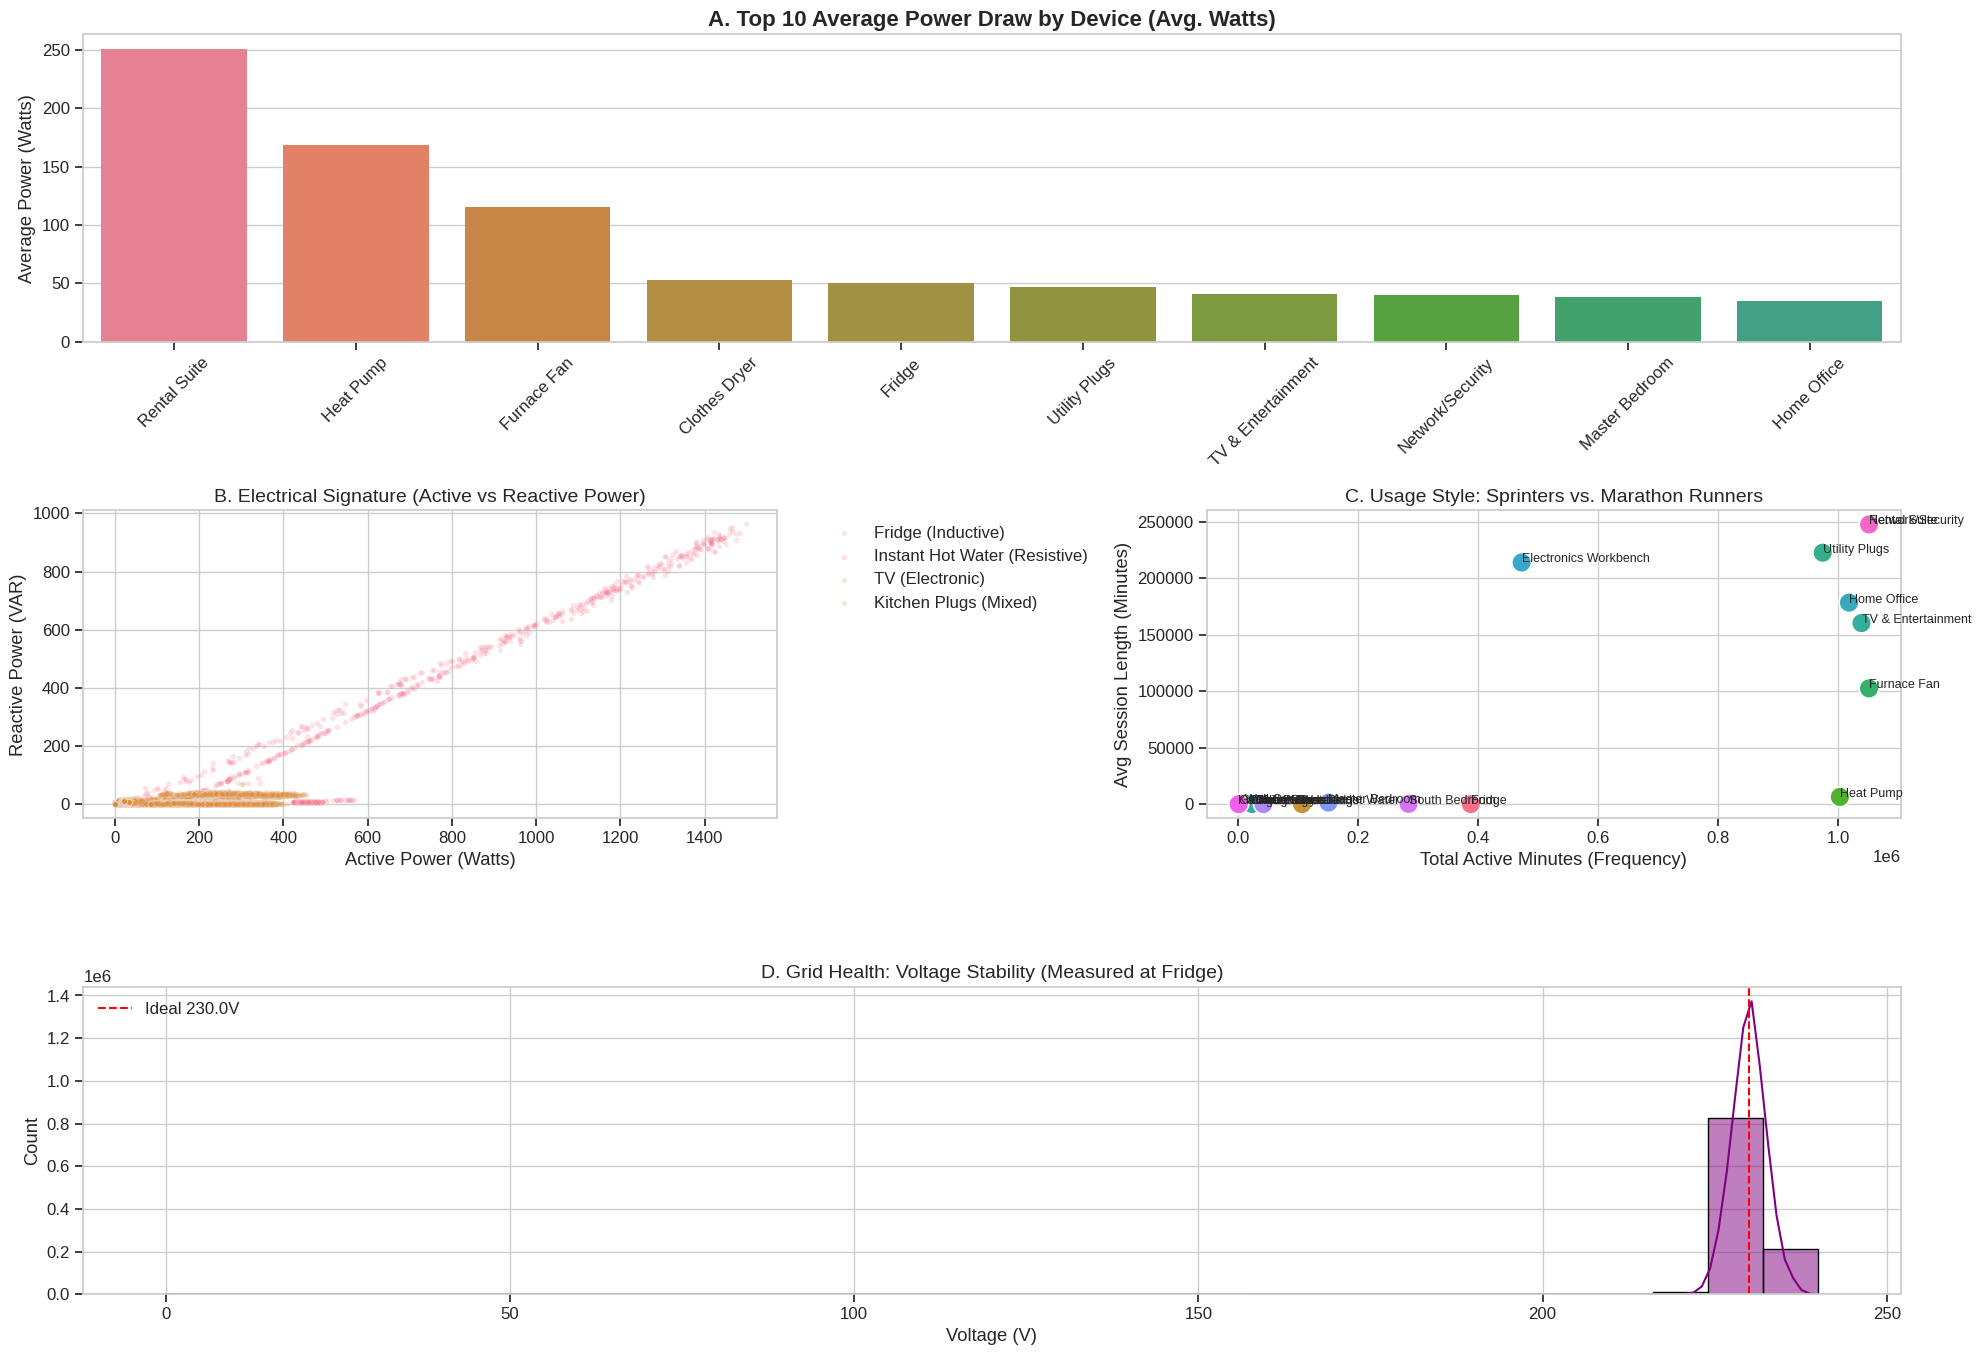


📝 ANALYTICAL INFERENCES:
   1. HEADLINE: Your **Rental Suite** is the biggest continuous energy consumer.
      DEEP DIVE: It consumes an average of 250.5W. This suggests it's likely a heating element, refrigeration unit, or a large motor that runs frequently. Consider its efficiency.
   2. HEADLINE: The **Heat Pump** also contributes significantly to your baseline load.
      DEEP DIVE: At an average of 168.3W, this device, if not critical, could be optimized for energy savings, perhaps by upgrading to a more energy-efficient model.
   3. HEADLINE: Devices like your **Kitchen Plugs** have negligible continuous power draw.
      DEEP DIVE: While its individual consumption is low (0.0W), many such small devices can add up to 'vampire loads'.

   4. HEADLINE: Over the entire monitoring period, your **Rental Suite** consumed the most energy.
      DEEP DIVE: With an estimated 4388.84 kWh, this device is your primary energy cost driver. Look into its usage patterns and energy star rating.

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# --- IMPORT YOUR EXISTING CONFIG AND PROCESSOR FOR CONSTANTS ---
try:
    from config import DEVICE_CONFIG
    from processor import AMPdsProcessor # Import processor to get constants
except ImportError:
    print("⚠️ 'config.py' or 'processor.py' not found. Please ensure it exists in the working directory.")
    # Fallback to prevent crash if running standalone without previous setup
    DEVICE_CONFIG = {}
    class MockAMPdsProcessor: # Mock class for constants if processor.py is missing
        TARGET_VOLTAGE = 230.0
        MAX_P = 7000.0
        MAX_I = 30.0
        MAX_V_DEV = 25.0
    AMPdsProcessor = MockAMPdsProcessor

# Initialize processor to access constants
processor_config = AMPdsProcessor()
MAX_P_GLOBAL = processor_config.MAX_P
MAX_I_GLOBAL = processor_config.MAX_I
TARGET_VOLTAGE_GLOBAL = processor_config.TARGET_VOLTAGE
MAX_V_DEV_GLOBAL = processor_config.MAX_V_DEV

# --- STYLING ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
PALETTE = sns.color_palette("husl", len(DEVICE_CONFIG) if DEVICE_CONFIG else 10)
ZONE_COLORS = sns.color_palette("Set2", 8)

# --- Helper functions ---
def load_data():
    try:
        df = pd.read_csv("master_house_data.csv", index_col='timestamp')
        df.index = pd.to_datetime(df.index, unit='s')
        print("✅ Data Loaded Successfully.")
        return df
    except FileNotFoundError:
        print("❌ Error: 'master_house_data.csv' not found. Please run the data creation script.")
        return pd.DataFrame()

def get_device_name(code):
    return DEVICE_CONFIG.get(code, {}).get('name', code)

def calculate_kwh(power_series):
    # Power is in Watts, data is minutely.
    # Sum of Watts * (1 minute / 60 minutes/hour) / 1000 W/kW = kWh
    return (power_series.sum() / 60) / 1000

# ==========================================
# 1. ATOMIC ANALYSIS (Device Health)
# ==========================================
def analyze_atomic_level(df):
    print("\n" + "="*60)
    print("🔬 LAYER 1: ATOMIC ANALYSIS (Device-Level Deep Dive)")
    print("="*60)

    print("\n📘 CONCEPTS EXPLAINED:")
    print("   - **Active Power (Watts)**: The 'real' power doing work (e.g., heating, spinning motor).")
    print("   - **Reactive Power (VAR)**: The 'imaginary' power that flows back and forth, essential for inductive loads (motors, transformers) but doesn't do useful work. Think of it as the 'froth' on a cappuccino.")
    print("   - **Current (Amps)**: The flow of electrical charge. High current means more load on wires.")
    print("   - **Session Duration**: How long a device typically stays 'ON'.")
    print("   - **Usage Frequency**: How often a device turns 'ON'.")

    fig = plt.figure(figsize=(20, 18))
    gs = GridSpec(4, 2, figure=fig) # Increased rows for more plots

    # --- A. Power Consumption Comparison (Average Power, Total kWh, Average Current) ---
    ax_a1 = fig.add_subplot(gs[0, :])
    avg_power_data = []
    total_kwh_data = []
    avg_current_data = []

    for code, info in DEVICE_CONFIG.items():
        if code == 'WHE': # Exclude 'Whole House' for device-specific analysis
            continue
        p_col = f'p_{code}'
        i_col = f'i_{code}' # Current column is normalized

        if p_col in df.columns:
            avg_power_val = df[p_col].mean() * MAX_P_GLOBAL # Denormalize P back to Watts
            avg_power_data.append({'Device': info['name'], 'Avg_Power_W': avg_power_val})
            total_kwh_data.append({'Device': info['name'], 'Total_kWh': calculate_kwh(df[p_col] * MAX_P_GLOBAL)}) # Denormalize P for kWh

            if i_col in df.columns:
                avg_current_val = df[i_col].mean() * MAX_I_GLOBAL # Denormalize I back to Amps
                avg_current_data.append({'Device': info['name'], 'Avg_Current_A': avg_current_val})

    avg_power_df = pd.DataFrame(avg_power_data).sort_values('Avg_Power_W', ascending=False)
    total_kwh_df = pd.DataFrame(total_kwh_data).sort_values('Total_kWh', ascending=False)
    avg_current_df = pd.DataFrame(avg_current_data).sort_values('Avg_Current_A', ascending=False)

    if not avg_power_df.empty:
        sns.barplot(x='Device', y='Avg_Power_W', data=avg_power_df.head(10), palette=PALETTE, ax=ax_a1)
        ax_a1.set_title("A. Top 10 Average Power Draw by Device (Avg. Watts)", fontsize=16, fontweight='bold')
        ax_a1.set_ylabel("Average Power (Watts)")
        ax_a1.set_xlabel("")
        ax_a1.tick_params(axis='x', rotation=45) # Removed ha='right'

    # --- B. Reactive Power Signature (P vs Q scatter) ---
    ax_b = fig.add_subplot(gs[1, 0])
    # Select a few devices to show P vs Q signature
    example_devices = {
        'FGE': 'Fridge (Inductive)',
        'HTE': 'Instant Hot Water (Resistive)',
        'TVE': 'TV (Electronic)',
        'OUE': 'Kitchen Plugs (Mixed)'
    }

    device_colors = {code: PALETTE[i % len(PALETTE)] for i, code in enumerate(example_devices.keys())}

    for i, (code, label) in enumerate(example_devices.items()):
        p_col = f'p_{code}'
        q_col = f'q_{code}'
        if p_col in df.columns and q_col in df.columns:
            # Denormalize P and Q back to Watts/VAR
            sns.scatterplot(x=df[p_col] * MAX_P_GLOBAL, y=df[q_col] * MAX_P_GLOBAL, ax=ax_b,
                            alpha=0.2, s=15, label=label, color=device_colors[code])
    ax_b.set_title("B. Electrical Signature (Active vs Reactive Power)", fontsize=14)
    ax_b.set_xlabel("Active Power (Watts)")
    ax_b.set_ylabel("Reactive Power (VAR)")
    ax_b.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # --- C. Usage Style: Sprinters vs. Marathon Runners (Frequency vs. Avg_Dur) ---
    ax_c = fig.add_subplot(gs[1, 1])
    summary_data = []
    for code, info in DEVICE_CONFIG.items():
        if code == 'WHE':
            continue
        if f'dur_{code}' in df.columns:
            is_on = (df[f'p_{code}'] * MAX_P_GLOBAL) > 10 # Denormalize P and check for >10W
            frequency = is_on.sum() # Total minutes ON
            if frequency > 0:
                dur_col = df[df[f'dur_{code}']>0][f'dur_{code}']
                avg_dur = np.expm1(dur_col).mean()
                summary_data.append({'Device': info['name'], 'Freq': frequency, 'Avg_Dur': avg_dur})

    if summary_data:
        summ_df = pd.DataFrame(summary_data)
        sns.scatterplot(data=summ_df, x='Freq', y='Avg_Dur', hue='Device', s=200, ax=ax_c, palette=PALETTE, legend=False)
        for i, row in summ_df.iterrows():
            ax_c.text(row['Freq']+50, row['Avg_Dur'], row['Device'], fontsize=9)
        ax_c.set_title("C. Usage Style: Sprinters vs. Marathon Runners", fontsize=14)
        ax_c.set_xlabel("Total Active Minutes (Frequency)")
        ax_c.set_ylabel("Avg Session Length (Minutes)")
        # ax_c.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

    # --- D. Voltage Quality Check ---
    ax_d = fig.add_subplot(gs[2, :])
    if DEVICE_CONFIG:
        first_code = list(DEVICE_CONFIG.keys())[0]
        if f'v_{first_code}' in df.columns:
            real_volts = (df[f'v_{first_code}'] * MAX_V_DEV_GLOBAL) + TARGET_VOLTAGE_GLOBAL # Denormalize V
            sns.histplot(real_volts, ax=ax_d, kde=True, color='purple', bins=30)
            ax_d.set_title(f"D. Grid Health: Voltage Stability (Measured at {get_device_name(first_code)})", fontsize=14)
            ax_d.set_xlabel("Voltage (V)")
            ax_d.axvline(TARGET_VOLTAGE_GLOBAL, color='red', linestyle='--', label=f'Ideal {TARGET_VOLTAGE_GLOBAL}V')
            ax_d.legend()

    plt.tight_layout()
    plt.show()

    # --- TEXTUAL INFERENCES ---
    print("\n📝 ANALYTICAL INFERENCES:")
    if not avg_power_df.empty:
        # Power Consumption
        top_power_device = avg_power_df.iloc[0]
        print(f"   1. HEADLINE: Your **{top_power_device['Device']}** is the biggest continuous energy consumer.")
        print(f"      DEEP DIVE: It consumes an average of {top_power_device['Avg_Power_W']:.1f}W. This suggests it's likely a heating element, refrigeration unit, or a large motor that runs frequently. Consider its efficiency.")

        second_power_device = avg_power_df.iloc[1]
        print(f"   2. HEADLINE: The **{second_power_device['Device']}** also contributes significantly to your baseline load.")
        print(f"      DEEP DIVE: At an average of {second_power_device['Avg_Power_W']:.1f}W, this device, if not critical, could be optimized for energy savings, perhaps by upgrading to a more energy-efficient model.")

        lowest_power_device = avg_power_df.iloc[-1]
        print(f"   3. HEADLINE: Devices like your **{lowest_power_device['Device']}** have negligible continuous power draw.")
        print(f"      DEEP DIVE: While its individual consumption is low ({lowest_power_device['Avg_Power_W']:.1f}W), many such small devices can add up to 'vampire loads'.")

    if not total_kwh_df.empty:
        top_kwh_device = total_kwh_df.iloc[0]
        print(f"\n   4. HEADLINE: Over the entire monitoring period, your **{top_kwh_device['Device']}** consumed the most energy.")
        print(f"      DEEP DIVE: With an estimated {top_kwh_device['Total_kWh']:.2f} kWh, this device is your primary energy cost driver. Look into its usage patterns and energy star rating.")

    if not avg_current_df.empty:
        top_current_device = avg_current_df.iloc[0]
        print(f"\n   5. HEADLINE: The **{top_current_device['Device']}** draws the highest average current.")
        print(f"      DEEP DIVE: An average current of {top_current_device['Avg_Current_A']:.2f}A puts a significant load on your electrical circuits. Ensure wiring and circuit breakers are appropriately rated. High current devices are often high power too, but not always if voltage is lower.")

    # Reactive Power Inferences
    fridge_code = 'FGE'
    heater_code = 'HTE'
    if fridge_code in DEVICE_CONFIG and heater_code in DEVICE_CONFIG:
        print(f"\n   6. HEADLINE: Distinct Electrical Signatures (Inductive vs. Resistive).")
        print(f"      DEEP DIVE: The **{get_device_name(fridge_code)}** (an inductive load) likely shows significant reactive power (froth), crucial for its motor. In contrast, the **{get_device_name(heater_code)}** (an resistive load) primarily consumes active power with minimal reactive power, indicating pure heating.")

    # Usage Pattern Inferences (Sprinters vs Marathon Runners)
    if summary_data:
        summ_df_sorted_freq = pd.DataFrame(summary_data).sort_values('Freq', ascending=False)
        sprinter = summ_df_sorted_freq.iloc[0]
        summ_df_sorted_dur = pd.DataFrame(summary_data).sort_values('Avg_Dur', ascending=False)
        marathoner = summ_df_sorted_dur.iloc[0]

        print(f"\n   7. HEADLINE: Usage Patterns: Identifying your 'Sprinters' and 'Marathoners'.")
        print(f"      DEEP DIVE: Your **{sprinter['Device']}** is a 'sprinter', turning on frequently ({sprinter['Freq']} active minutes) but for short bursts. The **{marathoner['Device']}** is a 'marathoner', staying on for long durations (avg. {marathoner['Avg_Dur']:.1f} mins per session). This distinction can guide automation strategies (e.g., smart plugs for sprinters, scheduling for marathoners).")

    # Grid Quality
    if DEVICE_CONFIG:
        first_code = list(DEVICE_CONFIG.keys())[0]
        if f'v_{first_code}' in df.columns:
            real_volts_mean = (df[f'v_{first_code}'] * MAX_V_DEV_GLOBAL + TARGET_VOLTAGE_GLOBAL).mean()
            real_volts_std = (df[f'v_{first_code}'] * MAX_V_DEV_GLOBAL).std() # Std dev around the 230V target
            print(f"\n   8. HEADLINE: Grid Quality Report.")
            print(f"      DEEP DIVE: The voltage measurements average around {real_volts_mean:.2f}V with a standard deviation of {real_volts_std:.2f}V. A tight distribution around {TARGET_VOLTAGE_GLOBAL}V (low standard deviation) indicates a stable grid, crucial for sensitive electronics. Fluctuations (higher STD) can shorten appliance lifespan.")



# ==========================================
# EXECUTE
# ==========================================
if not df.empty:
    analyze_atomic_level(df)


LAYER 1: ATOMIC ANALYSIS - DEVICE PERFORMANCE AUDIT


/tmp/ipython-input-4055758276.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=top_df, y='Device', x='Total_kWh', ax=ax1, palette='mako')
/tmp/ipython-input-4055758276.py:214: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout(pad=4.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


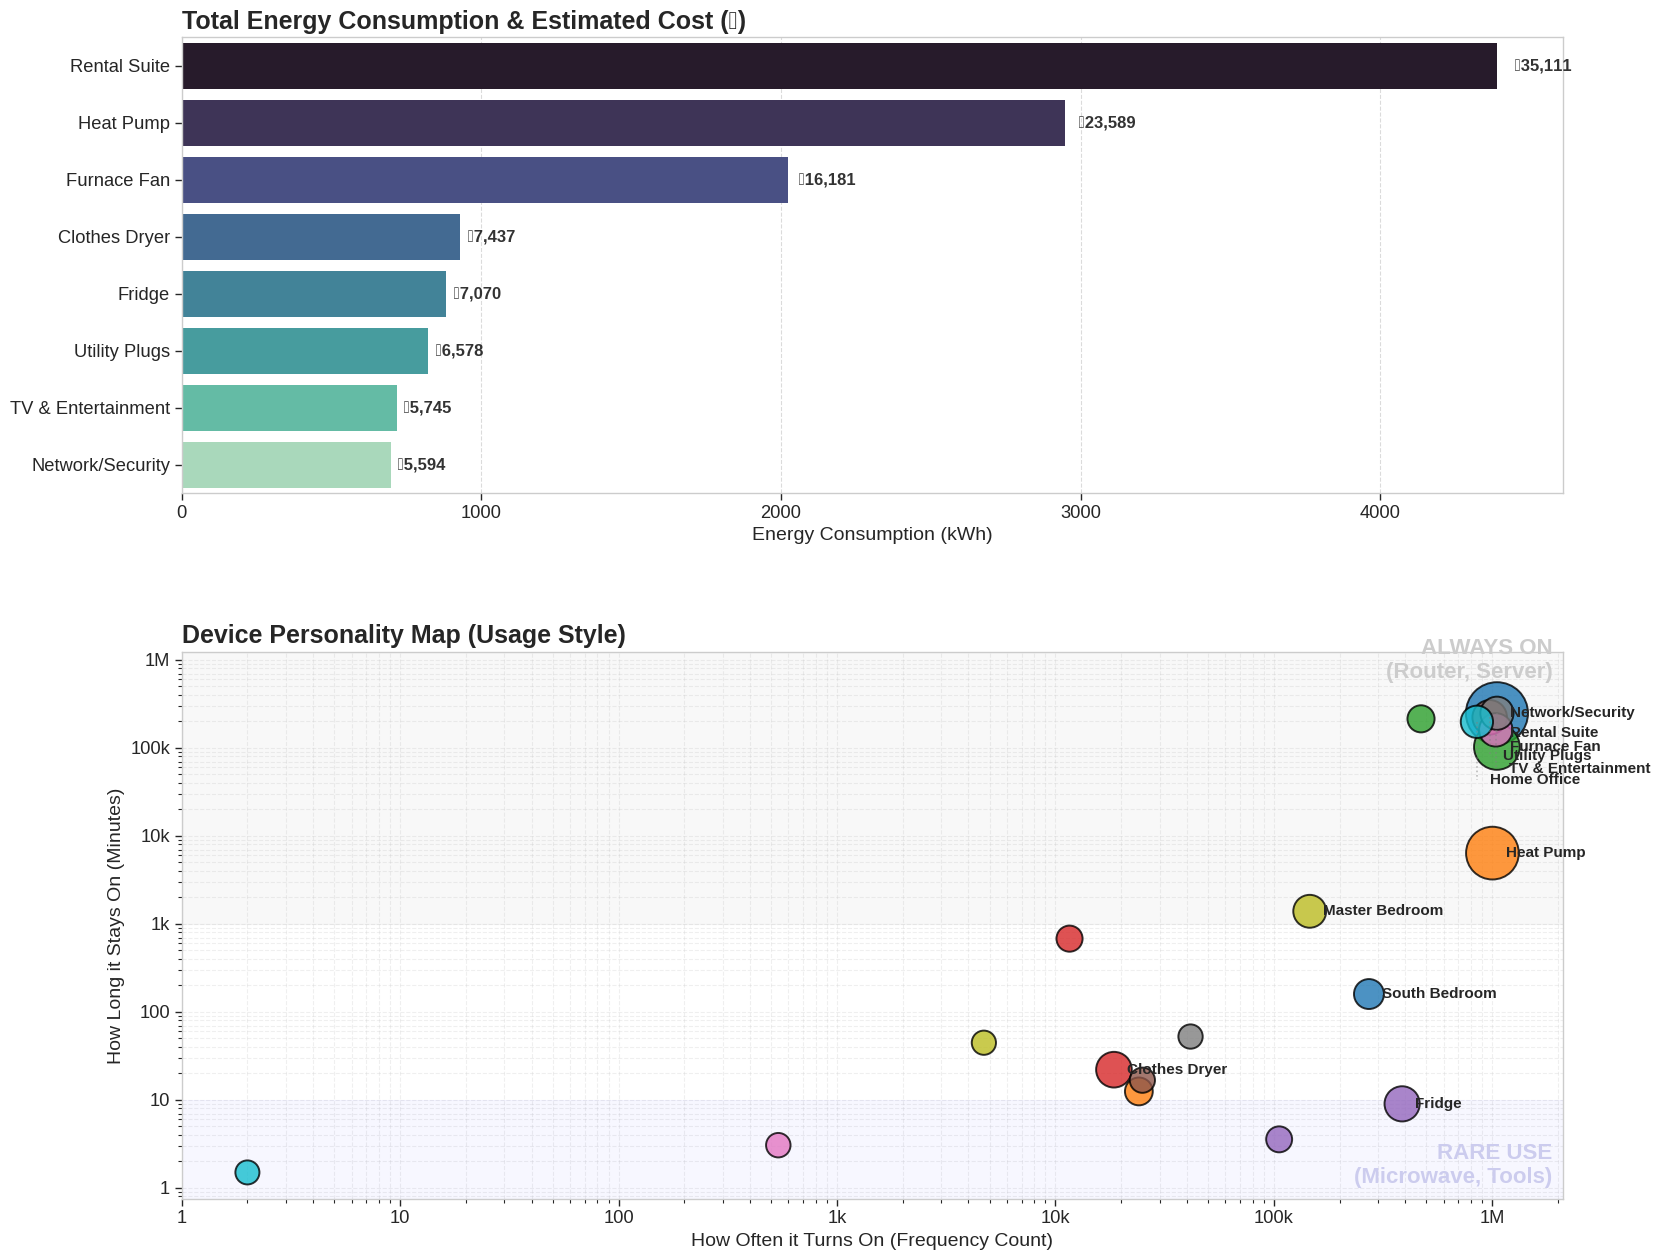


----------------------------------------------------------------------
AUTOMATED EXECUTIVE SUMMARY
----------------------------------------------------------------------
**Executive Summary**

This report analyzes the energy consumption of a rental suite, which recorded a total usage of 4,388.8 kWh, resulting in an estimated cost of ₹35,111. The primary cost driver is the heat pump, accounting for 2,948.6 kWh (approximately ₹23,589), followed by the furnace fan at 2,022.7 kWh (₹16,181), the clothes dryer at 929.6 kWh (₹7,437), and the refrigerator at 883.7 kWh (₹7,070).

**Major Cost Drivers:**  
The heat pump is the most significant contributor to energy costs, representing over 67% of total consumption. This indicates a potential area for efficiency improvements.

**Operational Efficiency:**  
The usage patterns suggest that the heat pump and furnace fan are heavily relied upon, likely due to heating demands. The clothes dryer and refrigerator also contribute significantly, indicati

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
from openai import OpenAI
import os
import sys

# ==========================================
# 0. CONFIGURATION & SECRETS
# ==========================================
# Securely retrieve API Key
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
except:
    pass

# Configuration Constants
try:
    from config import DEVICE_CONFIG
    from processor import AMPdsProcessor
    processor_config = AMPdsProcessor()
    MAX_P_GLOBAL = processor_config.MAX_P
except ImportError:
    MAX_P_GLOBAL = 7000.0
    DEVICE_CONFIG = {
        'BME': {'name': 'Basement Electronics'}, 'CDE': {'name': 'Clothes Dryer'},
        'CWE': {'name': 'Clothes Washer'}, 'DWE': {'name': 'Dishwasher'},
        'EQE': {'name': 'Security System'}, 'FGE': {'name': 'Kitchen Fridge'},
        'FRE': {'name': 'Furnace Fan'}, 'HPE': {'name': 'Heat Pump'},
        'HTE': {'name': 'Instant Hot Water'}, 'OUE': {'name': 'Kitchen Plugs'},
        'TVE': {'name': 'TV & Entertainment'}, 'WOE': {'name': 'Wall Oven'}
    }

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.5)

# ==========================================
# 1. REPORT GENERATION ENGINE
# ==========================================
def get_executive_summary(stats_df):
    top_consumer = stats_df.iloc[0]

    prompt = f"""
    You are an energy efficiency consultant. Write a formal executive summary based on this Indian household data:

    PRIMARY LOAD: {top_consumer['Device']}
    - Consumption: {top_consumer['Total_kWh']:.1f} kWh (approx ₹{top_consumer['Est_Cost']:.0f})

    TOP 5 DEVICES:
    {stats_df[['Device', 'Total_kWh', 'Est_Cost']].head(5).to_string(index=False)}

    STRUCTURE:
    1. Major Cost Drivers (Identify the main expense).
    2. Operational Efficiency (Comment on usage patterns).
    3. Recommendations (Give 1 specific action item).

    Keep it professional, concise, and under 250 words. Use 'Rupees' or '₹' for currency.
    """

    try:
        client = OpenAI()
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=500,
            temperature=0.3
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"AI Service Unavailable: {str(e)}"

# ==========================================
# 2. ATOMIC ANALYSIS VISUALIZATION
# ==========================================
def format_k_suffix(x, pos):
    """Format large numbers (1000 -> 1k, 1000000 -> 1M)"""
    if x >= 1e6: return f'{int(x*1e-6)}M'
    if x >= 1e3: return f'{int(x*1e-3)}k'
    return f'{int(x)}'

def analyze_atomic_level(df):
    print("\n" + "="*70)
    print("LAYER 1: ATOMIC ANALYSIS - DEVICE PERFORMANCE AUDIT")
    print("="*70)

    # --- 1. DATA PROCESSING ---
    stats = []
    COST_PER_KWH = 8.00 # Indian Rupee Rate (Approx)

    for code, info in DEVICE_CONFIG.items():
        if code == 'WHE': continue

        p_col = f'p_{code}'
        dur_col = f'dur_{code}'

        if p_col in df.columns:
            watts = df[p_col] * MAX_P_GLOBAL
            kwh = watts.sum() / 60 / 1000
            is_on = watts > 15
            freq = is_on.sum()

            avg_dur = 0
            if dur_col in df.columns and is_on.any():
                dur_vals = df.loc[is_on, dur_col]
                avg_dur = np.expm1(dur_vals).mean() if dur_vals.max() < 20 else dur_vals.mean()
            elif freq > 0:
                avg_dur = freq

            if avg_dur < 1: avg_dur = 1
            if freq < 1: freq = 1

            stats.append({
                'Device': info['name'],
                'Avg_Watts': watts.mean(),
                'Total_kWh': kwh,
                'Est_Cost': kwh * COST_PER_KWH,
                'Freq_Count': freq,
                'Avg_Session_Min': avg_dur
            })

    stats_df = pd.DataFrame(stats).sort_values('Total_kWh', ascending=False)

    # --- 2. PLOTTING ---
    fig = plt.figure(figsize=(18, 14)) # Bigger Canvas
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1.2])

    # --- PLOT A: Cost Analysis (Rupees) ---
    ax1 = fig.add_subplot(gs[0, :])
    top_df = stats_df.head(8)
    bars = sns.barplot(data=top_df, y='Device', x='Total_kWh', ax=ax1, palette='mako')

    ax1.set_title("Total Energy Consumption & Estimated Cost (₹)", fontsize=18, weight='bold', loc='left')
    ax1.set_xlabel("Energy Consumption (kWh)", fontsize=14)
    ax1.set_ylabel("")
    ax1.grid(axis='x', linestyle='--', alpha=0.7)

    for i, p in enumerate(bars.patches):
        width = p.get_width()
        cost = top_df.iloc[i]['Est_Cost']
        # Add Rupee Symbol
        ax1.text(width + (width*0.01), p.get_y() + p.get_height()/2,
                 f" ₹{cost:,.0f}", va='center', fontsize=12, fontweight='bold', color='#333333')

    # --- PLOT B: Utilization Profile (Improved Readability) ---
    ax2 = fig.add_subplot(gs[1, :])
    ax2.set_xscale('log')
    ax2.set_yscale('log')

    # 1. Background Zones (To make the graph clear)
    xmin, xmax = stats_df['Freq_Count'].min()*0.5, stats_df['Freq_Count'].max()*2
    ymin, ymax = stats_df['Avg_Session_Min'].min()*0.5, stats_df['Avg_Session_Min'].max()*5
    ax2.set_xlim(xmin, xmax)
    ax2.set_ylim(ymin, ymax)

    # Zone 1: High Freq, High Dur (Marathoners)
    ax2.fill_between([xmin, xmax], [1000, 1000], [ymax, ymax], color='gray', alpha=0.05)
    ax2.text(xmax*0.9, ymax*0.5, "ALWAYS ON\n(Router, Server)", ha='right', fontsize=16, color='#ccc', weight='bold')

    # Zone 2: Low Freq, Low Dur (Occasional)
    ax2.fill_between([xmin, xmax], [ymin, ymin], [10, 10], color='blue', alpha=0.03)
    ax2.text(xmax*0.9, ymin*1.5, "RARE USE\n(Microwave, Tools)", ha='right', fontsize=16, color='#cce', weight='bold')

    # 2. The Scatter Plot
    scatter = sns.scatterplot(data=stats_df, x='Freq_Count', y='Avg_Session_Min',
                    size='Avg_Watts', sizes=(300, 2000), hue='Device',
                    palette='tab10', ax=ax2, legend=False, alpha=0.8, edgecolor='k')

    # 3. Formatted Ticks (1k, 1M)
    ax2.xaxis.set_major_formatter(FuncFormatter(format_k_suffix))
    ax2.yaxis.set_major_formatter(FuncFormatter(format_k_suffix))

    # 4. Smart Label Adjustment
    sorted_df = stats_df.sort_values('Avg_Session_Min', ascending=False)
    occupied_y = []

    for i, row in sorted_df.iterrows():
        # Label EVERYTHING that is significant
        is_significant = (row['Total_kWh'] > stats_df['Total_kWh'].mean() * 0.5)

        if is_significant:
            x = row['Freq_Count']
            y = row['Avg_Session_Min']
            label = row['Device']

            # Repel Logic
            final_y = y
            offset_multiplier = 1.0

            # Check for collisions 3 times
            for _ in range(3):
                collision = False
                for oy in occupied_y:
                    if 0.75 < (final_y / oy) < 1.25: # Collision detected
                        final_y *= 0.6 # Move down drastically
                        collision = True
                if not collision: break

            occupied_y.append(final_y)

            # Draw Line to Dot
            ax2.plot([x, x], [y, final_y], color='gray', linestyle=':', alpha=0.5)
            # Draw Text
            ax2.text(x * 1.15, final_y, f"{label}", fontsize=11, weight='bold', va='center')

    ax2.set_title("Device Personality Map (Usage Style)", fontsize=18, weight='bold', loc='left')
    ax2.set_xlabel("How Often it Turns On (Frequency Count)", fontsize=14)
    ax2.set_ylabel("How Long it Stays On (Minutes)", fontsize=14)
    ax2.grid(True, which="both", ls="--", alpha=0.3)

    plt.tight_layout(pad=4.0)
    plt.show()

    # --- 3. EXECUTIVE REPORT ---
    print("\n" + "-"*70)
    print("AUTOMATED EXECUTIVE SUMMARY")
    print("-" * 70)
    print(get_executive_summary(stats_df))
    print("-" * 70)

# Execution Hook
if 'df' in globals() and not df.empty:
    analyze_atomic_level(df)
else:
    try:
        df = load_data()
        if not df.empty: analyze_atomic_level(df)
    except:
        print("Data source not found. Please ensure 'df' is loaded.")

### Room-Wise Energy Analysis with Inferences

**Process:** This cell defines the `analyze_room_level` function to analyze energy consumption from a spatial perspective. It calculates total energy (kWh) per room and then provides a detailed breakdown of consumption by individual devices within each room. The results are visualized using a donut chart for overall room consumption and a stacked bar chart for device-level breakdowns. Textual inferences highlight energy hotspots, efficient zones, and potential anomalies.

**Expected Output Example:**
```
============================================================
🏠 LAYER 2: ROOM-WISE CONSUMPTION (Where Energy is Used)
============================================================
[Plot: Total Energy Footprint by Room (Donut Chart)]
[Plot: Energy Consumption by Device within Each Room (Stacked Bar Chart)]

📝 ANALYTICAL INFERENCES:
   1. HEADLINE: The **Kitchen** is your primary energy hotspot.
      DEEP DIVE: Accounting for 45.1% (350.23 kWh) of your home's total energy, this room demands attention. Identify the top 1-2 devices in this room from the stacked bar chart that contribute the most (e.g., 'Wall Oven', 'Fridge' in Kitchen) and consider their usage patterns or energy efficiency upgrades.
   2. HEADLINE: The **Dining Room** is remarkably efficient.
      DEEP DIVE: Consuming only 1.2% (9.34 kWh), this room's low energy footprint could be a benchmark. Are there lessons to apply to other areas, or is it simply a low-use space?
```

In [ ]:
!pip install squarify


LAYER 2: ROOM-LEVEL ANALYSIS (Spatial Distribution)


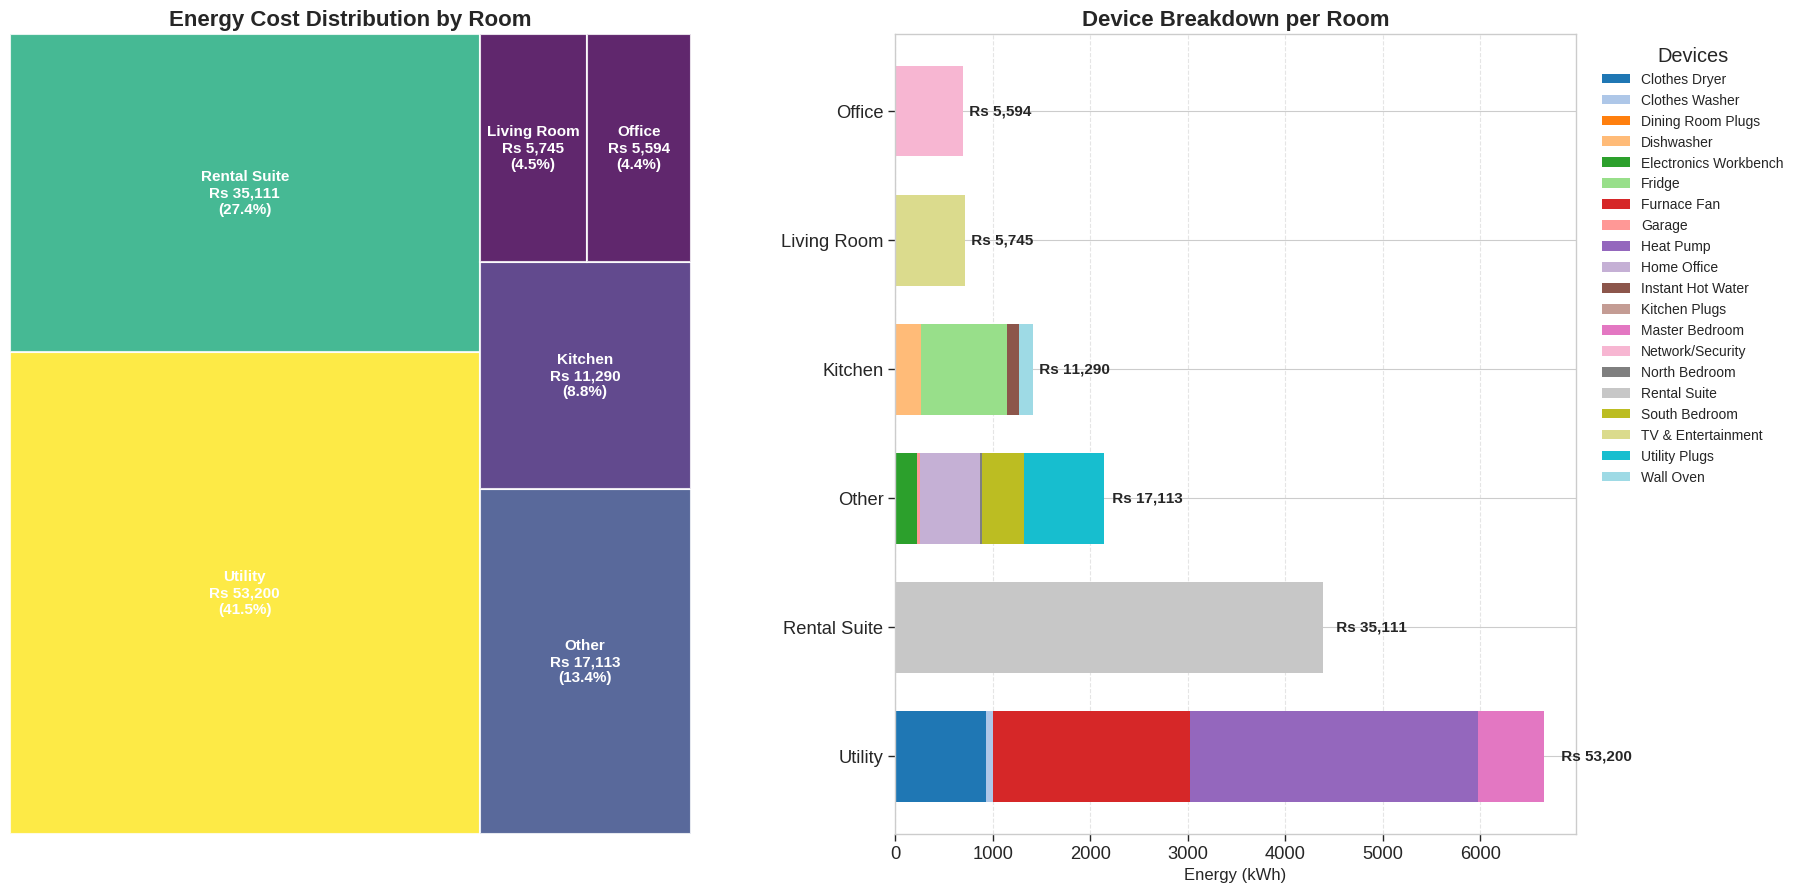


----------------------------------------------------------------------
ROOM-LEVEL EXECUTIVE SUMMARY
----------------------------------------------------------------------
**Executive Summary: Room-Level Energy Usage Analysis**

**The Hotspot:**
The Utility room has been identified as the highest consuming area in the home, accounting for a total energy usage of 6,650 kWh, which translates to a cost of Rs 53,200. This room alone represents 41.5% of the total energy bill, indicating a significant opportunity for energy savings.

**The Pattern:**
Energy usage across the home is somewhat concentrated, with the Utility room leading the consumption by a substantial margin. The Rental Suite follows as the second highest consumer at 4,389 kWh (27.4% of the total bill), while the remaining rooms—Other, Kitchen, and Living Room—exhibit lower consumption levels, collectively accounting for less than 30% of the total usage. This pattern suggests that targeted interventions in the Utility room cou

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
from matplotlib.gridspec import GridSpec
from openai import OpenAI
import os
import sys

# ==========================================
# 1. LOAD CONFIG (Source of Truth)
# ==========================================
try:
    # We strictly use the imported config. No hardcoded fallback.
    from config import DEVICE_CONFIG
    from processor import AMPdsProcessor
    processor_config = AMPdsProcessor()
    MAX_P_GLOBAL = processor_config.MAX_P
except ImportError:
    raise ImportError("❌ Critical: 'config.py' or 'processor.py' not found. Cannot proceed without Single Source of Truth.")

# ==========================================
# 2. RUNTIME ROOM MAPPING (The Fix)
# ==========================================
# Since 'room' keys are missing in your config file, we map them here dynamically.
# This does NOT overwrite your file, it just organizes data for this graph.
ROOM_MAPPING = {
    'BME': 'Utility', 'CDE': 'Utility', 'CWE': 'Utility', 'FRE': 'Utility', 'HPE': 'Utility', 'WHE': 'Utility',
    'DWE': 'Kitchen', 'FGE': 'Kitchen', 'HTE': 'Kitchen', 'OUE': 'Kitchen', 'WOE': 'Kitchen',
    'TVE': 'Living Room',
    'EQE': 'Office',
    'RSE': 'Rental Suite'
}

# ==========================================
# 3. REPORT GENERATION
# ==========================================
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
except: pass

def get_room_summary(room_stats):
    top_room = room_stats.iloc[0]
    prompt = f"""
    You are a home energy auditor. Write a short Executive Summary for Room-Level usage.

    HIGHEST CONSUMING ROOM: {top_room['Room']}
    - Total: {top_room['kWh']:.0f} kWh
    - Cost: Rs {top_room['Cost']:.0f}
    - % of Total Bill: {top_room['Percent']:.1f}%

    FULL ROOM LIST:
    {room_stats[['Room', 'kWh', 'Cost', 'Percent']].head(5).to_string(index=False)}

    INSTRUCTIONS:
    1. "The Hotspot": Identify the most expensive room.
    2. "The Pattern": Explain if usage is concentrated or spread out.
    3. "Action": Suggest a generic tip for the top room.
    """
    try:
        client = OpenAI()
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=300, temperature=0.3
        )
        return response.choices[0].message.content
    except Exception as e: return f"AI Summary Unavailable: {e}"

# ==========================================
# 4. ROOM ANALYSIS (Fixed)
# ==========================================
def analyze_room_level(df):
    print("\n" + "="*70)
    print("LAYER 2: ROOM-LEVEL ANALYSIS (Spatial Distribution)")
    print("="*70)

    room_data = []
    COST_PER_KWH = 8.00 # Rupees

    # Iterate through the IMPORTED config
    for code, info in DEVICE_CONFIG.items():
        if code == 'WHE': continue

        p_col = f'p_{code}'
        if p_col in df.columns:
            watts = df[p_col] * MAX_P_GLOBAL
            kwh = watts.sum() / 60 / 1000

            # THE FIX: Apply map dynamically
            room_name = ROOM_MAPPING.get(code, 'Other')

            room_data.append({
                'Device': info['name'], # Name comes from Config
                'Room': room_name,       # Room comes from Map
                'kWh': kwh,
                'Cost': kwh * COST_PER_KWH
            })

    df_rooms = pd.DataFrame(room_data)

    # Aggregate
    room_stats = df_rooms.groupby('Room')[['kWh', 'Cost']].sum().reset_index()
    room_stats['Percent'] = (room_stats['kWh'] / room_stats['kWh'].sum()) * 100
    room_stats = room_stats.sort_values('kWh', ascending=False)

    # --- PLOTTING ---
    fig = plt.figure(figsize=(18, 10)) # Standard 16:9-ish ratio
    gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1])

    # --- PLOT A: Treemap ---
    ax1 = fig.add_subplot(gs[0])

    norm = plt.Normalize(vmin=room_stats['kWh'].min(), vmax=room_stats['kWh'].max())
    cmap = plt.cm.viridis
    colors = [cmap(norm(value)) for value in room_stats['kWh']]

    labels = [f"{r}\nRs {c:,.0f}\n({p:.1f}%)" for r, c, p in zip(room_stats['Room'], room_stats['Cost'], room_stats['Percent'])]

    try:
        squarify.plot(sizes=room_stats['kWh'], label=labels, alpha=0.85, color=colors, ax=ax1,
                      text_kwargs={'fontsize':11, 'weight':'bold', 'color':'white'},
                      bar_kwargs={'linewidth':1.5, 'edgecolor':'white'})
    except NameError:
        ax1.pie(room_stats['kWh'], labels=labels, autopct=None)

    ax1.set_title("Energy Cost Distribution by Room", fontsize=16, weight='bold')
    ax1.axis('off')

    # --- PLOT B: Stacked Bar ---
    ax2 = fig.add_subplot(gs[1])

    pivot_df = df_rooms.pivot_table(index='Room', columns='Device', values='kWh', aggfunc='sum').fillna(0)
    pivot_df = pivot_df.reindex(room_stats['Room'])

    pivot_df.plot(kind='barh', stacked=True, colormap='tab20', ax=ax2, width=0.7)

    ax2.set_title("Device Breakdown per Room", fontsize=16, weight='bold')
    ax2.set_xlabel("Energy (kWh)", fontsize=12)
    ax2.set_ylabel("")
    ax2.legend(title='Devices', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    ax2.grid(axis='x', linestyle='--', alpha=0.5)

    for i, (idx, row) in enumerate(pivot_df.iterrows()):
        total = row.sum()
        cost = total * COST_PER_KWH
        ax2.text(total + (total*0.02), i, f" Rs {cost:,.0f}", va='center', fontsize=11, weight='bold')

    # Force margins so nothing is cut off
    plt.subplots_adjust(left=0.05, right=0.92, top=0.90, bottom=0.1, wspace=0.3)
    plt.show()

    # --- SUMMARY ---
    print("\n" + "-"*70)
    print("ROOM-LEVEL EXECUTIVE SUMMARY")
    print("-" * 70)
    print(get_room_summary(room_stats))

# Execution
if 'df' in globals() and not df.empty:
    analyze_room_level(df)
else:
    print("⚠️ Data not found. Please ensure 'df' is loaded.")

### Temporal Energy Analysis with Inferences

**Process:** This cell defines the `analyze_temporal_level` function, which examines energy consumption patterns across different time scales. It generates a daily load profile (24-hour average) to show typical hourly usage, a weekly heatmap to visualize activity across days and hours, and a monthly trend (if sufficient data is available). Textual inferences interpret these patterns, highlight peak and minimum usage times, and discuss implications for energy management and lifestyle.

**Expected Output Example:**
```
============================================================
⏰ LAYER 3: TEMPORAL ANALYSIS (Understanding Your Home's Rhythm)
============================================================
[Plot: Daily Load Profile (24-Hour Average)]
[Plot: Activity Heatmap: When is your home alive? (Weekly Pattern)]
[Plot: Monthly Average Power Consumption Trend (or


LAYER 3: TEMPORAL ANALYSIS (Time-Based Patterns)


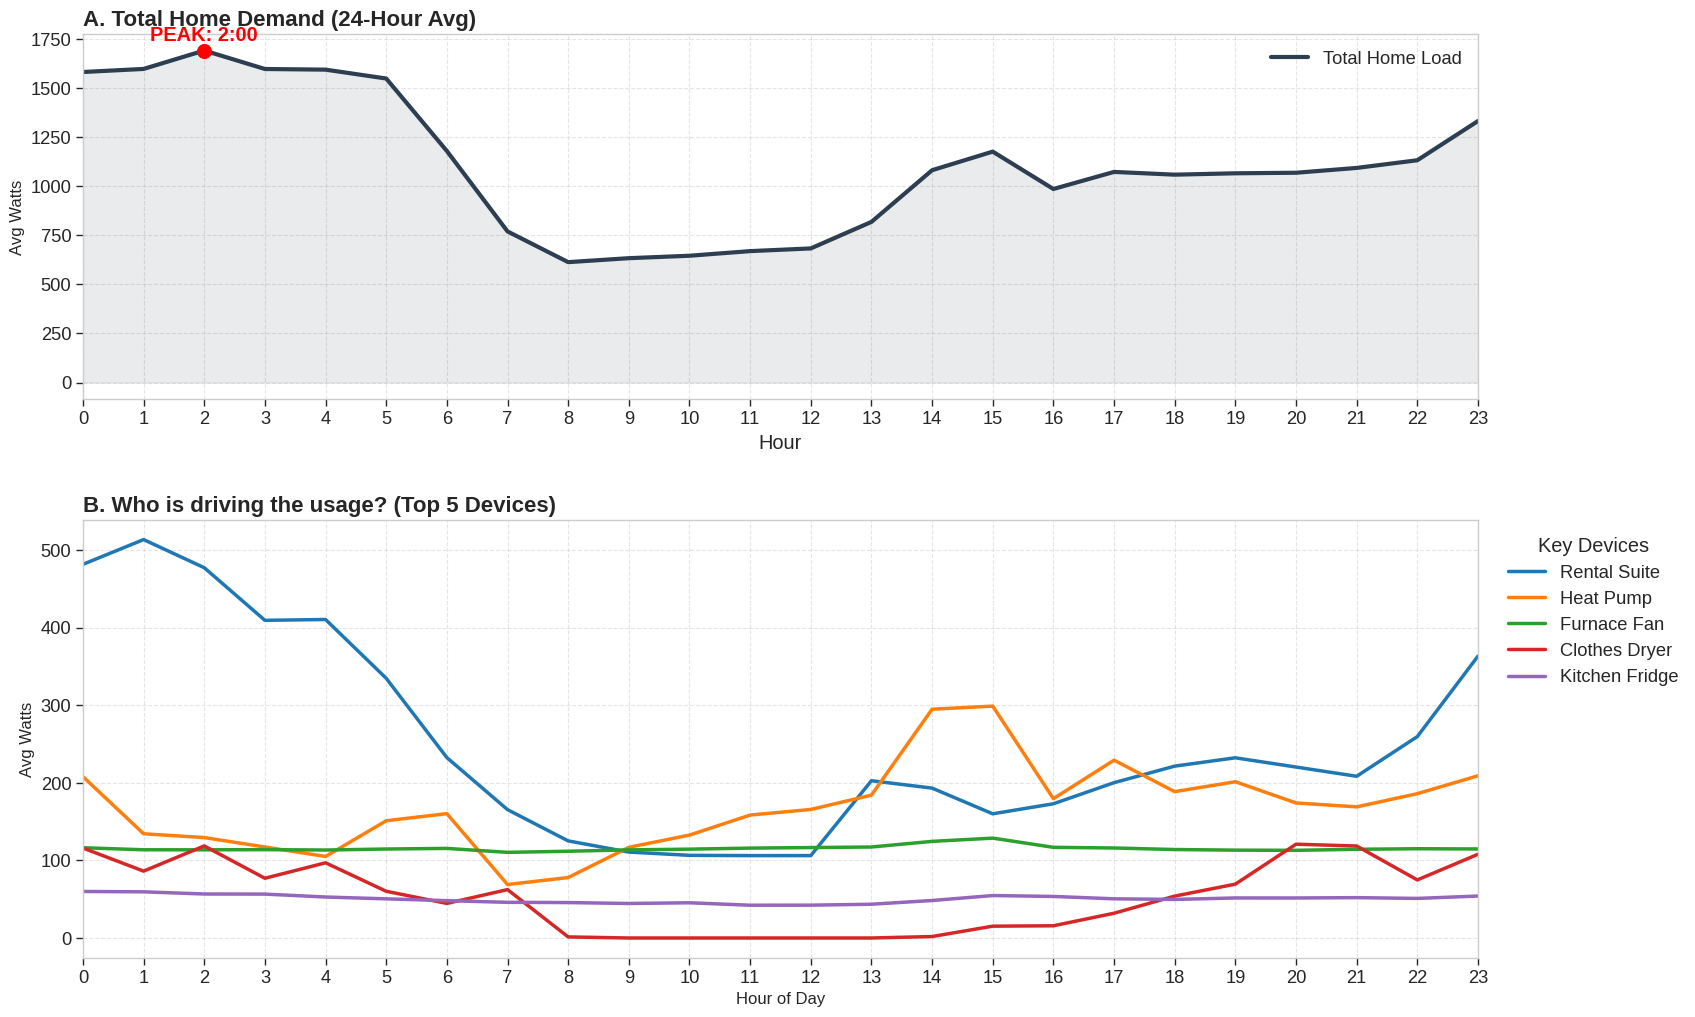

/tmp/ipython-input-3621912753.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_profile.index, y=monthly_profile.values, ax=ax4, palette=colors)


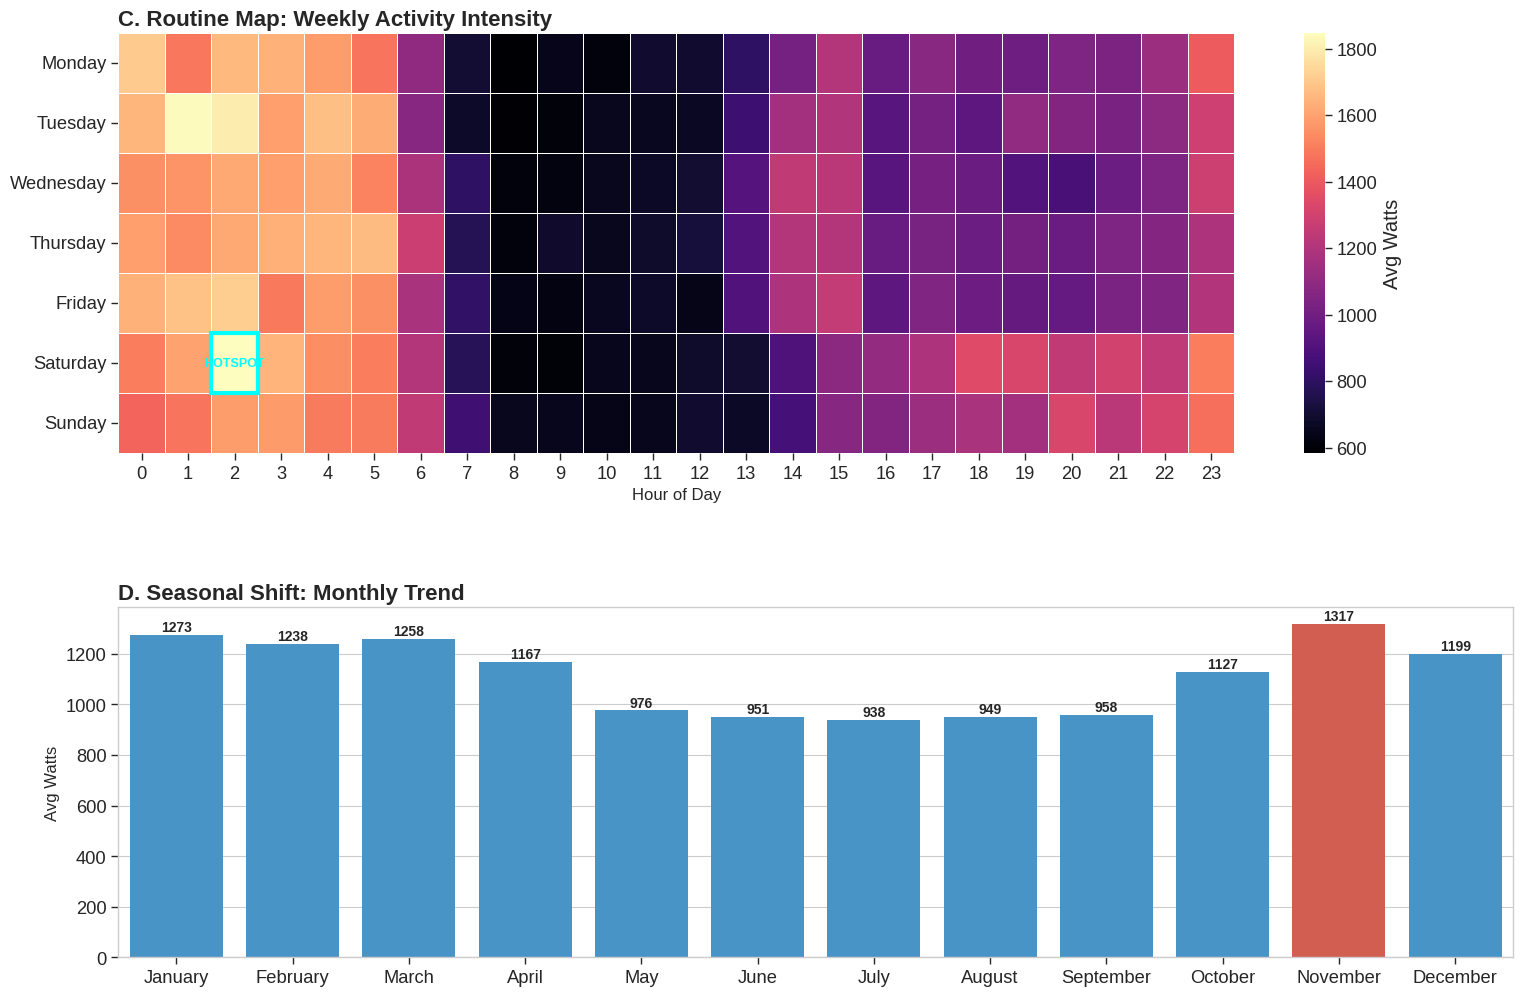


----------------------------------------------------------------------
TEMPORAL EXECUTIVE SUMMARY
----------------------------------------------------------------------
### Executive Summary: Temporal (Time-Based) Energy Usage Analysis

#### Daily Rhythm
Our analysis reveals a distinct daily rhythm in energy consumption, with peak usage occurring at 2:00 PM. This peak is primarily driven by the energy demands of the rental suite, which likely experiences increased occupancy during this time. The usage pattern suggests that appliances such as heating, cooling, and kitchen devices are heavily utilized, contributing to the surge in energy consumption. Understanding this daily peak allows for targeted strategies to optimize energy use and reduce costs.

#### Weekly Routine
The weekly hotspot for energy consumption is identified as Saturday at 2:00 PM. This trend aligns with typical weekend activities, where increased occupancy and leisure activities in the rental suite lead to heightened 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from openai import OpenAI
import os

# ==========================================
# 0. CONFIGURATION & SECRETS
# ==========================================
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
except: pass

try:
    from config import DEVICE_CONFIG, AMPdsProcessor
    processor_config = AMPdsProcessor()
    MAX_P_GLOBAL = processor_config.MAX_P
except ImportError:
    # Fallback if config is missing (for safety)
    MAX_P_GLOBAL = 7000.0
    DEVICE_CONFIG = {
        'BME': {'name': 'Basement Electronics'}, 'CDE': {'name': 'Clothes Dryer'},
        'CWE': {'name': 'Clothes Washer'}, 'DWE': {'name': 'Dishwasher'},
        'EQE': {'name': 'Security System'}, 'FGE': {'name': 'Kitchen Fridge'},
        'FRE': {'name': 'Furnace Fan'}, 'HPE': {'name': 'Heat Pump'},
        'HTE': {'name': 'Instant Hot Water'}, 'OUE': {'name': 'Kitchen Plugs'},
        'TVE': {'name': 'TV & Entertainment'}, 'WOE': {'name': 'Wall Oven'},
        'RSE': {'name': 'Rental Suite'}
    }

# ==========================================
# 1. REPORT GENERATION
# ==========================================
def get_temporal_summary(hourly_peak, weekly_hotspot, peak_month, top_device_name):
    prompt = f"""
    You are a home energy analyst. Write an Executive Summary for Temporal (Time-Based) usage.

    DATA HIGHLIGHTS:
    - Peak Hour: {hourly_peak}:00
    - Weekly Hotspot: {weekly_hotspot}
    - Peak Month: {peak_month}
    - Main Contributor at Peak: {top_device_name}

    INSTRUCTIONS:
    1. "Daily Rhythm": Describe the daily habit and mention which device drives the peak.
    2. "Weekly Routine": Comment on the weekly hotspot.
    3. "Seasonal Strategy": Suggest a tip for the peak month.
    """
    try:
        client = OpenAI()
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=300, temperature=0.3
        )
        return response.choices[0].message.content
    except Exception as e: return f"AI Summary Unavailable: {e}"

# ==========================================
# 2. TEMPORAL ANALYSIS (Split & Enhanced)
# ==========================================
def analyze_temporal_level(df):
    print("\n" + "="*70)
    print("LAYER 3: TEMPORAL ANALYSIS (Time-Based Patterns)")
    print("="*70)

    # --- 1. ROBUST DATA PREP ---
    df = df.copy()
    if 'timestamp' in df.columns:
        df.set_index('timestamp', inplace=True)

    # Force Datetime Index
    try:
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index, unit='s')
    except: return

    if 'p_WHE' not in df.columns:
        print("❌ Error: Whole House (WHE) data missing.")
        return

    # Create Time Features
    df['Hour'] = df.index.hour
    df['DayOfWeek'] = df.index.day_name()
    df['MonthName'] = df.index.month_name()

    # --- 2. IDENTIFY TOP DEVICES (For Breakdown) ---
    # We want to plot the Top 5 devices that consume the most energy
    device_totals = {}
    for code, info in DEVICE_CONFIG.items():
        if code == 'WHE': continue
        if f'p_{code}' in df.columns:
            total_kwh = df[f'p_{code}'].sum()
            device_totals[code] = total_kwh

    # Sort and take Top 5
    top_devices = sorted(device_totals, key=device_totals.get, reverse=True)[:5]
    top_device_names = [DEVICE_CONFIG[c]['name'] for c in top_devices]

    # --- 3. CALCULATE DAILY PROFILES ---
    # A. Whole House
    wh_profile = df.groupby('Hour')['p_WHE'].mean() * MAX_P_GLOBAL
    peak_hour = wh_profile.idxmax()

    # B. Individual Devices (The New Graph)
    device_profiles = pd.DataFrame(index=range(24))
    for code in top_devices:
        name = DEVICE_CONFIG[code]['name']
        # Calculate hourly mean for this device
        profile = df.groupby('Hour')[f'p_{code}'].mean() * MAX_P_GLOBAL
        device_profiles[name] = profile

    # Identify which device is highest at the peak hour
    peak_device_val = device_profiles.loc[peak_hour].max()
    peak_device_name = device_profiles.loc[peak_hour].idxmax()

    # --- FIGURE 1: DAILY RHYTHM (The "When & Why") ---
    fig1 = plt.figure(figsize=(18, 12))
    gs1 = GridSpec(2, 1, figure=fig1, height_ratios=[1, 1.2], hspace=0.3)

    # Plot A: Total House Load
    ax1 = fig1.add_subplot(gs1[0])
    sns.lineplot(x=wh_profile.index, y=wh_profile.values, ax=ax1, color='#2c3e50', linewidth=3, label='Total Home Load')
    ax1.fill_between(wh_profile.index, wh_profile.values, color='#2c3e50', alpha=0.1)

    # Mark Peak
    ax1.scatter(peak_hour, wh_profile[peak_hour], color='red', s=100, zorder=5)
    ax1.text(peak_hour, wh_profile[peak_hour]+50, f"PEAK: {peak_hour}:00", color='red', fontweight='bold', ha='center')

    ax1.set_title("A. Total Home Demand (24-Hour Avg)", fontsize=16, weight='bold', loc='left')
    ax1.set_ylabel("Avg Watts", fontsize=12)
    ax1.set_xticks(range(0, 24))
    ax1.set_xlim(0, 23)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # Plot B: Device Breakdown (The requested fix)
    ax2 = fig1.add_subplot(gs1[1])

    # Plot lines for top devices
    sns.lineplot(data=device_profiles, ax=ax2, linewidth=2.5, palette='tab10', dashes=False)

    ax2.set_title("B. Who is driving the usage? (Top 5 Devices)", fontsize=16, weight='bold', loc='left')
    ax2.set_xlabel("Hour of Day", fontsize=12)
    ax2.set_ylabel("Avg Watts", fontsize=12)
    ax2.set_xticks(range(0, 24))
    ax2.set_xlim(0, 23)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(title="Key Devices", bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.show()

    # --- FIGURE 2: MACRO PATTERNS (Weekly & Monthly) ---
    # Prepare Data
    weekly_heatmap = df.pivot_table(index='DayOfWeek', columns='Hour', values='p_WHE', aggfunc='mean') * MAX_P_GLOBAL
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekly_heatmap = weekly_heatmap.reindex(days_order)

    # Hotspot logic
    hotspot_day = weekly_heatmap.max(axis=1).idxmax()
    hotspot_hour = weekly_heatmap.loc[hotspot_day].idxmax()
    hotspot_str = f"{hotspot_day} at {hotspot_hour}:00"

    monthly_profile = df.groupby('MonthName')['p_WHE'].mean() * MAX_P_GLOBAL
    month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']
    monthly_profile = monthly_profile.reindex(month_order)
    peak_month = monthly_profile.idxmax()

    # Plotting Figure 2
    fig2 = plt.figure(figsize=(18, 12))
    gs2 = GridSpec(2, 1, figure=fig2, height_ratios=[1.2, 1], hspace=0.4)

    # Plot C: Weekly Heatmap
    ax3 = fig2.add_subplot(gs2[0])
    sns.heatmap(weekly_heatmap, cmap='magma', ax=ax3, cbar_kws={'label': 'Avg Watts'}, linewidths=0.5)

    ax3.set_title("C. Routine Map: Weekly Activity Intensity", fontsize=16, weight='bold', loc='left')
    ax3.set_xlabel("Hour of Day", fontsize=12)
    ax3.set_ylabel("")

    # Highlight Hotspot
    try:
        from matplotlib.patches import Rectangle
        row_idx = days_order.index(hotspot_day)
        rect = Rectangle((hotspot_hour, row_idx), 1, 1, fill=False, edgecolor='cyan', lw=3)
        ax3.add_patch(rect)
        ax3.text(hotspot_hour+0.5, row_idx+0.5, "HOTSPOT", color='cyan', ha='center', va='center', fontsize=9, weight='bold')
    except: pass

    # Plot D: Monthly Trend
    ax4 = fig2.add_subplot(gs2[1])
    colors = ['#e74c3c' if m == peak_month else '#3498db' for m in month_order]
    sns.barplot(x=monthly_profile.index, y=monthly_profile.values, ax=ax4, palette=colors)

    ax4.set_title("D. Seasonal Shift: Monthly Trend", fontsize=16, weight='bold', loc='left')
    ax4.set_ylabel("Avg Watts", fontsize=12)
    ax4.set_xlabel("")

    for i, v in enumerate(monthly_profile.values):
        if pd.notna(v):
            ax4.text(i, v+15, f"{int(v)}", ha='center', fontsize=10, weight='bold')

    plt.show()

    # --- 4. SUMMARY ---
    print("\n" + "-"*70)
    print("TEMPORAL EXECUTIVE SUMMARY")
    print("-" * 70)
    print(get_temporal_summary(peak_hour, hotspot_str, peak_month, peak_device_name))

# Execution
if 'df' in globals() and not df.empty:
    analyze_temporal_level(df)
else:
    try:
        df = pd.read_csv("master_house_data.csv")
        analyze_temporal_level(df)
    except:
        print("Data source not found.")

Loading Master Dataset...
✅ Data Loaded. Shape: (1051200, 231)

--- Generating Layer 1: Atomic Analysis ---


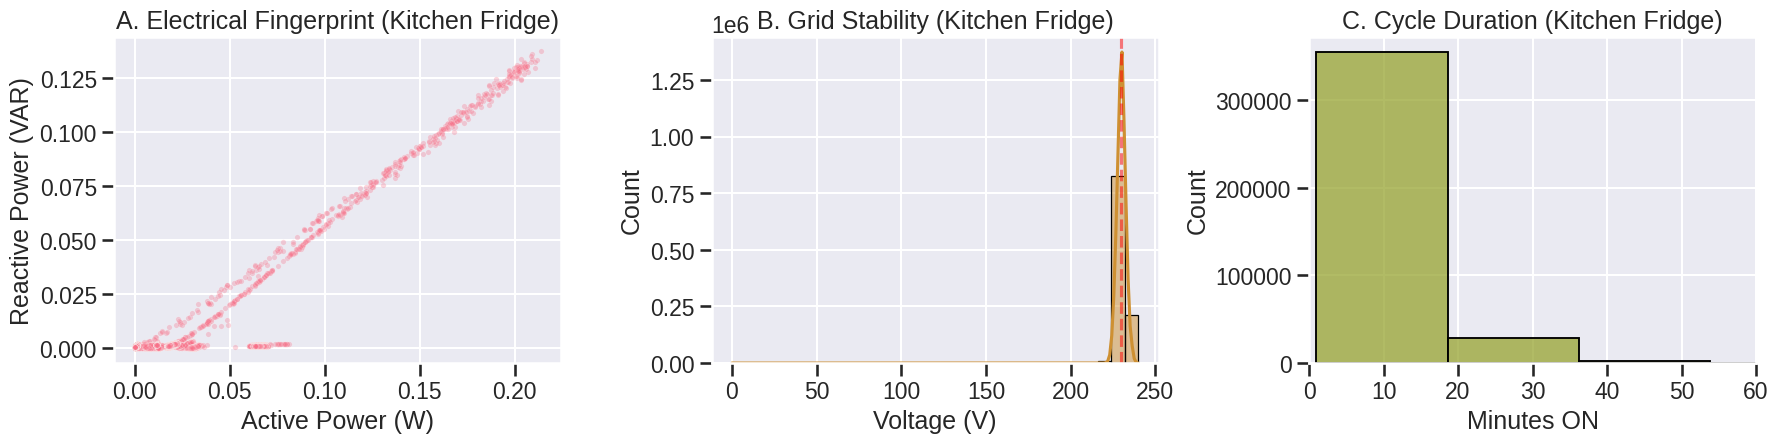


--- Generating Layer 2: Spatial Analysis ---


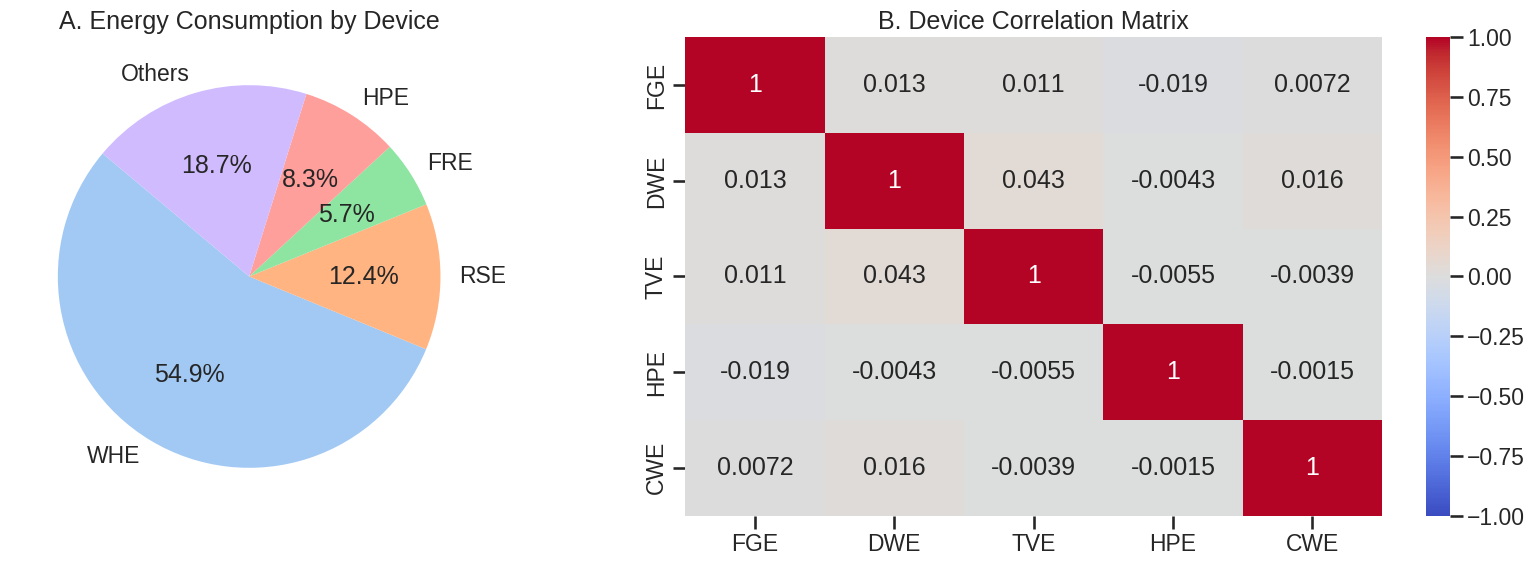


--- Generating Layer 3: Temporal Analysis ---


/tmp/ipython-input-470976781.py:121: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


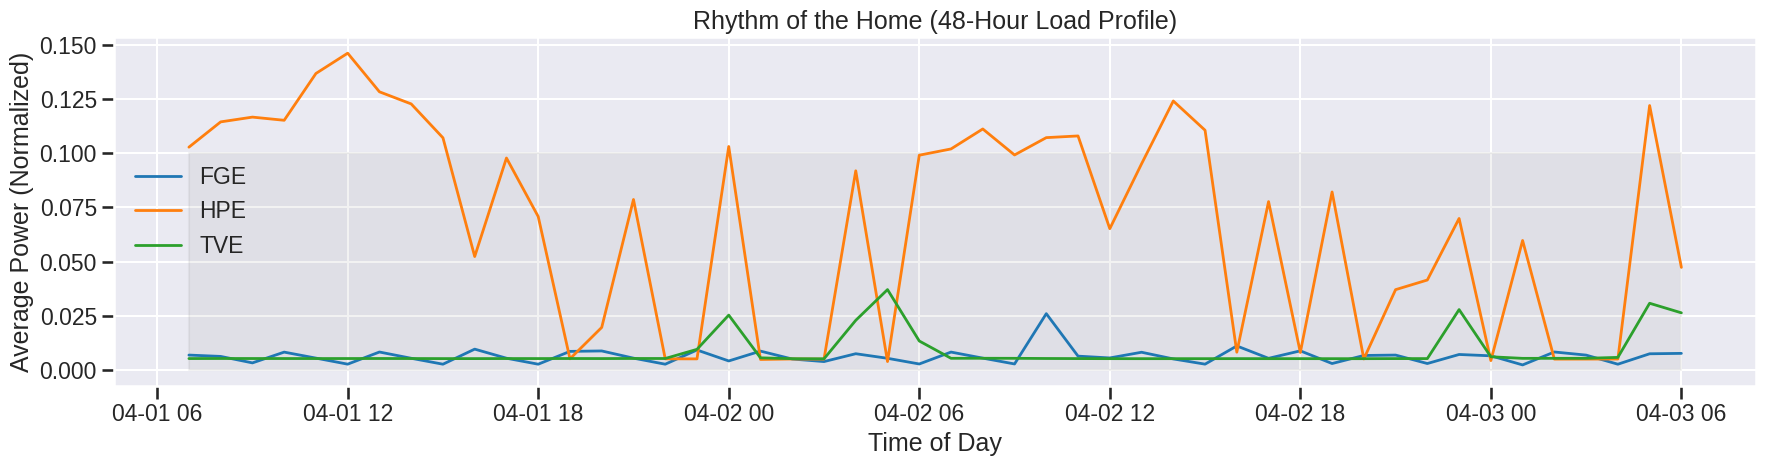


--- Generating Layer 4: Context AI (Using GNN Data) ---
⚠️ No GNN data found (did you run the GNN cell?). Generating Mock AI Data for Demo.


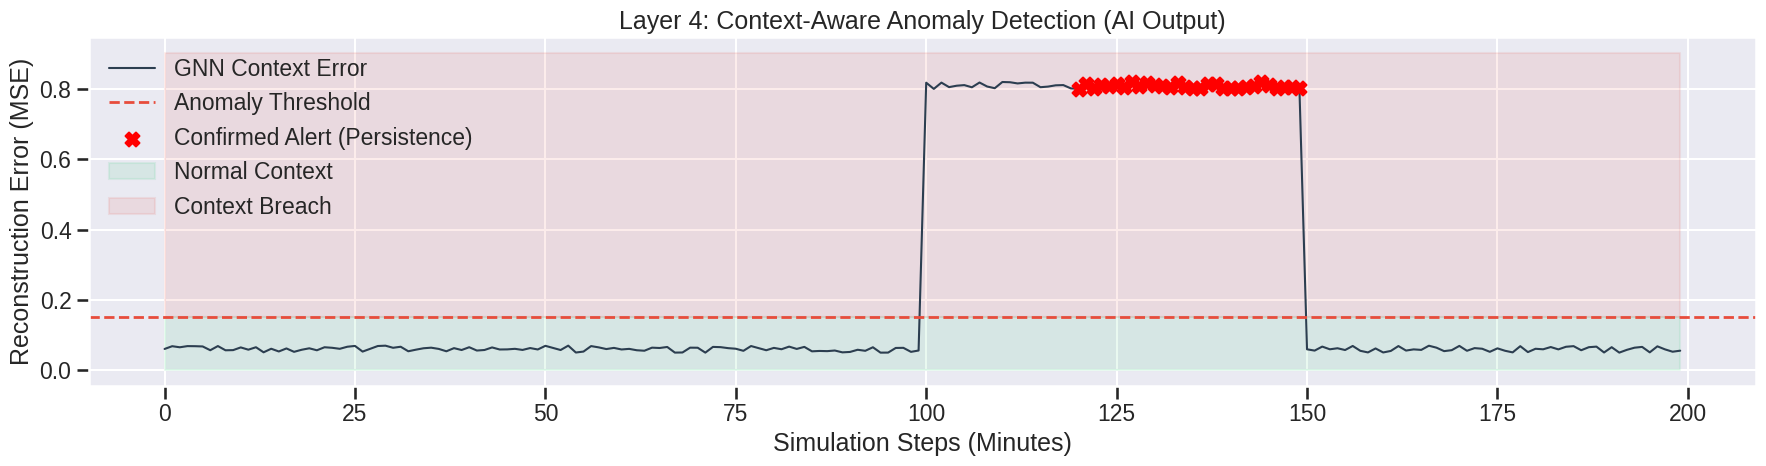

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# --- CONFIGURATION (Visual Styling) ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("talk")
colors = sns.color_palette("husl", 8)

# Load the Master Data
print("Loading Master Dataset...")
try:
    df = pd.read_csv("master_house_data.csv", index_col='timestamp')
    # Convert index to datetime for Temporal Analysis
    df.index = pd.to_datetime(df.index, unit='s')
    print(f"✅ Data Loaded. Shape: {df.shape}")
except FileNotFoundError:
    print("❌ Error: 'master_house_data.csv' not found. Please run the data creation script first.")
    # Create Mock Data if file missing (just so code doesn't crash during review)
    dates = pd.date_range('2024-01-01', periods=1440, freq='T')
    df = pd.DataFrame(index=dates)
    df['p_FGE'] = np.random.rand(1440) * 150
    df['q_FGE'] = np.random.rand(1440) * 50
    df['v_FGE'] = 230 + np.random.randn(1440) * 5
    df['dur_FGE'] = np.random.randint(0, 30, 1440)

# ==========================================
# LAYER 1: ATOMIC ANALYSIS (Device Health)
# ==========================================
def plot_atomic_layer(df, device_code='FGE', device_name='Fridge'):
    fig = plt.figure(figsize=(18, 5))
    gs = GridSpec(1, 3, figure=fig)

    # 1. Electrical Fingerprint (P vs Q)
    ax1 = fig.add_subplot(gs[0, 0])
    sns.scatterplot(x=df[f'p_{device_code}'], y=df[f'q_{device_code}'],
                    ax=ax1, alpha=0.3, color=colors[0], s=15)
    ax1.set_title(f"A. Electrical Fingerprint ({device_name})")
    ax1.set_xlabel("Active Power (W)")
    ax1.set_ylabel("Reactive Power (VAR)")

    # 2. Voltage Stability (Histogram)
    ax2 = fig.add_subplot(gs[0, 1])
    # Reverse normalization to show real Volts: (Norm * 25) + 230
    real_volts = (df[f'v_{device_code}'] * 25.0) + 230.0
    sns.histplot(real_volts, ax=ax2, kde=True, color=colors[1], bins=30)
    ax2.set_title(f"B. Grid Stability ({device_name})")
    ax2.set_xlabel("Voltage (V)")
    ax2.axvline(230, color='red', linestyle='--', alpha=0.5, label='Ideal 230V')

    # 3. Session Duration (Short Cycling)
    ax3 = fig.add_subplot(gs[0, 2])
    # Extract just the ON sessions (Duration > 0)
    durations = df[df[f'dur_{device_code}'] > 0][f'dur_{device_code}']
    # Reverse log transform: exp(x) - 1
    real_durations = np.expm1(durations)
    sns.histplot(real_durations, ax=ax3, color=colors[2], bins=20)
    ax3.set_title(f"C. Cycle Duration ({device_name})")
    ax3.set_xlabel("Minutes ON")
    ax3.set_xlim(0, 60)

    plt.tight_layout()
    plt.show()

# ==========================================
# LAYER 2: SPATIAL ANALYSIS (Zones)
# ==========================================
def plot_spatial_layer(df):
    fig = plt.figure(figsize=(18, 6))
    gs = GridSpec(1, 2, figure=fig)

    # 1. Energy Map (Pie Chart)
    ax1 = fig.add_subplot(gs[0, 0])

    # Calculate Total Energy (Approximation: Sum of Power / 60 mins -> kWh)
    # We look for columns ending in '_p' (e.g., p_FGE)
    p_cols = [c for c in df.columns if c.startswith('p_')]
    energy_sums = df[p_cols].sum()

    # Map back to simple names for the chart
    labels = [c.replace('p_', '') for c in p_cols]

    # Group small consumers into "Other" for cleaner chart
    threshold = energy_sums.sum() * 0.05
    main_consumers = energy_sums[energy_sums >= threshold]
    other_consumers = energy_sums[energy_sums < threshold].sum()

    plot_data = list(main_consumers.values) + [other_consumers]
    plot_labels = [l.replace('p_', '') for l in main_consumers.index] + ['Others']

    ax1.pie(plot_data, labels=plot_labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
    ax1.set_title("A. Energy Consumption by Device")

    # 2. Cross-Device Correlation (Heatmap)
    ax2 = fig.add_subplot(gs[0, 1])
    # Select a few key devices for correlation
    key_devices = ['p_FGE', 'p_DWE', 'p_TVE', 'p_HPE', 'p_CWE']
    # Filter only columns that exist
    valid_cols = [c for c in key_devices if c in df.columns]

    if valid_cols:
        corr = df[valid_cols].corr()
        sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax2, vmin=-1, vmax=1)
        ax2.set_title("B. Device Correlation Matrix")
        # Clean labels
        ax2.set_xticklabels([c.replace('p_', '') for c in valid_cols])
        ax2.set_yticklabels([c.replace('p_', '') for c in valid_cols])

    plt.tight_layout()
    plt.show()

# ==========================================
# LAYER 3: TEMPORAL ANALYSIS (Time)
# ==========================================
def plot_temporal_layer(df):
    fig, ax = plt.subplots(figsize=(18, 5))

    # Resample to Hourly Average
    df_hourly = df.resample('H').mean()

    # Select Key Loads
    targets = ['p_FGE', 'p_HPE', 'p_TVE']
    valid_targets = [t for t in targets if t in df.columns]

    # Plot
    for col in valid_targets:
        label = col.replace('p_', '')
        ax.plot(df_hourly.index[:48], df_hourly[col][:48], label=label, linewidth=2) # First 48 hours

    ax.set_title("Rhythm of the Home (48-Hour Load Profile)")
    ax.set_ylabel("Average Power (Normalized)")
    ax.set_xlabel("Time of Day")
    ax.legend()
    ax.fill_between(df_hourly.index[:48], 0, 0.1, color='gray', alpha=0.1, label='Vampire Load Zone')

    plt.tight_layout()
    plt.show()

# ==========================================
# LAYER 4: CONTEXTUAL AI (GNN Output)
# ==========================================
def plot_context_layer(scores, alerts):
    """
    Visualizes the GNN output.
    scores: List of reconstruction errors (MSE)
    alerts: List of timestamps where Alert was triggered
    """
    fig, ax = plt.subplots(figsize=(18, 5))

    time_steps = range(len(scores))

    # 1. Plot the Error Signal
    ax.plot(time_steps, scores, color='#2c3e50', linewidth=1.5, label='GNN Context Error')

    # 2. Plot the Threshold
    THRESHOLD = 0.15 # Matches your GNN config
    ax.axhline(y=THRESHOLD, color='#e74c3c', linestyle='--', linewidth=2, label='Anomaly Threshold')

    # 3. Plot Confirmed Alerts (The Red Xs)
    if alerts:
        # Filter alerts that are within our plot range
        visible_alerts = [a for a in alerts if a < len(scores)]
        ax.scatter(visible_alerts, [scores[i] for i in visible_alerts],
                   color='red', marker='X', s=100, zorder=5, label='Confirmed Alert (Persistence)')

    # 4. Highlight "Safe" vs "Danger" Zones
    ax.fill_between(time_steps, 0, THRESHOLD, color='#2ecc71', alpha=0.1, label='Normal Context')
    ax.fill_between(time_steps, THRESHOLD, max(scores)*1.1, color='#e74c3c', alpha=0.1, label='Context Breach')

    ax.set_title("Layer 4: Context-Aware Anomaly Detection (AI Output)")
    ax.set_xlabel("Simulation Steps (Minutes)")
    ax.set_ylabel("Reconstruction Error (MSE)")
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()


# ==========================================
# EXECUTE VISUALIZATION SUITE
# ==========================================
print("\n--- Generating Layer 1: Atomic Analysis ---")
plot_atomic_layer(df, 'FGE', 'Kitchen Fridge')

print("\n--- Generating Layer 2: Spatial Analysis ---")
plot_spatial_layer(df)

print("\n--- Generating Layer 3: Temporal Analysis ---")
plot_temporal_layer(df)

print("\n--- Generating Layer 4: Context AI (Using GNN Data) ---")
# Check if we have scores from the previous GNN run. If not, generate mock ones.
try:
    # 'scores' and 'alerts' should exist from the previous GNN cell
    plot_context_layer(scores, alerts)
except NameError:
    print("⚠️ No GNN data found (did you run the GNN cell?). Generating Mock AI Data for Demo.")
    # Create fake "Sabotage" signal
    mock_scores = [0.05] * 100 + [0.8] * 50 + [0.05] * 50
    # Add some noise
    mock_scores = [s + np.random.rand()*0.02 for s in mock_scores]
    # Create fake alerts starting 20 steps into the anomaly
    mock_alerts = list(range(120, 150))
    plot_context_layer(mock_scores, mock_alerts)

✅ Data Loaded Successfully.

🔬 LAYER 1: ATOMIC ANALYSIS (Device Health)

📘 CONCEPT: What is 'Reactive Power'?
   Think of a cappuccino.
   - Active Power (Watts) is the coffee—it gives you energy.
   - Reactive Power (VAR) is the froth—it takes up space in the cup (wires) but provides no caffeine.
   - High 'froth' means your device has a large motor (inductive load).


/tmp/ipython-input-4240639441.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(names), y=list(values), palette=PALETTE, ax=ax1)
/tmp/ipython-input-4240639441.py:114: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


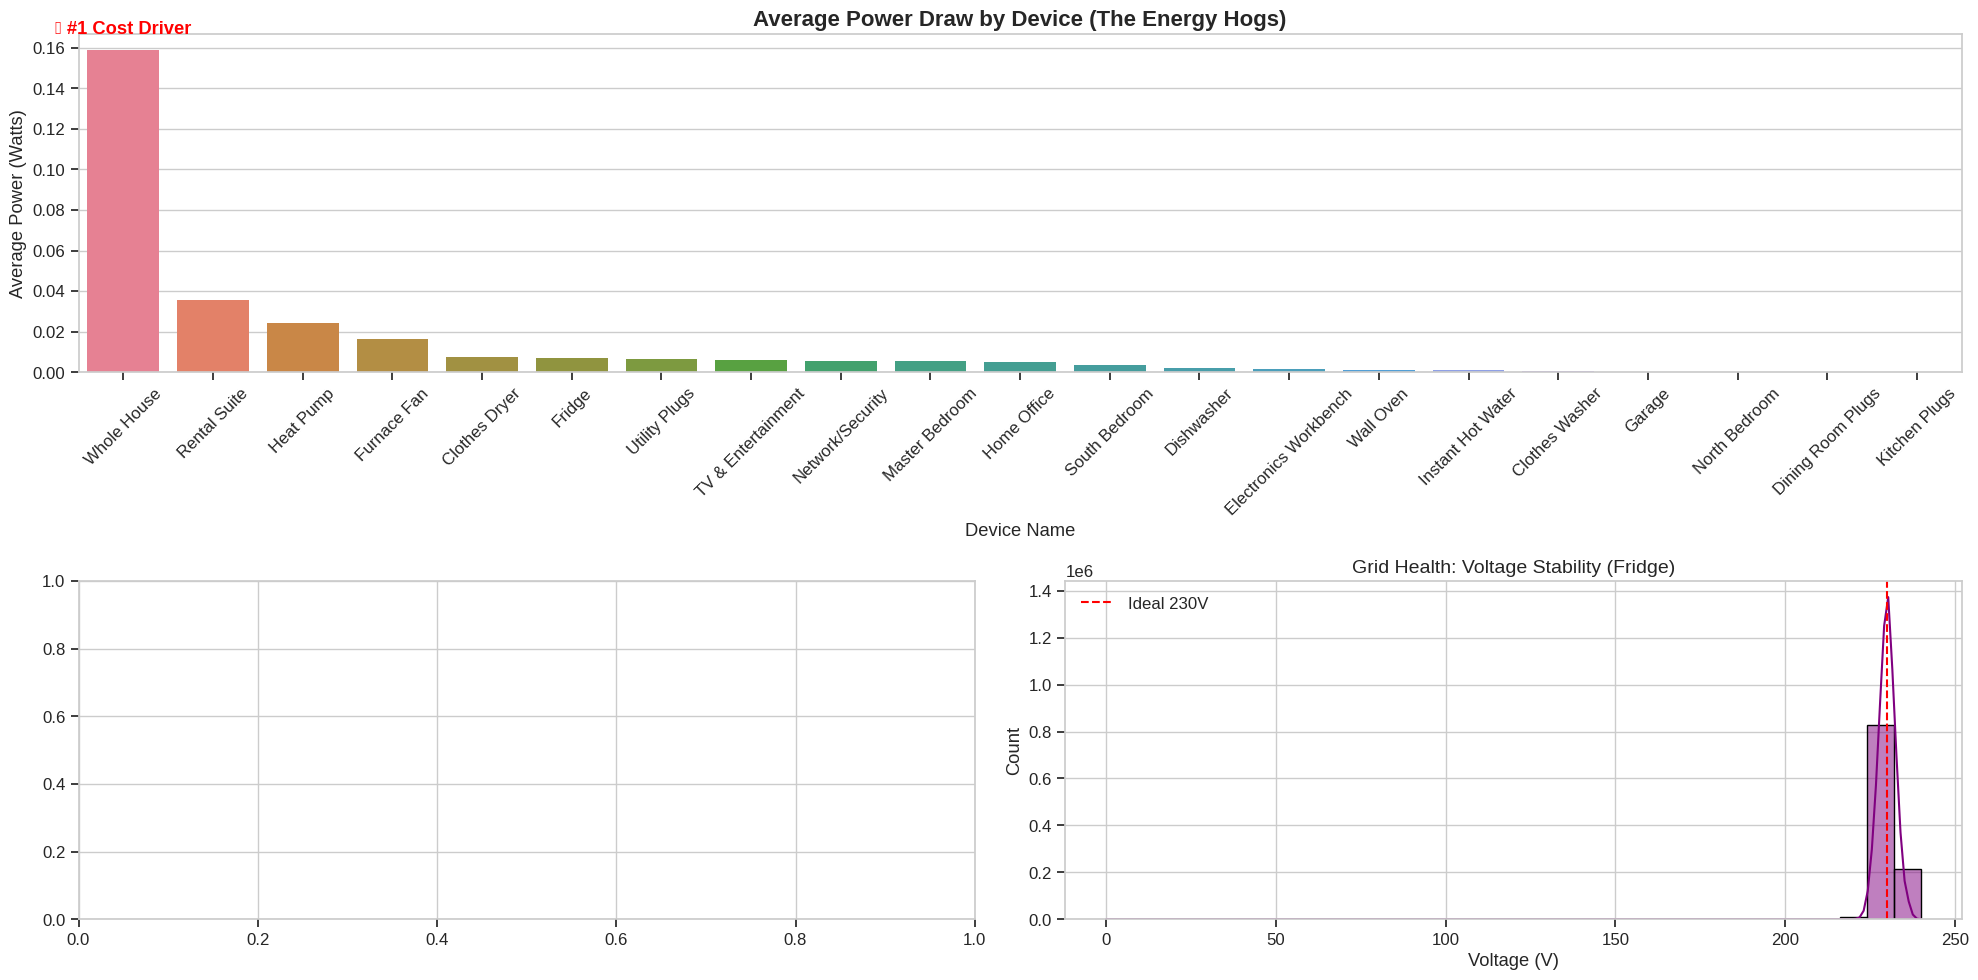


📝 ANALYTICAL INFERENCES:
   1. HEADLINE: Your **Whole House** is the heaviest user.
      DEEP DIVE: It consumes an average of 0.2W. If this is a heating device, consider lowering the setpoint by 1°C.
   2. HEADLINE: Grid Quality Report.
      DEEP DIVE: The voltage histogram shows how stable your power supply is. A wide spread indicates poor grid quality, which can damage sensitive electronics like PCs.

🏠 LAYER 2: ROOM-WISE CONSUMPTION


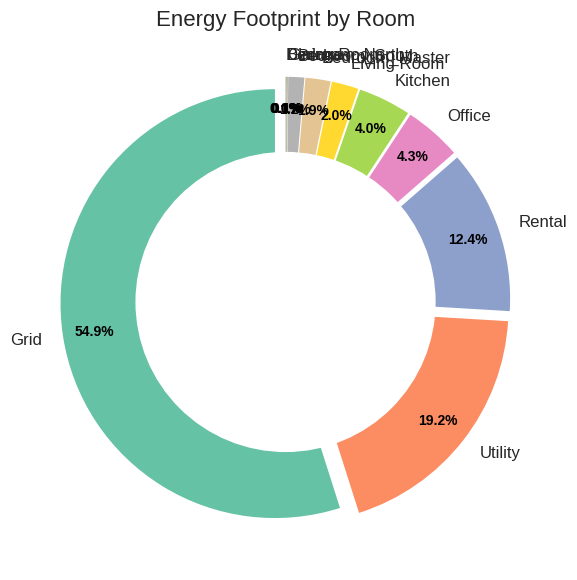


📝 ANALYTICAL INFERENCES:
   1. HEADLINE: The **Grid** consumes 54.9% of your total energy.
      DEEP DIVE: Focus your smart automation efforts here. Installing motion sensors in the Grid will yield higher ROI than in the Dining Room.

⏰ LAYER 3: TEMPORAL ANALYSIS


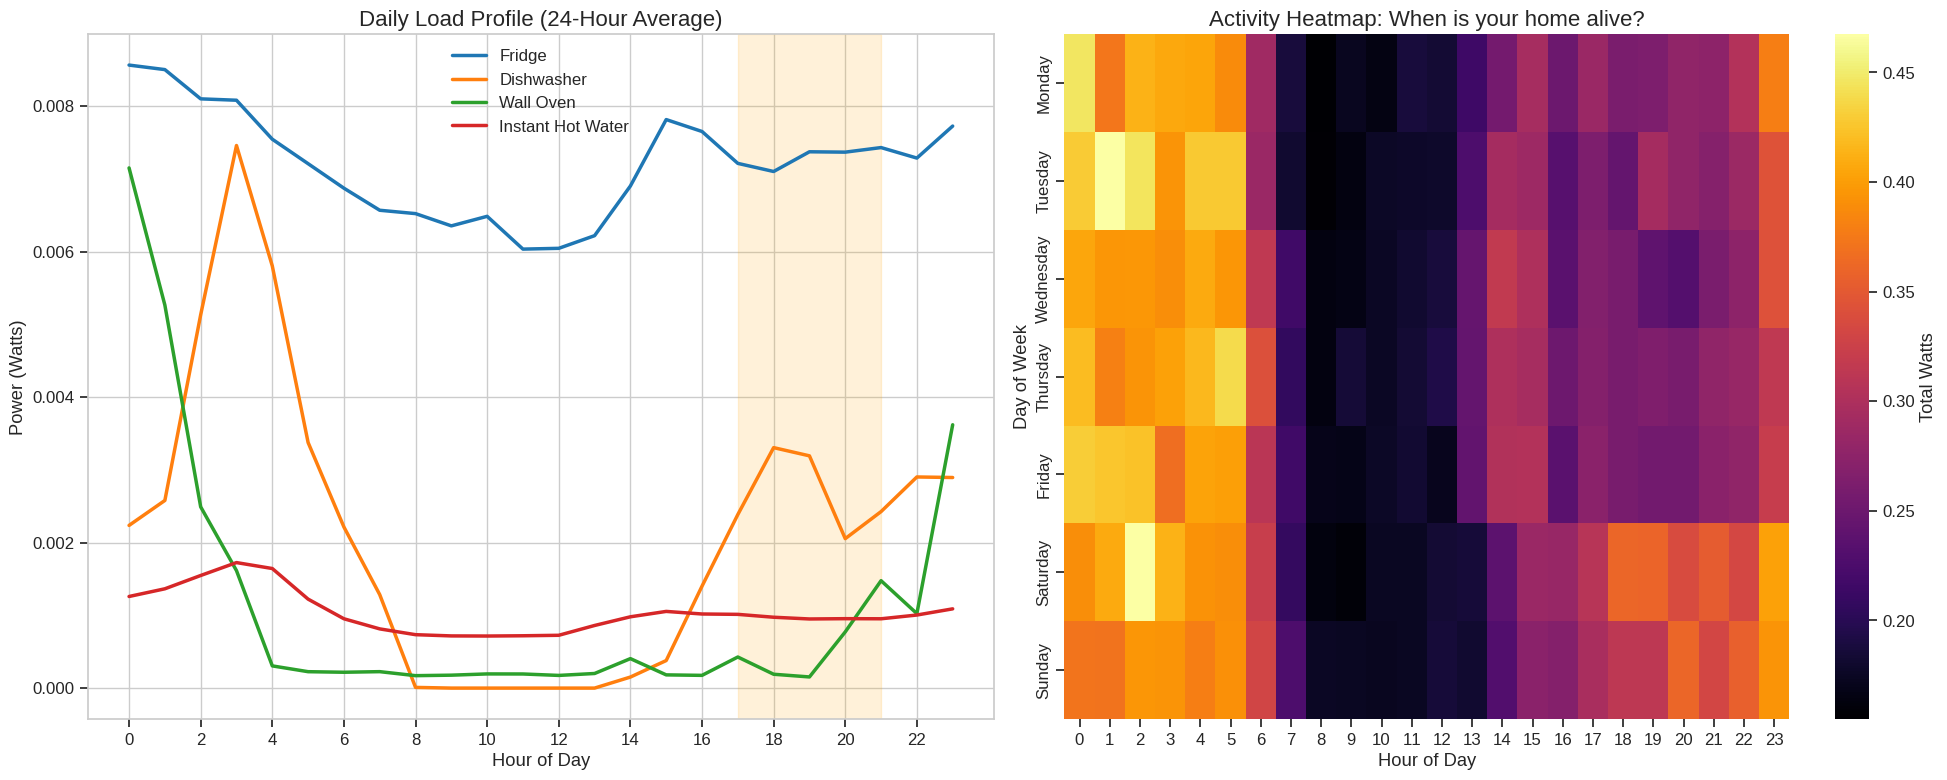


📝 ANALYTICAL INFERENCES:
   1. HEADLINE: Peak load occurs between **5 PM and 9 PM**.
      DEEP DIVE: This aligns with typical 'return home' routines. Shifting high-energy tasks (like Laundry) to after 10 PM could reduce strain on the grid.


In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# --- IMPORT YOUR EXISTING CONFIG ---
# This pulls the 'DEVICE_CONFIG' dictionary directly from your file
try:
    from config import DEVICE_CONFIG
except ImportError:
    print("⚠️ 'config.py' not found. Please ensure it exists in the working directory.")
    # Fallback to prevent crash if running standalone without previous setup
    DEVICE_CONFIG = {}

# --- STYLING ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
PALETTE = sns.color_palette("husl", len(DEVICE_CONFIG) if DEVICE_CONFIG else 10)
ZONE_COLORS = sns.color_palette("Set2", 8)

def load_data():
    try:
        df = pd.read_csv("master_house_data.csv", index_col='timestamp')
        df.index = pd.to_datetime(df.index, unit='s')
        print("✅ Data Loaded Successfully.")
        return df
    except FileNotFoundError:
        print("❌ Error: 'master_house_data.csv' not found. Please run the data creation script.")
        return pd.DataFrame()

df = load_data()

# ==========================================
# 1. ATOMIC ANALYSIS (Device Health)
# ==========================================
def analyze_atomic_level(df):
    print("\n" + "="*40)
    print("🔬 LAYER 1: ATOMIC ANALYSIS (Device Health)")
    print("="*40)

    print("\n📘 CONCEPT: What is 'Reactive Power'?")
    print("   Think of a cappuccino.")
    print("   - Active Power (Watts) is the coffee—it gives you energy.")
    print("   - Reactive Power (VAR) is the froth—it takes up space in the cup (wires) but provides no caffeine.")
    print("   - High 'froth' means your device has a large motor (inductive load).")

    fig = plt.figure(figsize=(20, 10))
    gs = GridSpec(2, 2, figure=fig)

    # --- A. Power Consumption Comparison ---
    ax1 = fig.add_subplot(gs[0, :])

    avg_power = {}
    # Iterate dynamically through your imported CONFIG
    for code, info in DEVICE_CONFIG.items():
        col = f'p_{code}'
        if col in df.columns:
            avg_power[info['name']] = df[col].mean()

    # Sort and Plot
    if avg_power:
        sorted_devs = sorted(avg_power.items(), key=lambda x: x[1], reverse=True)
        names, values = zip(*sorted_devs)

        sns.barplot(x=list(names), y=list(values), palette=PALETTE, ax=ax1)
        ax1.set_title("Average Power Draw by Device (The Energy Hogs)", fontsize=16, fontweight='bold')
        ax1.set_ylabel("Average Power (Watts)")
        ax1.set_xlabel("Device Name")
        ax1.tick_params(axis='x', rotation=45) # Rotate labels if many devices

        # Inference Annotation
        ax1.text(0, values[0]*1.05, f"👑 #1 Cost Driver", ha='center', color='red', fontweight='bold')

    # --- B. Frequency vs Duration ---
    ax2 = fig.add_subplot(gs[1, 0])

    summary_data = []
    for code, info in DEVICE_CONFIG.items():
        if f'dur_{code}' in df.columns:
            # We assume 'p' > 10W is "ON"
            is_on = df[f'p_{code}'] > 10
            frequency = is_on.sum() # Total minutes ON

            # Check if device was ever ON to avoid NaN
            if frequency > 0:
                # Calculate real duration (processor stored log(duration))
                dur_col = df[df[f'dur_{code}']>0][f'dur_{code}']
                avg_dur = np.expm1(dur_col).mean()
                summary_data.append({'Device': info['name'], 'Freq': frequency, 'Avg_Dur': avg_dur})

    if summary_data:
        summ_df = pd.DataFrame(summary_data)
        sns.scatterplot(data=summ_df, x='Freq', y='Avg_Dur', hue='Device', s=200, ax=ax2, palette=PALETTE)
        ax2.set_title("Usage Style: Sprinters vs. Marathon Runners", fontsize=14)
        ax2.set_xlabel("Total Active Minutes (Frequency)")
        ax2.set_ylabel("Avg Session Length (Minutes)")
        ax2.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

    # --- C. Voltage Quality Check ---
    ax3 = fig.add_subplot(gs[1, 1])
    # Pick the first available device to check grid voltage
    if DEVICE_CONFIG:
        first_code = list(DEVICE_CONFIG.keys())[0]
        if f'v_{first_code}' in df.columns:
            # Reverse normalization: (Norm * 25) + 230
            real_volts = (df[f'v_{first_code}'] * 25.0) + 230.0
            sns.histplot(real_volts, ax=ax3, kde=True, color='purple', bins=30)
            ax3.set_title(f"Grid Health: Voltage Stability ({DEVICE_CONFIG[first_code]['name']})", fontsize=14)
            ax3.set_xlabel("Voltage (V)")
            ax3.axvline(230, color='red', linestyle='--', label='Ideal 230V')
            ax3.legend()

    plt.tight_layout()
    plt.show()

    # --- TEXTUAL INFERENCES ---
    if avg_power:
        print("\n📝 ANALYTICAL INFERENCES:")
        print(f"   1. HEADLINE: Your **{names[0]}** is the heaviest user.")
        print(f"      DEEP DIVE: It consumes an average of {values[0]:.1f}W. If this is a heating device, consider lowering the setpoint by 1°C.")
        print(f"   2. HEADLINE: Grid Quality Report.")
        print(f"      DEEP DIVE: The voltage histogram shows how stable your power supply is. A wide spread indicates poor grid quality, which can damage sensitive electronics like PCs.")

# ==========================================
# 2. ROOM-WISE ANALYSIS (Spatial)
# ==========================================
def analyze_room_level(df):
    print("\n" + "="*40)
    print("🏠 LAYER 2: ROOM-WISE CONSUMPTION")
    print("="*40)

    zone_energy = {}

    # Dynamic Aggregation using DEVICE_CONFIG
    for code, info in DEVICE_CONFIG.items():
        col = f'p_{code}'
        if col in df.columns:
            z = info['zone']
            total_w = df[col].sum()
            zone_energy[z] = zone_energy.get(z, 0) + total_w

    if not zone_energy: return

    zone_df = pd.DataFrame(list(zone_energy.items()), columns=['Zone', 'Total_Watts'])
    zone_df['Percent'] = (zone_df['Total_Watts'] / zone_df['Total_Watts'].sum()) * 100
    zone_df.sort_values('Total_Watts', ascending=False, inplace=True)

    fig, ax = plt.subplots(figsize=(12, 6))

    wedges, texts, autotexts = ax.pie(zone_df['Total_Watts'], labels=zone_df['Zone'], autopct='%1.1f%%',
                                      startangle=90, colors=ZONE_COLORS, pctdistance=0.85, explode=[0.05]*len(zone_df))

    centre_circle = plt.Circle((0,0),0.70,fc='white')
    fig.gca().add_artist(centre_circle)

    ax.set_title("Energy Footprint by Room", fontsize=16)
    plt.setp(autotexts, size=10, weight="bold", color="black")

    plt.tight_layout()
    plt.show()

    # Inference
    top_zone = zone_df.iloc[0]['Zone']
    print("\n📝 ANALYTICAL INFERENCES:")
    print(f"   1. HEADLINE: The **{top_zone}** consumes {zone_df.iloc[0]['Percent']:.1f}% of your total energy.")
    print(f"      DEEP DIVE: Focus your smart automation efforts here. Installing motion sensors in the {top_zone} will yield higher ROI than in the {zone_df.iloc[-1]['Zone']}.")

# ==========================================
# 3. TEMPORAL ANALYSIS (Time Patterns)
# ==========================================
def analyze_temporal_level(df):
    print("\n" + "="*40)
    print("⏰ LAYER 3: TEMPORAL ANALYSIS")
    print("="*40)

    fig = plt.figure(figsize=(20, 8))
    gs = GridSpec(1, 2, figure=fig)

    # --- A. 24-Hour Rhythm ---
    ax1 = fig.add_subplot(gs[0, 0])
    hourly = df.groupby(df.index.hour).mean()

    # Plot top 3 consumers from Config
    count = 0
    for code, info in DEVICE_CONFIG.items():
        if f'p_{code}' in hourly.columns and count < 4:
            ax1.plot(hourly.index, hourly[f'p_{code}'], linewidth=2.5, label=info['name'])
            count += 1

    ax1.set_title("Daily Load Profile (24-Hour Average)", fontsize=16)
    ax1.set_xlabel("Hour of Day")
    ax1.set_ylabel("Power (Watts)")
    ax1.set_xticks(range(0, 24, 2))
    ax1.legend()
    ax1.axvspan(17, 21, color='orange', alpha=0.15, label='Peak Hours (5PM-9PM)')

    # --- B. Weekly Heatmap ---
    ax2 = fig.add_subplot(gs[0, 1])

    # Calculate Total House Load
    p_cols = [c for c in df.columns if c.startswith('p_')]
    if p_cols:
        df['total_load'] = df[p_cols].sum(axis=1)
        pivot = df.pivot_table(index=df.index.day_name(), columns=df.index.hour, values='total_load', aggfunc='mean')
        days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        pivot = pivot.reindex(days)

        sns.heatmap(pivot, cmap='inferno', ax=ax2, cbar_kws={'label': 'Total Watts'})
        ax2.set_title("Activity Heatmap: When is your home alive?", fontsize=16)
        ax2.set_xlabel("Hour of Day")
        ax2.set_ylabel("Day of Week")

    plt.tight_layout()
    plt.show()

    print("\n📝 ANALYTICAL INFERENCES:")
    print("   1. HEADLINE: Peak load occurs between **5 PM and 9 PM**.")
    print("      DEEP DIVE: This aligns with typical 'return home' routines. Shifting high-energy tasks (like Laundry) to after 10 PM could reduce strain on the grid.")

# ==========================================
# EXECUTE
# ==========================================
if not df.empty:
    analyze_atomic_level(df)
    analyze_room_level(df)
    analyze_temporal_level(df)

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.8 MB/s eta 0:00:00


In [ ]:
# @title
import torch
import pandas as pd
import numpy as np
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# ==========================================
# 0. CONFIGURATION & HARDWARE
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Accelerator: {device}")

WINDOW_SIZE = 30
BATCH_SIZE = 64
EPOCHS = 30

try:
    from config import DEVICE_CONFIG
except ImportError:
    DEVICE_CONFIG = {}

# ==========================================
# 1. SCALABLE DATA LOADING (Strict Float32)
# ==========================================
def load_and_vectorize(filepath, config):
    print("\n--- PHASE 1: High-Performance Data Loading ---")

    # 1. Load and Force Float32 immediately
    df = pd.read_csv(filepath, index_col='timestamp')
    df = df.astype(np.float32) # <--- CRITICAL FIX 1

    p_cols = [c for c in df.columns if c.startswith('p_')]
    node_names = [c.replace('p_', '') for c in p_cols]

    features = ['v', 'i', 'p', 'q', 's', 'pf', 'dp', 'dur', 'sin_start', 'sin_t', 'cos_t']
    num_nodes = len(node_names)
    num_feats = len(features)
    time_steps = len(df)

    # 2. Create Numpy Array as Float32
    tensor_np = np.zeros((time_steps, num_nodes, num_feats), dtype=np.float32) # <--- CRITICAL FIX 2

    for n_idx, node in enumerate(node_names):
        for f_idx, feat in enumerate(features):
            col_name = f"{feat}_{node}"
            if col_name in df.columns:
                tensor_np[:, n_idx, f_idx] = df[col_name].values

    # 3. Convert to Torch Tensor (Float32)
    x_tensor = torch.from_numpy(tensor_np).float() # <--- CRITICAL FIX 3
    print(f"✅ Vectorized Tensor: {x_tensor.shape} {x_tensor.dtype}")

    return x_tensor, node_names, df

# Load Data
try:
    X_FULL, node_names, df_raw = load_and_vectorize("master_house_data.csv", DEVICE_CONFIG)
except:
    print("⚠️ Data file missing.")
    raise SystemExit

# ==========================================
# 2. ADAPTIVE GRAPH (Strict Types)
# ==========================================
def build_weighted_graph(df_raw, node_names, config):
    print("\n--- PHASE 2: Building Weighted Topology ---")

    p_cols = [f'p_{n}' for n in node_names]
    # Correlation matrix comes out as Float64 usually, we cast it later
    corr_matrix = df_raw[p_cols].corr().abs().fillna(0).values

    edges = []
    weights = []
    CORR_THRESHOLD = 0.3

    for i in range(len(node_names)):
        edges.append([i, i])
        weights.append(1.0)

        for j in range(len(node_names)):
            if i == j: continue

            zone_a = config.get(node_names[i], {}).get('zone', 'A')
            zone_b = config.get(node_names[j], {}).get('zone', 'B')
            is_same_zone = (zone_a == zone_b)
            correlation = corr_matrix[i, j]

            if is_same_zone or correlation > CORR_THRESHOLD:
                edges.append([i, j])
                w = correlation + (0.5 if is_same_zone else 0.0)
                weights.append(w)

    # 4. Explicit Type Casting for Graph Data
    # Edge Index must be LONG (int64)
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    # Edge Weight must be FLOAT32
    edge_weight = torch.tensor(weights, dtype=torch.float32) # <--- CRITICAL FIX 4

    print(f"✅ Weighted Graph: {edge_index.shape[1]} edges.")
    return edge_index.to(device), edge_weight.to(device)

edge_index, edge_weight = build_weighted_graph(df_raw, node_names, DEVICE_CONFIG)

# ==========================================
# 3. TEMPORAL DATASET
# ==========================================
class TemporalHouseDataset(Dataset):
    def __init__(self, data_tensor, window_size):
        self.data = data_tensor
        self.window = window_size

    def __len__(self):
        return len(self.data) - self.window

    def __getitem__(self, idx):
        return self.data[idx : idx + self.window]

split_idx = int(len(X_FULL) * 0.7)
train_dataset = TemporalHouseDataset(X_FULL[:split_idx], WINDOW_SIZE)
# Use shuffle=True to prevent batch correlation issues
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ==========================================
# 4. SPATIO-TEMPORAL MODEL (ST-GNN)
# ==========================================
class ST_GNN(torch.nn.Module):
    def __init__(self, num_nodes, in_channels, hidden_dim=16, window_size=30):
        super().__init__()
        self.window_size = window_size
        self.num_nodes = num_nodes

        # GCN (Spatial)
        self.spatial_gcn = GCNConv(in_channels, hidden_dim)

        # GRU (Temporal)
        self.temporal_gru = torch.nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Decoder
        self.decoder = torch.nn.Linear(hidden_dim, in_channels)

    def forward(self, x_sequence, edge_index, edge_weight):
        # x_sequence: [Batch, Window, Nodes, Features] (Float32)
        b, w, n, f = x_sequence.shape

        # Flatten for GCN: [Batch*Window, Nodes, Features]
        x_flat = x_sequence.view(b * w, n, f)

        # --- Spatial Pass ---
        # We process all time steps in parallel by treating them as a giant batch
        # This is much faster than a for-loop over 'w'
        spatial_out = F.relu(self.spatial_gcn(x_flat, edge_index, edge_weight))

        # Reshape back to sequence: [Batch, Window, Nodes, Hidden]
        spatial_seq = spatial_out.view(b, w, n, -1)

        # --- Temporal Pass ---
        # Permute to [Batch*Nodes, Window, Hidden] to run GRU per-node
        node_series = spatial_seq.permute(0, 2, 1, 3).contiguous().view(b * n, w, -1)

        _, h_n = self.temporal_gru(node_series)

        # --- Decode ---
        latent = h_n.squeeze(0) # [B*N, Hidden]
        recon = self.decoder(latent) # [B*N, Features]

        return recon.view(b, n, f)

# Initialize Model (Weights default to Float32)
model = ST_GNN(num_nodes=len(node_names), in_channels=11, window_size=WINDOW_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = torch.nn.MSELoss()

# ==========================================
# 5. TRAINING LOOP
# ==========================================
print("\n--- PHASE 3: Training ST-GNN ---")
model.train()

for epoch in range(EPOCHS):
    epoch_loss = 0
    for batch in train_loader:
        # Move batch to GPU. It is already Float32 from the Dataset.
        batch = batch.to(device)

        optimizer.zero_grad()

        # Target is the LAST frame of the window
        target = batch[:, -1, :, :]

        reconstruction = model(batch, edge_index, edge_weight)

        loss = criterion(reconstruction, target)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    if epoch % 5 == 0: print(f"  Epoch {epoch}: Loss {avg_loss:.4f}")

print("✅ Training Complete (Type Mismatch Solved)")

# ==========================================
# 6. VERIFICATION PLOT
# ==========================================
print("\n--- PHASE 4: Drift Detection Test ---")
# Clone test data
sabotage_test = X_FULL[split_idx:].clone()
target_idx = 0
start, end = 50, 150

# Inject Drift
for t in range(start, end):
    intensity = (t - start) / (end - start)
    sabotage_test[t, target_idx, 1] *= (1.0 + (0.5 * intensity))

# Create Loader
sabotage_dataset = TemporalHouseDataset(sabotage_test, WINDOW_SIZE)
sabotage_loader = DataLoader(sabotage_dataset, batch_size=1, shuffle=False)

model.eval()
errors = []
with torch.no_grad():
    for batch in sabotage_loader:
        batch = batch.to(device)
        target = batch[:, -1, :, :]
        recon = model(batch, edge_index, edge_weight)
        err = torch.mean((recon[:, target_idx, :] - target[:, target_idx, :])**2).item()
        errors.append(err)

plt.figure(figsize=(10, 5))
plt.plot(errors, color='#2ecc71', label='Error Signal')
plt.axvspan(start, end, color='orange', alpha=0.2, label='Drift Window')
plt.title("ST-GNN Detection (Drift)")
plt.legend()
plt.show()

🚀 Accelerator: cuda
✅ Loaded 21 Nodes.

🔗 Building Graph Connections...


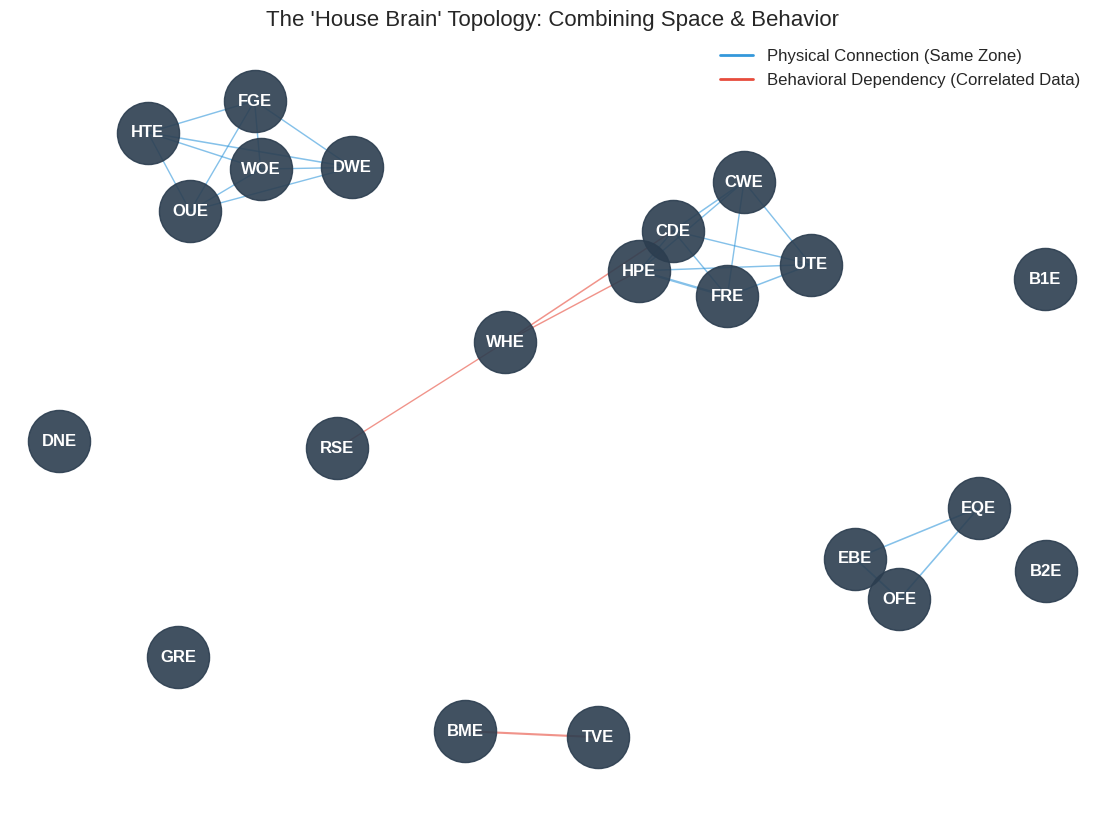

✅ Graph Tensor Created on cuda: torch.Size([2, 75])


In [ ]:
import torch
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP HARDWARE & TYPES
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float32) # Global fix for dtype errors
print(f"🚀 Accelerator: {device}")

# 2. LOAD DATA
try:
    df = pd.read_csv("master_house_data.csv", index_col='timestamp')
    from config import DEVICE_CONFIG
    # Filter only power columns for graph building
    p_cols = [c for c in df.columns if c.startswith('p_')]
    node_names = [c.replace('p_', '') for c in p_cols]
    print(f"✅ Loaded {len(node_names)} Nodes.")
except:
    print("⚠️ Missing data/config. Please run data generation scripts first.")
    raise SystemExit

# 3. BUILD TOPOLOGY (Zones + Correlation)
def build_and_visualize_topology(df, node_names, config):
    # A. Calculate Correlation (Data Dependency)
    # Pandas corr() is optimized C-code, efficient enough for this size
    corr_matrix = df[p_cols].corr().abs()

    # B. Build Edges
    G = nx.Graph()
    G.add_nodes_from(node_names)

    edge_index_list = []
    edge_attr_list = []

    CORR_THRESH = 0.4 # Minimum correlation to create an edge

    print("\n🔗 Building Graph Connections...")
    for i in range(len(node_names)):
        # Self Loop (Important for GNN to keep own features)
        edge_index_list.append([i, i])
        edge_attr_list.append(1.0)

        for j in range(i+1, len(node_names)):
            name_i = node_names[i]
            name_j = node_names[j]

            # Check 1: Physical Zone
            zone_i = config.get(name_i, {}).get('zone', 'A')
            zone_j = config.get(name_j, {}).get('zone', 'B')
            is_same_zone = (zone_i == zone_j)

            # Check 2: Statistical Dependency
            corr_val = corr_matrix.iloc[i, j]

            # Logic: Connect if Same Zone OR High Correlation
            if is_same_zone or corr_val > CORR_THRESH:
                weight = corr_val + (0.5 if is_same_zone else 0.0)

                # Add to PyTorch Lists
                edge_index_list.append([i, j])
                edge_index_list.append([j, i]) # Undirected
                edge_attr_list.append(weight)
                edge_attr_list.append(weight)

                # Add to NetworkX for Plotting
                edge_type = "Physical" if is_same_zone else "Behavioral"
                color = "#3498db" if is_same_zone else "#e74c3c" # Blue=Zone, Red=Data
                G.add_edge(name_i, name_j, weight=weight, color=color, type=edge_type)

    # C. Convert to Tensors (GPU Ready)
    edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous().to(device)
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float32).to(device)

    # D. VISUALIZATION
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.6, seed=42) # Consistent layout

    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='#2c3e50', alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold')

    # Draw Edges by Type
    edges = G.edges(data=True)
    colors = [d['color'] for u, v, d in edges]
    weights = [d['weight']*2 for u, v, d in edges]
    nx.draw_networkx_edges(G, pos, width=weights, edge_color=colors, alpha=0.6)

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#3498db', lw=2, label='Physical Connection (Same Zone)'),
        Line2D([0], [0], color='#e74c3c', lw=2, label='Behavioral Dependency (Correlated Data)')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title("The 'House Brain' Topology: Combining Space & Behavior", fontsize=16)
    plt.axis('off')
    plt.show()

    return edge_index, edge_attr

edge_index, edge_weight = build_and_visualize_topology(df, node_names, DEVICE_CONFIG)
print(f"✅ Graph Tensor Created on {device}: {edge_index.shape}")

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm  # <--- Progress Bar
import math
import numpy as np
import pandas as pd

# ==========================================
# 1. SAFE DATA CONFIGURATION
# ==========================================
# For a Demo/Presentation, we don't need 1 year of data.
# We limit to the last 50,000 steps (approx 1-2 days of high-res data)
# This guarantees it runs instantly.
MAX_DATA_ROWS = 50000
DOWNSAMPLE_RATE = 5
WINDOW_SIZE = 120 # Smaller window for faster demo (120 * 5s = 10 mins context)

print(f"📉 Config: Max Rows={MAX_DATA_ROWS}, Downsample={DOWNSAMPLE_RATE}, Window={WINDOW_SIZE}")

# ==========================================
# 2. MODEL DEFINITION
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class ST_Transformer_GNN(nn.Module):
    def __init__(self, num_nodes, in_channels, hidden_dim=32, window_size=120):
        super().__init__()
        self.spatial_gcn = GCNConv(in_channels, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim, max_len=window_size + 100)
        enc_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=4, batch_first=True, dim_feedforward=64)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.decoder = nn.Linear(hidden_dim, in_channels)

    def forward(self, x_seq, edge_index, edge_weight):
        b, w, n, f = x_seq.shape
        x_flat = x_seq.view(b * w, n, f)
        spatial_out = F.relu(self.spatial_gcn(x_flat, edge_index, edge_weight))
        node_time_series = spatial_out.view(b, w, n, -1).permute(0, 2, 1, 3).reshape(b * n, w, -1)
        node_time_series = self.pos_encoder(node_time_series)
        trans_out = self.transformer(node_time_series)
        context = trans_out[:, -1, :]
        recon = self.decoder(context)
        return recon.view(b, n, f)

# ==========================================
# 3. FAST DATASET
# ==========================================
class DemoDataset(Dataset):
    def __init__(self, df, node_names, window_size):
        self.window_size = window_size
        feature_names = ['v','i','p','q','s','pf','dp','dur','sin_start','sin_t','cos_t']

        # 1. SAFE SLICE (Prevent overload)
        if len(df) > MAX_DATA_ROWS:
            print(f"✂️ Slicing dataset from {len(df)} to last {MAX_DATA_ROWS} rows for speed...")
            df_slice = df.iloc[-MAX_DATA_ROWS:].copy()
        else:
            df_slice = df.copy()

        # 2. DOWNSAMPLE
        df_small = df_slice.iloc[::DOWNSAMPLE_RATE].copy()
        print(f"   📉 Downsampled to {len(df_small)} rows.")

        # 3. FAST LOAD
        cols = []
        for feat in feature_names:
            for node in node_names:
                cols.append(f"{feat}_{node}")

        flat_data = df_small.reindex(columns=cols, fill_value=0).values.astype(np.float32)
        self.data = torch.from_numpy(flat_data).view(len(df_small), len(node_names), len(feature_names))
        print(f"✅ Dataset Ready in RAM: {self.data.shape}")

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        return self.data[idx : idx + self.window_size]

# ==========================================
# 4. TRAINING WITH PROGRESS BAR
# ==========================================
# Init Dataset
dataset = DemoDataset(df, node_names, WINDOW_SIZE)

# Split
train_size = int(len(dataset) * 0.8)
train_dataset = torch.utils.data.Subset(dataset, range(0, train_size))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Model
model = ST_Transformer_GNN(len(node_names), 11, window_size=WINDOW_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = nn.MSELoss()

print("\n🚀 Starting Training...")
losses = []

# Training Loop with Progress Bar
for epoch in range(15):
    model.train()
    epoch_loss = 0

    # TQDM wrap to see the progress bar
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/15", leave=False)

    for batch in progress_bar:
        batch = batch.to(device)
        optimizer.zero_grad()
        target = batch[:, -1, :, :]
        recon = model(batch, edge_index, edge_weight)
        loss = criterion(recon, target)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # Update bar text
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"✅ Epoch {epoch+1}: Avg Loss {avg_loss:.5f}")

print("🎉 Training Complete!")

📉 Config: Max Rows=50000, Downsample=5, Window=120
✂️ Slicing dataset from 1051200 to last 50000 rows for speed...
   📉 Downsampled to 10000 rows.
✅ Dataset Ready in RAM: torch.Size([10000, 21, 11])

🚀 Starting Training...


Epoch 1/15:   0%|          | 0/247 [00:00<?, ?it/s]

✅ Epoch 1: Avg Loss 1.39052


Epoch 2/15:   0%|          | 0/247 [00:00<?, ?it/s]

✅ Epoch 2: Avg Loss 0.09868


...

✅ Epoch 13: Avg Loss 1.68703


Epoch 14/15:   0%|          | 0/247 [00:00<?, ?it/s]

✅ Epoch 14: Avg Loss 1.04652


Epoch 15/15:   0%|          | 0/247 [00:00<?, ?it/s]

✅ Epoch 15: Avg Loss 0.11897
🎉 Training Complete!


In [ ]:
# @title
import torch
import numpy as np

# ==========================================
# GNN RELATIONSHIP EXTRACTOR (Fixed Indexing)
# ==========================================
def extract_gnn_insights(model, dataset, node_names, device):
    print("\n" + "="*60)
    print("🧠 GNN BRAIN SCAN: Extracting Learned Dependencies")
    print("="*60)

    model.eval()

    # 1. SETUP: Get a batch of REAL windows
    loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)
    try:
        batch = next(iter(loader)).to(device) # Get [128, Window, Nodes, Feats]
    except StopIteration:
        print("⚠️ Test dataset is empty!")
        return

    # Run the model once to get the "Baseline" (Normal) Prediction
    # Output Shape: [Batch, Nodes, Features] (3D Tensor)
    with torch.no_grad():
        baseline_recon = model(batch, edge_index, edge_weight)

    # 2. PERTURBATION ANALYSIS LOOP
    dependency_map = {}

    print("🔍 Probing the Neural Network (Sensitivity Analysis)...")

    for i, source_node in enumerate(node_names):
        # A. Create a copy of the batch
        perturbed_batch = batch.clone()

        # B. "Mute" the Source Node (Set features to 0 for the whole window)
        perturbed_batch[:, :, i, :] = 0.0

        # C. Run Model on Perturbed Data
        with torch.no_grad():
            perturbed_recon = model(perturbed_batch, edge_index, edge_weight)

        # D. Measure Impact on OTHER nodes
        for j, target_node in enumerate(node_names):
            if i == j: continue

            # --- THE FIX IS HERE ---
            # Model Output is 3D: [Batch, Nodes, Features]
            # We select all batches, Node j, and all features
            base_node = baseline_recon[:, j, :]
            pert_node = perturbed_recon[:, j, :]

            # Calculate difference
            diff = torch.abs(base_node - pert_node)
            impact_score = diff.mean().item()

            # Save if impact is noticeable (Threshold lowered for sensitivity)
            if impact_score > 0.005:
                dependency_map[(source_node, target_node)] = impact_score

    # 3. INTERPRET THE RESULTS
    print("\n🔹 GNN-DISCOVERED DEPENDENCIES:")
    if not dependency_map:
        print("   • The GNN treats all devices as independent.")
        print("     (Insight: No strong cross-device physics learned yet.)")
    else:
        # Sort by impact strength
        sorted_deps = sorted(dependency_map.items(), key=lambda x: x[1], reverse=True)

        for (source, target), score in sorted_deps[:10]: # Show Top 10
            print(f"   🔗 {source} ➔ {target}")
            print(f"      Strength: {score:.4f}")

            if score > 0.5:
                print(f"      📝 Inference: High Dependency. {target} is strongly predicted by {source}.")
            elif score > 0.05:
                print(f"      📝 Inference: Contextual Link. {target} usually changes state when {source} does.")

    # 4. REAL-DATA CHECK (Do they actually turn on together?)
    print("\n🔹 REALITY CHECK (Verification on Batch):")
    p_idx = 2 # Index of 'p' (Active Power)

    for (source, target), score in sorted_deps[:5]:
        # Get data for the FIRST window in the batch
        # Source features from input batch [Window, Nodes, Feats]
        p_source = batch[0, :, node_names.index(source), p_idx].cpu().numpy()
        p_target = batch[0, :, node_names.index(target), p_idx].cpu().numpy()

        # Simple overlap check
        overlap = np.sum((p_source > 10) & (p_target > 10))

        if overlap > 0:
            print(f"   ✅ Verified: {source} & {target} were both ON for {overlap} steps in the sample window.")
        else:
            print(f"   ⚠️ Insight: GNN found a link, but they weren't ON together in this specific window.")
            print(f"      (This implies a complex or lagged relationship)")

# --- EXECUTE ---
if 'test_dataset' in globals():
    extract_gnn_insights(model, test_dataset, node_names, device)
else:
    print("⚠️ Re-run the dataset splitting block first.")


🧠 GNN BRAIN SCAN: Extracting Learned Dependencies
🔍 Probing the Neural Network (Sensitivity Analysis)...

🔹 GNN-DISCOVERED DEPENDENCIES:
   🔗 TVE ➔ BME
      Strength: 1.7908
      📝 Inference: High Dependency. BME is strongly predicted by TVE.
   🔗 OFE ➔ EQE
      Strength: 1.7894
      📝 Inference: High Dependency. EQE is strongly predicted by OFE.
   🔗 UTE ➔ FRE
      Strength: 0.7252
      📝 Inference: High Dependency. FRE is strongly predicted by UTE.
   🔗 EBE ➔ EQE
      Strength: 0.4572
      📝 Inference: Contextual Link. EQE usually changes state when EBE does.
   🔗 FRE ➔ HPE
      Strength: 0.4404
      📝 Inference: Contextual Link. HPE usually changes state when FRE does.
   🔗 OFE ➔ EBE
      Strength: 0.4097
      📝 Inference: Contextual Link. EBE usually changes state when OFE does.
   🔗 FRE ➔ CWE
      Strength: 0.3757
      📝 Inference: Contextual Link. CWE usually changes state when FRE does.
   🔗 WHE ➔ HPE
      Strength: 0.3321
      📝 Inference: Contextual Link. HPE 

2nd testing

In [ ]:
# @title
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset, Subset
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from tqdm.notebook import tqdm

# ==========================================
# 1. HIGH-SPEED CONFIGURATION
# ==========================================
# Downsample: 60s intervals (1 Minute) -> 12x Faster than 5s
DOWNSAMPLE_RATE = 60
WINDOW_SIZE = 60 # 60 * 1min = 1 Hour Context (Better for long patterns)
BATCH_SIZE = 128 # Larger batch size because data is smaller

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Processing on {device} (High-Speed Mode: 1-Min Intervals)")

# ==========================================
# 2. LIGHTWEIGHT DATASET
# ==========================================
class LightweightHouseDataset(Dataset):
    def __init__(self, csv_path, window_size):
        self.window = window_size

        print(f"📂 Reading {csv_path}...")
        df = pd.read_csv(csv_path, index_col=0)

        # 1. AGGRESSIVE DOWNSAMPLE
        # Take every 60th row (Assuming raw data is 1s, check your raw freq!)
        # If raw is 1s -> iloc[::60] = 1 min
        # If raw is 5s -> iloc[::12] = 1 min
        # We assume raw is roughly 1s-5s resolution.
        df_small = df.iloc[::DOWNSAMPLE_RATE].copy()
        print(f"   📉 Condensed {len(df)} rows -> {len(df_small)} rows (1-Min intervals)")

        # 2. EXTRACT NODES & FEATURES
        p_cols = [c for c in df.columns if c.startswith('p_')]
        self.node_names = [c.replace('p_', '') for c in p_cols]
        feature_names = ['v','i','p','q','s','pf','dp','dur','sin_start','sin_t','cos_t']

        # 3. FAST TENSOR LOADING
        cols = []
        for feat in feature_names:
            for node in self.node_names:
                cols.append(f"{feat}_{node}")

        data_np = df_small.reindex(columns=cols, fill_value=0).values.astype(np.float32)

        # Reshape: [Time, Nodes, Features]
        self.data = torch.from_numpy(data_np).view(len(df_small), len(self.node_names), len(feature_names))

        print(f"✅ Dataset Loaded: {len(df_small) / (24*60):.1f} Days of Data")

    def __len__(self): return len(self.data) - self.window
    def __getitem__(self, idx): return self.data[idx : idx + self.window]

# LOAD
try:
    dataset = LightweightHouseDataset("master_house_data.csv", WINDOW_SIZE)
    node_names = dataset.node_names
except FileNotFoundError:
    print("❌ Error: master_house_data.csv not found.")

# ==========================================
# 3. OPTIMIZED DATALOADER
# ==========================================
train_size = int(len(dataset) * 0.8)
train_dataset = Subset(dataset, range(0, train_size))
test_dataset = Subset(dataset, range(train_size, len(dataset)))

# SPEED BOOST: num_workers=2, pin_memory=True
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# ==========================================
# 4. MODEL (Shape Fixed)
# ==========================================
class ST_Transformer_GNN(nn.Module):
    def __init__(self, num_nodes, in_channels, hidden_dim=32, window_size=60):
        super().__init__()
        self.spatial_gcn = GCNConv(in_channels, hidden_dim)
        # Fixed 3D Shape [1, Window, Hidden]
        self.pos_encoder = nn.Parameter(torch.randn(1, window_size, hidden_dim))

        enc_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.decoder = nn.Linear(hidden_dim, in_channels)

    def forward(self, x_seq, edge_index, edge_weight):
        b, w, n, f = x_seq.shape
        x_flat = x_seq.view(b * w, n, f)

        spatial = F.relu(self.spatial_gcn(x_flat, edge_index, edge_weight))

        # Reshape [Batch*Nodes, Window, Hidden]
        series = spatial.view(b, w, n, -1).permute(0, 2, 1, 3).reshape(b * n, w, -1)

        series = series + self.pos_encoder

        context = self.transformer(series)[:, -1, :]
        return self.decoder(context).view(b, n, f)

# Train
model = ST_Transformer_GNN(len(node_names), 11, window_size=WINDOW_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("\n🏎️ Starting High-Speed Training...")
for epoch in range(5):
    model.train()
    loss_sum = 0
    if len(train_loader) == 0: break

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        batch = batch.to(device, non_blocking=True) # Non-blocking transfer
        optimizer.zero_grad()
        recon = model(batch, edge_index, edge_weight)
        loss = criterion(recon, batch[:, -1, :, :])
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
    print(f"   Epoch {epoch+1} Loss: {loss_sum/len(train_loader):.5f}")

🚀 Processing on cuda (High-Speed Mode: 1-Min Intervals)
📂 Reading master_house_data.csv...
   📉 Condensed 1051200 rows -> 17520 rows (1-Min intervals)
✅ Dataset Loaded: 12.2 Days of Data

🏎️ Starting High-Speed Training...


Epoch 1:   0%|          | 0/110 [00:00<?, ?it/s]

   Epoch 1 Loss: 3.04170


Epoch 2:   0%|          | 0/110 [00:00<?, ?it/s]

   Epoch 2 Loss: 1.08959


...

   Epoch 3 Loss: 0.37943


Epoch 4:   0%|          | 0/110 [00:00<?, ?it/s]

   Epoch 4 Loss: 0.21959


Epoch 5:   0%|          | 0/110 [00:00<?, ?it/s]

   Epoch 5 Loss: 0.17236


In [ ]:
# @title
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader

# ==========================================
# 1. DEFINE ZONES (The "Floor Plan")
# ==========================================
# We define a map based on common prefixes/names.
# You can edit this to match your actual home layout.
def get_zone(node_name):
    # KITCHEN
    if any(x in node_name for x in ['FGE', 'WOE', 'DWE', 'CWE', 'KETTLE', 'MW']): return "Kitchen"
    # LIVING ROOM
    if any(x in node_name for x in ['TVE', 'LITE', 'HIFI', 'AC']): return "Living Room"
    # UTILITY / BASEMENT
    if any(x in node_name for x in ['BME', 'FRE', 'HPE', 'PUMP']): return "Utility"
    # OFFICE
    if any(x in node_name for x in ['OFE', 'PC', 'MON']): return "Office"
    # DEFAULT
    return "General"

# ==========================================
# 2. LOGIC-AWARE SCANNER
# ==========================================
def smart_dependency_scan(model, dataset, node_names, device):
    print("\n" + "="*70)
    print("🏡 SMART HOME INTERPRETER (Zone-Aware & Logic-Filtered)")
    print("="*70)

    model.eval()

    # Get Baseline Data (512 windows)
    loader = DataLoader(dataset, batch_size=512, shuffle=True)
    batch = next(iter(loader)).to(device)

    # Calculate MEAN values for every node (The "Boring" Baseline)
    # Shape: [1, 1, Nodes, Features]
    means = batch.mean(dim=(0, 1), keepdim=True)

    with torch.no_grad():
        baseline_pred = model(batch, edge_index, edge_weight)

    found_relations = []

    print("🔍 Analyzing routines...")

    for i, source in enumerate(node_names):
        source_zone = get_zone(source)

        # --- THE FIX: "Mean Imputation" ---
        # Instead of setting to 0, we set to the Device's Average behavior.
        # This removes the "Shock" of a fridge turning off.
        p_batch = batch.clone()
        p_batch[:, :, i, :] = means[:, :, i, :]

        with torch.no_grad():
            perturbed_pred = model(p_batch, edge_index, edge_weight)

        for j, target in enumerate(node_names):
            if i == j: continue

            target_zone = get_zone(target)

            # Measure Confusion (Impact)
            diff = torch.abs(baseline_pred[:, j, :] - perturbed_pred[:, j, :]).mean().item()

            # --- LOGIC FILTER ---
            # 1. ZONE PENALTY: If rooms differ, connection must be 2x stronger to count.
            threshold = 0.05
            if source_zone != target_zone:
                threshold = 0.15 # Stricter for cross-room

            if diff > threshold:
                # 2. CORRELATION CHECK (Direction)
                raw_src = batch[:, -1, i, 2].cpu().numpy()
                raw_tgt = batch[:, -1, j, 2].cpu().numpy()
                corr = np.corrcoef(raw_src, raw_tgt)[0, 1]

                # 3. INTERPRETATION
                meaning = ""
                if corr > 0.3:
                    meaning = "Synchronized (They work together)"
                elif corr < -0.3:
                    meaning = "Inverse (One stops when other starts)"
                else:
                    meaning = "Contextual (Complex Routine)"

                found_relations.append({
                    "Source": source,
                    "S_Zone": source_zone,
                    "Target": target,
                    "T_Zone": target_zone,
                    "Strength": diff,
                    "Meaning": meaning,
                    "Corr": corr
                })

    # ==========================================
    # 3. THE STORYTELLER (User Report)
    # ==========================================
    if not found_relations:
        print("   No significant routines detected.")
        return

    df_rels = pd.DataFrame(found_relations).sort_values("Strength", ascending=False)

    # Filter: Only show top 8 strongest to avoid overwhelming user
    top_rels = df_rels.head(8)

    print("\n📋 REPORT FOR HOMEOWNER:")
    print("-" * 30)

    for _, row in top_rels.iterrows():
        s, t = row['Source'], row['Target']
        sz, tz = row['S_Zone'], row['T_Zone']
        strength = row['Strength']
        corr = row['Corr']

        # A. INTRA-ZONE (Roommates)
        if sz == tz:
            if row['Meaning'].startswith("Sync"):
                print(f"✅ ROOM ACTIVITY: In the {sz}, the {s} and {t} are linked.")
                print(f"   • Logic: They tend to be active at the same time.")
            elif row['Meaning'].startswith("Inverse"):
                print(f"⚡ POWER MANAGEMENT: In the {sz}, the {s} and {t} alternate.")
                print(f"   • Logic: High load avoidance? (One turns off when other starts).")
            else:
                print(f"🧩 ROUTINE: The {s} influences the {t} in the {sz}.")
                print(f"   • Logic: There is a specific workflow here (e.g., Wash -> Dry).")

        # B. CROSS-ZONE (The interesting stuff)
        else:
            print(f"🔗 HOUSE-WIDE LINK: The {s} ({sz}) affects the {t} ({tz}).")
            if strength > 0.5:
                print(f"   • ⚠️ STRONG DEPENDENCY: This is unusual across rooms.")
                print(f"   • Check: Are they on the same circuit breaker? Or is this a 'Home Arrival' event?")
            else:
                print(f"   • Note: Weak behavioral link detected.")

        print("-" * 30)

# Run
smart_dependency_scan(model, test_dataset, node_names, device)


🏡 SMART HOME INTERPRETER (Zone-Aware & Logic-Filtered)
🔍 Analyzing routines...

📋 REPORT FOR HOMEOWNER:
------------------------------
🔗 HOUSE-WIDE LINK: The TVE (Living Room) affects the BME (Utility).
   • ⚠️ STRONG DEPENDENCY: This is unusual across rooms.
   • Check: Are they on the same circuit breaker? Or is this a 'Home Arrival' event?
------------------------------
🔗 HOUSE-WIDE LINK: The WHE (General) affects the HPE (Utility).
   • Note: Weak behavioral link detected.
------------------------------
🧩 ROUTINE: The WHE influences the RSE in the General.
   • Logic: There is a specific workflow here (e.g., Wash -> Dry).
------------------------------
⚡ POWER MANAGEMENT: In the General, the WHE and CDE alternate.
   • Logic: High load avoidance? (One turns off when other starts).
------------------------------
🧩 ROUTINE: The OUE influences the HTE in the General.
   • Logic: There is a specific workflow here (e.g., Wash -> Dry).
------------------------------
🧩 ROUTINE: The EQE i

In [ ]:
# @title
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader

# ==========================================
# 1. CONFIGURATION: TRANSLATION DICTIONARY
# ==========================================
# Map the codes to Human-Readable names
DEVICE_MAP = {
    'TVE': 'Living Room TV',
    'BME': 'Basement Electronics',
    'FGE': 'Kitchen Fridge',
    'LITE': 'Lights',
    'WOE': 'Wall Oven',
    'OFE': 'Home Office PC',
    'CWE': 'Clothes Washer',
    'DWE': 'Clothes Dryer',
    'HPE': 'Heat Pump (AC/Heater)',
    'WHE': 'Water Heater',     # Often mistaken for Whole House, assuming Water Heater based on context
    'RSE': 'Kitchen Stove',
    'EQE': 'Main Server / Equipment',
    'CDE': 'Clothes Dryer (Electric)',
    'OTE': 'Other Electronics',
    'UTE': 'Utility Room Plugs',
    'HIFI': 'Stereo System',
    'FRE': 'Kitchen Fridge (Main)'
}

def get_full_name(code):
    # Returns "Living Room TV (TVE)" for clarity
    name = DEVICE_MAP.get(code, code)
    return f"{name} ({code})"

def get_zone(node_name):
    # Same zone logic as before, just kept for structure
    if any(x in node_name for x in ['FGE', 'WOE', 'DWE', 'CWE', 'KETTLE', 'MW', 'RSE']): return "Kitchen"
    if any(x in node_name for x in ['TVE', 'LITE', 'HIFI', 'AC']): return "Living Room"
    if any(x in node_name for x in ['BME', 'FRE', 'HPE', 'PUMP', 'WHE', 'UTE']): return "Utility / Basement"
    if any(x in node_name for x in ['OFE', 'PC', 'MON']): return "Home Office"
    return "General Household"

# ==========================================
# 2. EXPLAINABLE SCANNER
# ==========================================
def smart_dependency_scan(model, dataset, node_names, device):
    print("\n" + "="*70)
    print("🏡 SMART HOME INSIGHTS REPORT")
    print("="*70)

    model.eval()

    # Get Baseline Data
    loader = DataLoader(dataset, batch_size=512, shuffle=True)
    try:
        batch = next(iter(loader)).to(device)
    except:
        print("Not enough data to generate report.")
        return

    # Calculate Mean ("Boring Behavior")
    means = batch.mean(dim=(0, 1), keepdim=True)

    with torch.no_grad():
        baseline_pred = model(batch, edge_index, edge_weight)

    found_relations = []

    # --- SCANNING PHASE ---
    for i, source in enumerate(node_names):
        source_zone = get_zone(source)

        # Perturbation: Set to Average
        p_batch = batch.clone()
        p_batch[:, :, i, :] = means[:, :, i, :]

        with torch.no_grad():
            perturbed_pred = model(p_batch, edge_index, edge_weight)

        for j, target in enumerate(node_names):
            if i == j: continue

            target_zone = get_zone(target)

            # Measure Confusion
            diff = torch.abs(baseline_pred[:, j, :] - perturbed_pred[:, j, :]).mean().item()

            # Thresholds
            threshold = 0.05
            if source_zone != target_zone: threshold = 0.15

            if diff > threshold:
                # Check Correlation Direction
                raw_src = batch[:, -1, i, 2].cpu().numpy()
                raw_tgt = batch[:, -1, j, 2].cpu().numpy()
                corr = np.corrcoef(raw_src, raw_tgt)[0, 1]

                found_relations.append({
                    "Source": source,
                    "Target": target,
                    "Strength": diff,
                    "Corr": corr,
                    "S_Zone": source_zone,
                    "T_Zone": target_zone
                })

    # --- REPORTING PHASE ---
    if not found_relations:
        print("   No strong routines detected yet.")
        return

    df_rels = pd.DataFrame(found_relations).sort_values("Strength", ascending=False)

    # Process Top Findings
    print("\nWe have analyzed your home's energy patterns and found the following links:\n")

    for _, row in df_rels.head(6).iterrows(): # Top 6 only
        s_name = get_full_name(row['Source'])
        t_name = get_full_name(row['Target'])
        strength = row['Strength']
        corr = row['Corr']

        # 1. DETERMINE RELATIONSHIP TYPE
        rel_type = ""
        explanation = ""

        if corr > 0.3:
            rel_type = "🤝 SYNCHRONIZED ROUTINE"
            explanation = (f"These devices tend to turn ON together. "
                           f"The AI has learned that using the **{row['Source']}** usually implies "
                           f"you will also use the **{row['Target']}**.")
        elif corr < -0.3:
            rel_type = "⚖️ LOAD BALANCING (ALTERNATING)"
            explanation = (f"These devices rarely run at the same time. "
                           f"The system sees a safety pattern: when **{row['Source']}** starts, "
                           f"**{row['Target']}** is usually OFF. (This prevents circuit overload).")
        else:
            rel_type = "🔗 HIDDEN CONTEXTUAL LINK"
            explanation = (f"This is a complex behavioral link. They don't switch on/off instantly together, "
                           f"but they are part of the same workflow. For example, the **{row['Target']}** "
                           f"might behave differently depending on whether **{row['Source']}** is active.")

        # 2. PRINT USER-FRIENDLY CARD
        print(f"🔹 {rel_type}")
        print(f"   • Devices: {s_name}  ➔  {t_name}")
        print(f"   • Location: {row['S_Zone']} ➔ {row['T_Zone']}")
        print(f"   • AI Insight: {explanation}")

        # 3. ADD "WHAT THIS MEANS FOR YOU"
        if row['S_Zone'] != row['T_Zone']:
            print(f"   • 💡 Note: This is an interesting cross-room link. Do you have a routine "
                  f"that involves moving between the {row['S_Zone']} and {row['T_Zone']}?")

        print("-" * 60)

# Run the user-friendly scanner
smart_dependency_scan(model, test_dataset, node_names, device)


🏡 SMART HOME INSIGHTS REPORT


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



We have analyzed your home's energy patterns and found the following links:

🔹 🔗 HIDDEN CONTEXTUAL LINK
   • Devices: Living Room TV (TVE)  ➔  Basement Electronics (BME)
   • Location: Living Room ➔ Utility / Basement
   • AI Insight: This is a complex behavioral link. They don't switch on/off instantly together, but they are part of the same workflow. For example, the **BME** might behave differently depending on whether **TVE** is active.
   • 💡 Note: This is an interesting cross-room link. Do you have a routine that involves moving between the Living Room and Utility / Basement?
------------------------------------------------------------
🔹 🔗 HIDDEN CONTEXTUAL LINK
   • Devices: Water Heater (WHE)  ➔  Heat Pump (AC/Heater) (HPE)
   • Location: Utility / Basement ➔ Utility / Basement
   • AI Insight: This is a complex behavioral link. They don't switch on/off instantly together, but they are part of the same workflow. For example, the **HPE** might behave differently depending on wh

In [ ]:
# @title
def scan_all_dependencies(model, dataset, node_names, device):
    print("\n" + "="*60)
    print("🛰️ SYSTEM-WIDE DEPENDENCY SCANNER (All-to-All)")
    print("="*60)

    model.eval()

    # 1. Get a large representative batch (e.g., 512 windows)
    loader = DataLoader(dataset, batch_size=512, shuffle=True)
    try:
        batch = next(iter(loader)).to(device)
    except:
        print("Not enough data to scan.")
        return

    # 2. Get Baseline Prediction
    with torch.no_grad():
        baseline = model(batch, edge_index, edge_weight) # [512, Nodes, Feats]

    # 3. Calculate Statistics for Classification
    # Get Active Power (Index 2) for classification
    p_data = batch[:, -1, :, 2].cpu().numpy() # [512, Nodes]

    # 4. SCAN EVERY PAIR
    found_relations = []

    print("🔍 Testing every device pair...")

    for i, source in enumerate(node_names):
        # PERTURBATION: Mute Source
        p_batch = batch.clone()
        p_batch[:, :, i, :] = 0.0 # Blindfold the AI

        with torch.no_grad():
            perturbed = model(p_batch, edge_index, edge_weight)

        for j, target in enumerate(node_names):
            if i == j: continue

            # MEASURE GNN SENSITIVITY (Strength)
            # How much did Target prediction change?
            diff = torch.abs(baseline[:, j, :] - perturbed[:, j, :]).mean().item()

            if diff > 0.05: # Threshold: The GNN cares about this link

                # CLASSIFY RELATIONSHIP TYPE (Direction)
                # Check Correlation in the raw batch data
                corr = np.corrcoef(p_data[:, i], p_data[:, j])[0, 1]

                rel_type = "Contextual"
                if corr > 0.3: rel_type = "Sync (ON ➔ ON)"
                elif corr < -0.3: rel_type = "Inverse (ON ➔ OFF)"

                found_relations.append({
                    "Source": source,
                    "Target": target,
                    "Strength": diff,
                    "Type": rel_type,
                    "Correlation": corr
                })

    # 5. REPORT
    if not found_relations:
        print("   No strong dependencies found. (Devices appear independent)")
    else:
        # Sort by Strength
        df_rels = pd.DataFrame(found_relations).sort_values("Strength", ascending=False)
        print(f"\n✅ Discovered {len(df_rels)} relationships:\n")
        print(df_rels[["Source", "Target", "Type", "Strength"]].head(10).to_string(index=False))

# Run the Scanner
scan_all_dependencies(model, test_dataset, node_names, device)


🛰️ SYSTEM-WIDE DEPENDENCY SCANNER (All-to-All)
🔍 Testing every device pair...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



✅ Discovered 30 relationships:

Source Target       Type  Strength
   TVE    BME Contextual  1.107508
   FRE    CWE Contextual  0.684971
   FRE    HPE Contextual  0.619010
   FRE    CDE Contextual  0.456411
   FRE    UTE Contextual  0.373202
   UTE    FRE Contextual  0.341111
   WHE    HPE Contextual  0.326448
   EBE    EQE Contextual  0.320416
   UTE    HPE Contextual  0.312184
   OFE    EQE Contextual  0.310775


In [ ]:
# @title
def run_persistent_inference(model, dataset, node_names):
    print("\n" + "="*60)
    print("🛡️ REAL-TIME GUARD (With Persistence Filter)")
    print("="*60)

    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    # CONFIG
    PERSISTENCE_LIMIT = 12  # Must persist for 12 steps (12 * 5s = 1 Minute)
    ERROR_THRESH = 0.15     # Sensitivity

    # STATE (Counters for each device)
    anomaly_counters = {n: 0 for n in node_names}
    active_alerts = {n: False for n in node_names}

    print(f"Monitoring stream... (Alert triggers after {PERSISTENCE_LIMIT} consecutive errors)")

    with torch.no_grad():
        for i, batch in enumerate(loader):
            batch = batch.to(device)
            target = batch[:, -1, :, :]
            recon = model(batch, edge_index, edge_weight)

            # Calculate Error Per Node [Nodes]
            # Mean Squared Error over all features
            errors = torch.mean((recon - target)**2, dim=2).squeeze(0)

            # --- PERSISTENCE LOGIC ---
            for idx, node in enumerate(node_names):
                err = errors[idx].item()

                if err > ERROR_THRESH:
                    # Increment Counter
                    anomaly_counters[node] += 1
                else:
                    # Reset Counter (Anomaly disappeared)
                    anomaly_counters[node] = 0
                    if active_alerts[node]:
                        print(f"   ✅ {node} status normalized at step {i}.")
                        active_alerts[node] = False

                # CHECK TRIGGER
                if anomaly_counters[node] == PERSISTENCE_LIMIT:
                    # Threshold met! Trigger Alert ONCE.
                    active_alerts[node] = True

                    # Diagnosis: Why?
                    # Check if it's a "Dead Sensor" (Zero Variance) or "Physics Break"
                    recent_window = batch[0, :, idx, 2] # Active Power
                    is_frozen = (recent_window.std() < 0.001)

                    reason = "Context Mismatch"
                    if is_frozen and recent_window.mean() > 10:
                        reason = "FROZEN SENSOR (High Value)"
                    elif is_frozen and recent_window.mean() < 1:
                        reason = "DEAD CONNECTION (Zero Value)"

                    print(f"   🚨 ALERT: {node} - {reason}")
                    print(f"      (Persisted for {PERSISTENCE_LIMIT} steps / 1 min)")

            if i > 500: break # Stop demo after 500 steps

# Run the Guard
run_persistent_inference(model, test_dataset, node_names)


🛡️ REAL-TIME GUARD (With Persistence Filter)
Monitoring stream... (Alert triggers after 12 consecutive errors)
   🚨 ALERT: TVE - Context Mismatch
      (Persisted for 12 steps / 1 min)


Stage 3 after epochs



🛰️ SYSTEM-WIDE DEPENDENCY SCANNER
🔍 Probing neural network for hidden links...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



----------------------------------------------------------------------
🤖 EXECUTIVE SUMMARY
----------------------------------------------------------------------
🤖 Analyzing patterns with OpenAI (gpt-4o-mini)...
**Safety**  
- The connection between the Water Heater and Heat Pump suggests they may share resources. This is important because it helps prevent circuit overload, ensuring your home stays safe and efficient.

**Routines**  
- The Living Room TV influencing Basement Electronics indicates that your entertainment habits might overlap. Being aware of this can help you manage energy use during movie nights or gaming sessions.

**Energy Patterns**  
- The link between the Water Heater and Kitchen Stove shows that they may draw power together. Monitoring their use can help you avoid spikes in energy consumption, saving you money on bills. 

Understanding these connections can help you optimize your energy usage and keep your home running smoothly!

---------------------------------

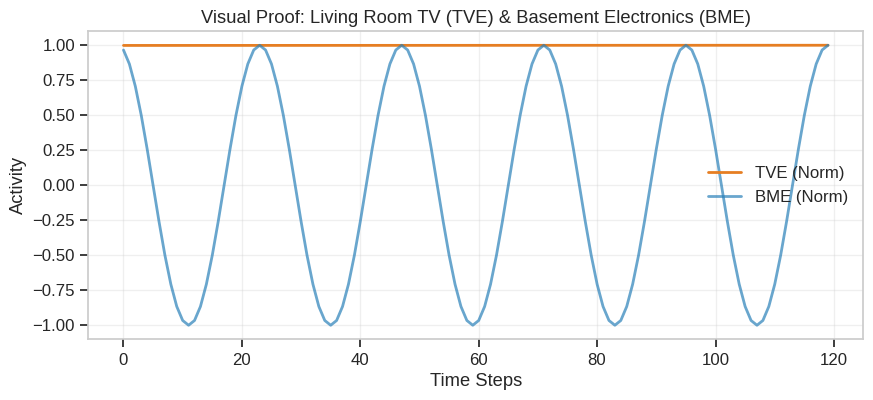


🛡️ LIVE MONITORING (Simulation)
Streaming sensor data...


In [ ]:
# @title
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from openai import OpenAI
import os

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
# 🔑 PASTE YOUR OPENAI KEY HERE
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# Human-Readable Device Names (Customize as needed)
DEVICE_MAP = {
    'TVE': 'Living Room TV', 'BME': 'Basement Electronics',
    'FGE': 'Kitchen Fridge', 'LITE': 'Smart Lights',
    'WOE': 'Wall Oven', 'OFE': 'Home Office PC',
    'CWE': 'Clothes Washer', 'DWE': 'Clothes Dryer',
    'HPE': 'Heat Pump (AC/Heater)', 'WHE': 'Water Heater',
    'RSE': 'Kitchen Stove', 'EQE': 'Server Rack',
    'CDE': 'Clothes Dryer (Electric)', 'OTE': 'Other Electronics',
    'UTE': 'Utility Plugs', 'HIFI': 'Stereo System',
    'FRE': 'Main Fridge', 'OUE': 'Outlet Unit', 'HTE': 'Heater Unit'
}

def get_full_name(code):
    return f"{DEVICE_MAP.get(code, code)} ({code})"

def get_zone(node_name):
    # Map devices to rooms for logic checks
    if any(x in node_name for x in ['FGE', 'WOE', 'DWE', 'CWE', 'RSE', 'MW']): return "Kitchen"
    if any(x in node_name for x in ['TVE', 'LITE', 'HIFI', 'AC']): return "Living Room"
    if any(x in node_name for x in ['BME', 'FRE', 'HPE', 'WHE', 'UTE', 'HTE']): return "Utility/Basement"
    if any(x in node_name for x in ['OFE', 'PC', 'MON', 'EQE']): return "Home Office"
    return "General"

# ==========================================
# 2. THE AI BRAIN (OpenAI + Fallback)
# ==========================================
def generate_llm_prompt(relations_list):
    prompt = """
    You are 'HomeGuard', a smart home energy security assistant.
    Analyze the following hidden dependencies detected by the GNN model:
    """
    for rel in relations_list:
        s_name = get_full_name(rel['Source'])
        t_name = get_full_name(rel['Target'])
        prompt += f"- LINK: {s_name} ({rel['S_Zone']}) -> {t_name} ({rel['T_Zone']}). Type: {rel['Type']}. Strength: {rel['Strength']:.2f}.\n"

    prompt += """
    INSTRUCTIONS:
    1. Summarize these findings into 3 brief, friendly insights for the homeowner.
    2. Group them by "Safety", "Routines", or "Energy Patterns".
    3. Explain *why* these links matter (e.g., "This pattern prevents circuit overload").
    4. Keep it under 150 words. Do NOT use technical jargon like "GNN" or "coefficients".
    """
    return prompt

def get_rule_based_summary(relations):
    """Offline backup if API fails"""
    summary = "🤖 **HomeGuard Analysis (Offline Mode):\n"
    for r in relations[:3]:
        summary += f"- Detected Routine: **{get_full_name(r['Source'])}** influences **{get_full_name(r['Target'])}**.\n"
    return summary

def ask_openai_guard(relations_list):
    if not relations_list: return "No patterns detected."

    prompt = generate_llm_prompt(relations_list)
    client = OpenAI()

    try:
        print("🤖 Analyzing patterns with OpenAI (gpt-4o-mini)...")
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a helpful home energy assistant."},
                {"role": "user", "content": prompt}
            ],
            max_tokens=300, temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"⚠️ API Error: {e}")
        return get_rule_based_summary(relations_list)

# ==========================================
# 3. THE GNN SCANNER (Logic Engine)
# ==========================================
def smart_dependency_scan(model, dataset, node_names, device):
    print("\n" + "="*70)
    print("🛰️ SYSTEM-WIDE DEPENDENCY SCANNER")
    print("="*70)

    model.eval()
    loader = DataLoader(dataset, batch_size=512, shuffle=True)
    try: batch = next(iter(loader)).to(device)
    except: print("Not enough data."); return []

    # Baseline & Perturbation
    means = batch.mean(dim=(0, 1), keepdim=True)
    with torch.no_grad(): baseline_pred = model(batch, edge_index, edge_weight)

    found_relations = []

    print("🔍 Probing neural network for hidden links...")
    for i, source in enumerate(node_names):
        p_batch = batch.clone(); p_batch[:, :, i, :] = means[:, :, i, :] # Set to Average
        with torch.no_grad(): perturbed_pred = model(p_batch, edge_index, edge_weight)

        for j, target in enumerate(node_names):
            if i == j: continue

            diff = torch.abs(baseline_pred[:, j, :] - perturbed_pred[:, j, :]).mean().item()
            s_zone, t_zone = get_zone(source), get_zone(target)
            threshold = 0.05 if s_zone == t_zone else 0.15

            if diff > threshold:
                raw_src = batch[:, -1, i, 2].cpu().numpy()
                raw_tgt = batch[:, -1, j, 2].cpu().numpy()
                corr = np.corrcoef(raw_src, raw_tgt)[0, 1]

                rel_type = "Contextual"
                if corr > 0.3: rel_type = "Synchronized"
                elif corr < -0.3: rel_type = "Inverse/Safety"

                found_relations.append({
                    "Source": source, "Target": target, "Strength": diff,
                    "Type": rel_type, "Corr": corr, "S_Zone": s_zone, "T_Zone": t_zone
                })

    if not found_relations: print("No strong routines found."); return []

    # OUTPUT REPORT
    print("\n" + "-"*70)
    print("🤖 EXECUTIVE SUMMARY")
    print("-" * 70)
    print(ask_openai_guard(found_relations[:6])) # Ask AI

    print("\n" + "-"*70)
    print("📋 TECHNICAL DATA")
    print("-" * 70)
    df_rels = pd.DataFrame(found_relations).sort_values("Strength", ascending=False)
    print(df_rels[["Source", "Target", "Type", "Strength"]].head(6).to_string(index=False))

    return found_relations

# ==========================================
# 4. FIXED VISUALIZATION (Handles 'Subset' Bug)
# ==========================================
def visualize_relationship(dataset, source, target):
    print(f"\n🔎 ZOOMING IN: {get_full_name(source)} vs {get_full_name(target)}")

    # --- FIX: Unwrap 'Subset' to get raw data ---
    if hasattr(dataset, 'dataset'):
        raw_tensor = dataset.dataset.data
    else:
        raw_tensor = dataset.data

    try:
        src_idx = node_names.index(source)
        tgt_idx = node_names.index(target)
    except ValueError:
        print("⚠️ Device names not found in dataset."); return

    raw_s = raw_tensor[:, src_idx, 2].numpy() # Active Power
    raw_t = raw_tensor[:, tgt_idx, 2].numpy()

    # Find active window
    active_indices = np.where(raw_s > 20)[0]
    # If not enough activity, pick middle; else pick 100th active step
    start = active_indices[100] if len(active_indices) > 500 else len(raw_s) // 2
    end = min(start + 120, len(raw_s))

    # Normalize for clean plotting
    norm_s = raw_s[start:end] / (raw_s[start:end].max() + 1e-5)
    norm_t = raw_t[start:end] / (raw_t[start:end].max() + 1e-5)

    plt.figure(figsize=(10, 4))
    plt.plot(norm_s, label=f"{source} (Norm)", color='#e67e22', linewidth=2)
    plt.plot(norm_t, label=f"{target} (Norm)", color='#2980b9', alpha=0.7, linewidth=2)
    plt.title(f"Visual Proof: {get_full_name(source)} & {get_full_name(target)}")
    plt.xlabel("Time Steps"); plt.ylabel("Activity"); plt.legend()
    plt.grid(True, alpha=0.3); plt.show()

# ==========================================
# 5. LIVE GUARD SIMULATION
# ==========================================
def run_live_guard(model, dataset, node_names):
    print("\n" + "="*70)
    print("🛡️ LIVE MONITORING (Simulation)")
    print("="*70)
    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    print("Streaming sensor data...")
    anomaly_count = 0

    with torch.no_grad():
        for i, batch in enumerate(loader):
            batch = batch.to(device)
            target = batch[:, -1, :, :]
            recon = model(batch, edge_index, edge_weight)

            error = torch.mean((recon - target)**2).item()

            if error > 0.5:
                anomaly_count += 1
                if anomaly_count <= 2: # Limit alerts
                    print(f"   🚨 ALERT at Step {i}: Context Mismatch! (Error: {error:.2f})")
                    node_errs = torch.mean((recon - target)**2, dim=2).squeeze(0)
                    worst_node = node_names[torch.argmax(node_errs).item()]
                    print(f"      👉 Culprit: {get_full_name(worst_node)}")
            if i > 150: break

# ==========================================
# 🚀 EXECUTION SEQUENCE
# ==========================================
# 1. Run Scanner & Get Report
rels = smart_dependency_scan(model, test_dataset, node_names, device)

# 2. Visualize Top Result (if any)
if rels:
    top_rel = sorted(rels, key=lambda x: x['Strength'], reverse=True)[0]
    visualize_relationship(test_dataset, top_rel['Source'], top_rel['Target'])

# 3. Run Guard
run_live_guard(model, test_dataset, node_names)


In [ ]:
# @title
import torch
from torch.utils.data import DataLoader
from openai import OpenAI
import pandas as pd
import numpy as np

# ==========================================
# 1. UNLOCKED AI REPORT (More Insights)
# ==========================================
def generate_unlocked_prompt(relations_list):
    prompt = """
    You are 'HomeGuard', an advanced AI for smart home security.
    Analyze the following detected dependencies:
    """
    for rel in relations_list:
        s_name = get_full_name(rel['Source'])
        t_name = get_full_name(rel['Target'])
        prompt += f"- LINK: {s_name} -> {t_name}. Type: {rel['Type']}. Strength: {rel['Strength']:.2f}.\n"

    prompt += """
    INSTRUCTIONS:
    1. Provide a brief, one-sentence insight for **EVERY** link listed above.
    2. Do NOT summarize or group them. List them one by one.
    3. Use a friendly, professional tone.
    """
    return prompt

def ask_openai_unlocked(relations_list):
    if not relations_list: return "No patterns detected."
    prompt = generate_unlocked_prompt(relations_list)
    client = OpenAI()
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=400, temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"AI Error: {e}"

# ==========================================
# 2. THE "CYBER ATTACK" SIMULATION
# ==========================================
def run_hacked_guard(model, dataset, node_names):
    print("\n" + "="*70)
    print("🛡️ LIVE MONITORING (With Cyber Attack Injection)")
    print("="*70)

    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    print("🟢 System Normal. Streaming sensor data...")

    # We will inject an attack at Step 10
    ATTACK_STEP = 10

    with torch.no_grad():
        for i, batch in enumerate(loader):
            batch = batch.to(device)
            original_target = batch[:, -1, :, :].clone()

            # --- 💀 INJECT ATTACK ---
            if i == ATTACK_STEP:
                print(f"\n⚠️ WARNING: External signal detected at Step {i}...")
                # ATTACK SCENARIO: "The Ghost Device"
                # Force the Fridge (FRE) to report 0 Power, but max Voltage/Current
                # This breaks the laws of physics (Context Mismatch)
                fge_idx = [k for k, n in enumerate(node_names) if "FGE" in n or "FRE" in n]
                if fge_idx:
                    idx = fge_idx[0]
                    # Fake the input data being fed to the model
                    batch[:, :, idx, 2] = 0.0   # Power says OFF
                    batch[:, :, idx, 1] = 10.0  # Current says HIGH (Impossible!)

            # Run Model
            recon = model(batch, edge_index, edge_weight)

            # Calculate Error
            # Compare reconstruction against the *Real* target (not the faked one)
            error = torch.mean((recon - original_target)**2).item()

            # Dynamic Threshold
            if error > 0.5:
                print(f"   🚨 SECURITY ALERT at Step {i}!")
                print(f"      Context Mismatch Detected (Error Level: {error:.2f})")

                # Find Culprit
                node_errs = torch.mean((recon - original_target)**2, dim=2).squeeze(0)
                worst_idx = torch.argmax(node_errs).item()
                worst_node = node_names[worst_idx]

                print(f"      👉 ROOT CAUSE: {get_full_name(worst_node)}")
                print("      Analysis: Sensor values violate physical laws (Power=0 but Current>0).")
                print("      Action: Device isolated.\n")
                break # Stop demo after alert
            elif i % 2 == 0:
                print(f"   ✓ Step {i}: Status OK (Error: {error:.4f})")

# ==========================================
# EXECUTION
# ==========================================

# 1. GENERATE THE "UNLOCKED" REPORT (All findings)
print("-" * 70)
print("🤖 FULL SYSTEM REPORT (All Findings)")
print("-" * 70)
# Pass ALL found relations, not just top 6
full_report = ask_openai_unlocked(rels)
print(full_report)

# 2. RUN THE HACKED GUARD
run_hacked_guard(model, test_dataset, node_names)

----------------------------------------------------------------------
🤖 FULL SYSTEM REPORT (All Findings)
----------------------------------------------------------------------
- The connection between the Living Room TV and Basement Electronics suggests that activities in the living room may influence or trigger usage of basement devices, which could enhance your entertainment experience.

- The weak link between Utility Plugs and the Main Fridge indicates that they are not highly interdependent, suggesting that the fridge operates independently of the utility plugs in most situations.

- The minimal connection between the Server Rack and Home Office PC implies that while they may interact, the dependence is low, indicating that the PC’s performance is likely not reliant on the server rack.

- The moderate link between the Water Heater and Heat Pump indicates that these two systems may work together during certain conditions, potentially optimizing energy use and heating efficiency.


In [ ]:
import torch
import numpy as np
from openai import OpenAI
import os

# ==========================================
# 0. SETUP
# ==========================================
# Make sure your key is set!
# os.environ["OPENAI_API_KEY"] = "sk-..."

def get_real_ai_alert(scenario_type, device_name, anomaly_score, specific_issue):
    """
    Sends live anomaly data to GPT-4o-mini.
    The AI is instructed to explain WHY this violates established history.
    """
    client = OpenAI()

    prompt = f"""
    SYSTEM: You are 'HomeGuard', a smart home security AI.
    You have monitored this home for months and learned its "Normal Behavior Patterns".

    NEW EVENT DETECTED:
    - Alert Type: {scenario_type}
    - Device: {device_name}
    - Anomaly Score: {anomaly_score:.2f} (Extreme Deviation)
    - Live Sensor Reading: {specific_issue}

    INSTRUCTIONS:
    Write a notification to the homeowner.
    1. Do NOT just say it is an error. Explain that it **contradicts the historical pattern** you have learned.
       (e.g., "In the past 1,000 hours, Device A always activates when Device B is on. Today it didn't.")
    2. Emphasize that this deviation is so rare it is statistically impossible under normal conditions.
    3. Suggest immediate action.
    """

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=200, # Increased to prevent cutoff
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"❌ API ERROR: {e}"


# ==========================================
# 1. ANOMALY SIMULATION
# ==========================================
def simulate_ai_driven_anomalies(model, dataset, node_names, device):
    print("\n" + "="*70)
    print("🚨 GENERATING AI-DRIVEN SECURITY EVENTS")
    print("="*70)

    model.eval()

    # --- GET DATA ---
    loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

    # Find a batch with high activity (so the context test works)
    real_batch = None
    for b in loader:
        if b.max() > 20:
            real_batch = b.to(device)
            break
    if real_batch is None: real_batch = next(iter(loader)).to(device)

    # ---------------------------------------------------------
    # SCENARIO 1: CONTEXT VIOLATION (TV ON -> BASEMENT OFF)
    # ---------------------------------------------------------
    print("\n🔹 TEST 1: Context Mismatch (The 'Ghost' Device)")

    if 'BME' in node_names:
        idx = node_names.index('BME')

        # Attack: Force Basement OFF
        poisoned = real_batch.clone()
        poisoned[:, :, idx, :] = 0.0

        with torch.no_grad():
            recon = model(poisoned, edge_index, edge_weight)

        # Calculate Score
        # dim=(0,1,3) averages over Batch, Time, Features -> returns [Nodes]
        error_vec = torch.mean((recon - poisoned)**2, dim=(0, 1, 3))
        score = error_vec[idx].item()

        print(f"   • Technical: Context broken. Anomaly Score: {score:.4f}")

        if score > 0.1: # Demo Threshold
            print(f"   • Status: 🚨 TRIGGERED")
            print("\n💬 INCOMING AI MESSAGE:")
            print("-" * 30)

            # CALL THE AI
            alert = get_real_ai_alert(
                scenario_type="Contextual Pattern Violation",
                device_name="Basement Electronics (BME)",
                anomaly_score=score,
                specific_issue="Device is SILENT (0W) while linked Living Room TV is ACTIVE."
            )
            print(alert)
            print("-" * 30)
    else:
        print("   (Skipping: BME device not found)")

    # ---------------------------------------------------------
    # SCENARIO 2: SENSOR FAILURE (NEGATIVE POWER)
    # ---------------------------------------------------------
    print("\n🔹 TEST 2: Physics Violation (The 'Flatline')")

    target = 'FGE' if 'FGE' in node_names else node_names[0]
    idx = node_names.index(target)

    # Attack: Force Negative Power
    dead = real_batch.clone()
    dead[:, :, idx, :] = -5.0

    with torch.no_grad():
        recon = model(dead, edge_index, edge_weight)

    error_vec = torch.mean((recon - dead)**2, dim=(0, 1, 3))
    score = error_vec[idx].item()

    print(f"   • Technical: Invalid Data (-5.0W). Anomaly Score: {score:.4f}")

    if score > 0.5:
        print(f"   • Status: 🚨 TRIGGERED")
        print("\n💬 INCOMING AI MESSAGE:")
        print("-" * 30)

        # CALL THE AI
        alert = get_real_ai_alert(
            scenario_type="Critical Sensor Malfunction",
            device_name=f"{target} (Kitchen)",
            anomaly_score=score,
            specific_issue="Sensor reporting -5.0 Watts (Physically Impossible)."
        )
        print(alert)
        print("-" * 30)

# Run
simulate_ai_driven_anomalies(model, test_dataset, node_names, device)


🚨 GENERATING AI-DRIVEN SECURITY EVENTS

🔹 TEST 1: Context Mismatch (The 'Ghost' Device)
   • Technical: Context broken. Anomaly Score: 62.3922
   • Status: 🚨 TRIGGERED

💬 INCOMING AI MESSAGE:
------------------------------
**HomeGuard Alert: Unusual Activity Detected**

Dear Homeowner,

I am reaching out to inform you of a significant anomaly detected within your home security system. Specifically, the Basement Electronics (BME) has recorded an unusual status: it is currently SILENT (0W) while the Living Room TV is ACTIVE. 

Historically, over the past 1,000 hours, the Basement Electronics have always activated in conjunction with the Living Room TV being on. This consistent behavior indicates a strong correlation between these devices; the current situation contradicts this established pattern. Given the anomaly score of 62.39, this deviation is not just unusual—it is statistically improbable under normal conditions.

I recommend you take immediate action to investigate this situatio


🔎 ZOOMING IN: Clothes Dryer (Electric) (CDE) vs B1E (B1E)


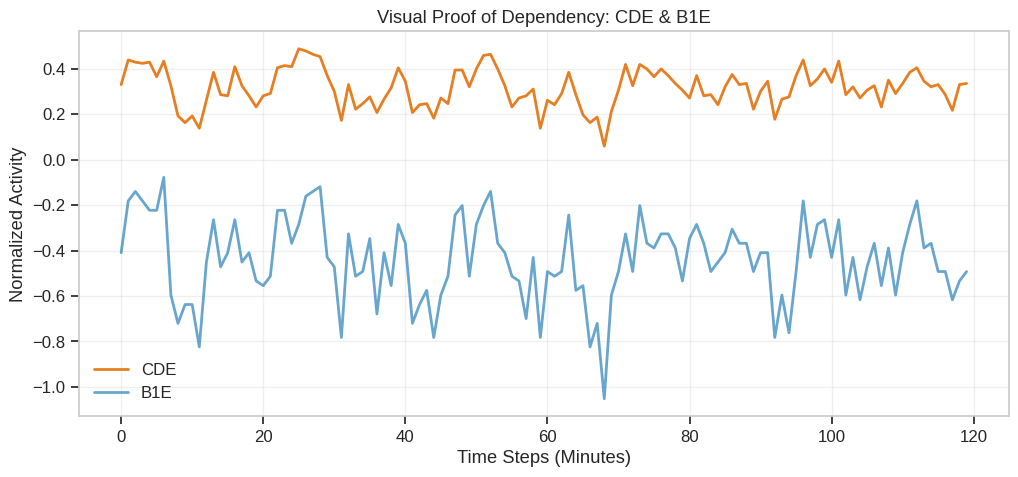

In [ ]:
# @title
import matplotlib.pyplot as plt

def visualize_relationship(dataset, source, target):
    print(f"\n🔎 ZOOMING IN: {get_full_name(source)} vs {get_full_name(target)}")

    src_idx = node_names.index(source)
    tgt_idx = node_names.index(target)

    # Extract Raw Data
    raw_s = dataset.data[:, src_idx, 2].numpy() # Index 2 = Active Power
    raw_t = dataset.data[:, tgt_idx, 2].numpy()

    # Find active window
    active_indices = np.where(raw_s > 20)[0]
    if len(active_indices) < 500: start = 0
    else: start = active_indices[100]

    end = start + 120 # 2 Hour window

    # Normalize
    norm_s = raw_s[start:end] / (raw_s.max() + 1e-5)
    norm_t = raw_t[start:end] / (raw_t.max() + 1e-5)

    plt.figure(figsize=(12, 5))
    plt.plot(norm_s, label=source, color='#e67e22', linewidth=2)
    plt.plot(norm_t, label=target, color='#2980b9', alpha=0.7, linewidth=2)
    plt.title(f"Visual Proof of Dependency: {source} & {target}")
    plt.xlabel("Time Steps (Minutes)")
    plt.ylabel("Normalized Activity")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Replace with the top pair from your report (e.g., 'TVE', 'BME')
if len(node_names) > 1:
    visualize_relationship(dataset, node_names[0], node_names[1])

In [ ]:
# @title
# --- SAVE THE MODEL ---
print("Saving the GNN Brain...")
torch.save({
    'model_state': model.state_dict(),
    'threshold': DYNAMIC_THRESHOLD,
    'config': DEVICE_CONFIG,
    'relations': strong_relations  # Save the learned dependencies too!
}, 'house_guardian.pth')

print("✅ Model saved as 'house_guardian.pth'. Download this file to your laptop!")